# 016. SFT(指示チューニング) / Supervised Fine-Tuning (Instruction Tuning)

## 1. 概要 / Overview

SFT(Supervised Fine-Tuning、教師あり微調整)による指示チューニング(Instruction Tuning)は、
「指示 → 応答」の組からなる指示データで事前学習済みの言語モデルを微調整し、指示に従って応答を
書き分けるようにする手法である。本トピックでは、008 の小型 GPT に Query・Value 射影への LoRA
(Low-Rank Adaptation、[012](../03_efficient_training/012_low_rank_adaptation.ipynb))を適用し、
入力と課題から応答が決定的に決まる **合成の指示データ** で SFT を行う。そのうえで、
(A)微調整後のモデルが指示を読んで出力を切り替えているか、(B)指示部分に損失をかけない
損失マスク(Loss Masking)の効果が指示の長さによってどう変わるか、(C)応答の形式と課題そのものの
どちらが少ないデータで習得されるかを検証する。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、
「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。本番の学習を始める前に(6.4 節)、スケーリングの計測
(6.3 節)から 1 セッション全体の実行時間を **削る段階**(6.1 節)ごとに見積もり、予算に収まる最小の段階を自動で選ぶ。
選択は見積もりのみに基づき、どの実験の結果も参照しない。段階 3 でも予算を超える場合は、学習の前に例外で停止する
(その場合は計画を見直す)。選ばれた段階は 6.4 節と判定の一覧(6.12 節)に印字される。

## 2. 参考論文 / References

1. Wei, J., Bosma, M., Zhao, V. Y., Guu, K., Yu, A. W., Lester, B., Du, N., Dai, A. M., Le, Q. V.,
   "Finetuned Language Models Are Zero-Shot Learners", ICLR 2022. https://arxiv.org/abs/2109.01652
   (FLAN(Finetuned Language Net)。既存の自然言語処理のデータセットを指示のテンプレートで包んで微調整し、未見の課題への汎化を示した)
2. Ouyang, L., Wu, J., Jiang, X., Almeida, D., Wainwright, C. L., Mishkin, P., Zhang, C., Agarwal, S.,
   Slama, K., Ray, A., et al., "Training language models to follow instructions with human feedback",
   NeurIPS 2022. https://arxiv.org/abs/2203.02155
   (InstructGPT。人手で書いた応答による SFT を、報酬モデルと RLHF の前段に置いた。RLHF は 017 で扱う)
3. Taori, R., Gulrajani, I., Zhang, T., Dubois, Y., Li, X., Guestrin, C., Liang, P., Hashimoto, T. B.,
   "Stanford Alpaca: An Instruction-following LLaMA model", GitHub repository, 2023.
   https://github.com/tatsu-lab/stanford_alpaca
   (Alpaca。言語モデルに生成させた 52K 件の指示データ。データのライセンスは CC BY-NC 4.0)
4. Zhou, C., Liu, P., Xu, P., Iyer, S., Sun, J., Mao, Y., Ma, X., Efrat, A., Yu, P., Yu, L., Zhang, S.,
   Ghosh, G., Lewis, M., Zettlemoyer, L., Levy, O., "LIMA: Less Is More for Alignment", NeurIPS 2023.
   https://arxiv.org/abs/2305.11206(表層的アライメント仮説。1,000 件の厳選した事例のみでの SFT)
5. Shi, Z., Yang, A. X., Wu, B., Aitchison, L., Yilmaz, E., Lipani, A.,
   "Instruction Tuning With Loss Over Instructions", NeurIPS 2024. https://arxiv.org/abs/2405.14394
   (指示部分にも損失をかける Instruction Modelling。指示が応答に比べて長い場合・事例が少ない場合に
   有利になると報告した。実験 B の仮説の出典)
6. Huerta-Enochian, M., Ko, S. Y., "Instruction Fine-Tuning: Does Prompt Loss Matter?", EMNLP 2024.
   https://arxiv.org/abs/2401.13586(https://aclanthology.org/2024.emnlp-main.1267/)
   (指示部分の損失の重み(prompt loss weight)の効果が、応答が短いデータで大きいことを報告した)
7. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., Chen, W.,
   "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022. https://arxiv.org/abs/2106.09685
8. Krell, M. M., Kosec, M., Perez, S. P., Fitzgibbon, A., "Efficient Sequence Packing without
   Cross-contamination: Accelerating Large Language Models without Impacting Performance", arXiv 2021.
   https://arxiv.org/abs/2107.02027(packing と事例間の注意の漏れ。3.6 節)
9. Press, O., Wolf, L., "Using the Output Embedding to Improve Language Models", EACL 2017.
   https://arxiv.org/abs/1608.05859(重み共有(weight tying)。3.5 節)
10. Conover, M., Hayes, M., Mathur, A., Xie, J., Wan, J., Shah, S., Ghodsi, A., Wendell, P., Zaharia, M.,
    Xin, R., "Free Dolly: Introducing the World's First Truly Open Instruction-Tuned LLM",
    Databricks blog, 2023(databricks-dolly-15k。人手で書いた 15K 件の指示データ、CC BY-SA 3.0。3.1 節)

## 3. 理論 / Theory

### 3.1 事前学習と指示チューニングの目的の違い、指示データの系譜

事前学習の目的は、コーパスの次のトークンの負の対数尤度(negative log-likelihood)を系列のすべての位置で
最小化することである。モデルは「文書の続きとしてもっともらしいもの」を書くようになるが、指示に
答えるようにはならない(008 のモデルに指示を与えても、Wikipedia の記事の続きのような文を書く。5.5 節)。
指示チューニングは、同じ次トークン予測の損失を「指示 → 応答」の組に限って適用し、**指示に条件づけた
応答の分布** を学習させる。

指示データの系譜は次のとおりである。

- **FLAN**(Wei et al., ICLR 2022 [1]): 既存の自然言語処理のデータセット(翻訳・要約・分類など)を、課題ごとに
  複数用意した自然言語の指示のテンプレートで包んで微調整した。学習に使わなかった課題の群への
  ゼロショットの汎化が、テンプレートの多様さと課題の数とともに向上することを示した。
- **InstructGPT**(Ouyang et al., NeurIPS 2022 [2]): 人手で書いた応答による SFT を、報酬モデルの学習と
  RLHF(Reinforcement Learning from Human Feedback)の前段に置いた。
- **Alpaca**(Taori et al., 2023 [3]): 言語モデル自身に指示と応答を生成させた 52K 件のデータで SFT を行い、
  安価に指示追従モデルを作れることを示した。
- **LIMA**(Zhou et al., NeurIPS 2023 [4]): 厳選した 1,000 件だけで SFT を行い、大規模なデータを使った
  モデルに匹敵する応答が得られるとして、表層的アライメント仮説(3.7 節)を提唱した。

**本トピックで Dolly-15k・Alpaca の実データを使わない理由**:

- 008 のモデル(4 層・$d_{\mathrm{model}} = 256$、約 525 万パラメータ)に対して、これらのデータの応答は
  長い自然文である。モデルの規模では意味のある応答を書けず、また正解が一意に定まらないので、
  **完全一致による自動採点ができない**。本トピックの実験は、生成した応答を正解と照合する採点に基づく。
- Alpaca のデータのライセンスは CC BY-NC 4.0(非商用)であり、再配布・派生物の扱いに制約がある。

そこで、入力と課題から応答が決定的に決まる合成の指示データ(5.4 節)を使う。これにより、生成した応答を
正解と完全一致で照合でき、指示を読まずに達成できる完全一致率の上界 $c^*$(6.1 節)も厳密に計算できる。

### 3.2 チャットテンプレートと区切り記号

SFT では、指示と応答を 1 つの系列に並べ、どこが指示でどこが応答かをモデルに示す書式(チャットテンプレート)
を決める。推論時にも同じ書式で指示を与え、応答の開始位置からモデルに生成させる。応答の終わりを示す
終端記号を学習させておけば、生成をそこで止められる。本トピックのテンプレートは次のとおりである。

```text
### Instruction:
{前置き(長い水準のみ)} {指示文}
Words: w1 w2 w3
### Response: v1 v2 v3
### End
```

区切り記号(`### Instruction:`・`### Response:`・終端記号`### End`)はいずれも 008 のトークナイザの既存の
語彙で表せる文字列であり、トークナイザは変更しない(特殊トークンを追加しない理由は 3.5 節)。
`### Response:`までを **指示部分**、その直後の空白から終端記号までを **応答部分** とする。

```mermaid
flowchart LR
    subgraph prompt["指示部分(P)"]
        H1["### Instruction:"] --> I["前置き(長い水準のみ) + 指示文"]
        I --> W["Words: w1 w2 w3"]
        W --> H2["### Response:"]
    end
    subgraph response["応答部分(R)"]
        A["v1 v2 v3"] --> E["### End(終端記号)"]
    end
    H2 --> A
```

**符号化の境界**: 指示部分と応答部分は **別々に符号化してから連結する**。こうすると、損失マスクの境界が
必ずトークンの境界と一致する。全文を一度に符号化すると、境界をまたぐ部分語のマージが起きたときに、
境界のトークンがどちらに属するか決められなくなる(本トピックのテンプレートでは、応答部分が空白で始まり
事前分割(pre-tokenization)の境界と一致するため、全文を一度に符号化した結果とも一致する。5.4 節で確認する)。

### 3.3 損失マスクの定式化と損失の正規化の単位

1 つのミニバッチについて、次の記号を使う。

- $R$: バッチ内の応答部分のトークン(終端記号を含む)の集合。
- $P$: バッチ内の指示部分のトークンのうち、予測対象になるものの集合(各系列の先頭のトークンは左の文脈を
  持たないので含めない)。
- $\ell_t = -\log p_\theta(y_t \mid y_{<t})$: トークン $t$ の負の対数尤度(nats)。$p_\theta$ はパラメータ
  $\theta$ のモデルが与える次トークンの分布、$y_t$ は位置 $t$ のトークン、$y_{<t}$ はそれより前の系列である。

**損失マスクあり**(指示部分に損失をかけない)の損失を

$$
\mathcal{L}_{\mathrm{mask}} = \frac{1}{|R|} \sum_{t \in R} \ell_t
$$

とし、**損失マスクなし**(指示部分にも損失をかける)の損失を、本トピックでは次のように定義する。

$$
\mathcal{L}_{\mathrm{unmask}} = \frac{1}{|R|} \left( \sum_{t \in R} \ell_t + \sum_{t \in P} \ell_t \right)
$$

どちらも **応答部分のトークン数 $|R|$ で割る** 点が要である。勾配をとると

$$
\nabla_\theta \mathcal{L}_{\mathrm{unmask}}
= \nabla_\theta \mathcal{L}_{\mathrm{mask}} + \frac{1}{|R|} \sum_{t \in P} \nabla_\theta \ell_t
$$

となり、応答部分のトークンが勾配に寄与する係数 $1/|R|$ は両者で同一である。2 つの条件の違いは、
指示部分の項 $\frac{1}{|R|} \sum_{t \in P} \nabla_\theta \ell_t$ を足すかどうかだけになる。

これに対して、一般的な実装(系列の全トークンの平均をとる実装)の損失は

$$
\mathcal{L}_{\mathrm{all}} = \frac{1}{|R| + |P|} \left( \sum_{t \in R} \ell_t + \sum_{t \in P} \ell_t \right),
\qquad
\nabla_\theta \mathcal{L}_{\mathrm{all}}
= \frac{|R|}{|R| + |P|} \nabla_\theta \mathcal{L}_{\mathrm{mask}}
+ \frac{1}{|R| + |P|} \sum_{t \in P} \nabla_\theta \ell_t
$$

であり、応答部分の勾配が係数 $\frac{|R|}{|R| + |P|}$ で薄まる。この係数は指示が長い($|P|$ が大きい)ほど
小さい。本トピックのデータでは 1 事例あたり $|R|$ が約 12、$|P|$ が短い水準で約 33・長い水準で約 133 なので、
係数は短い水準で約 $0.27$、長い水準で約 $0.08$ になる。$\mathcal{L}_{\mathrm{all}}$ で「損失マスクなし」の
条件を作ると、指示の長さを変えたときに **指示に損失をかけることの効果** と **応答の実効的な学習率が
下がることの効果** が混ざる。本トピックの定義はこの交絡を取り除き、実験 B の対比量が前者だけを反映する
ようにするためのものである。なお、損失マスクありの $\mathcal{L}_{\mathrm{mask}}$ は、応答部分のトークンの
平均をとる一般的な実装(予測対象から指示部分を除いて平均する実装)と一致する。

Shi et al.(NeurIPS 2024 [5])は、指示部分にも損失をかけることが、指示が応答に比べて長いデータや事例の
少ない設定で有利になると報告した。Huerta-Enochian & Ko(EMNLP 2024 [6])は、指示部分の損失の重みの効果が
応答の短いデータで大きいことを報告した。実験 B はこのうち「指示が長いほど、損失マスクの優位が縮む」
という向きを、上の正規化の単位のもとで検証する。

```mermaid
flowchart LR
    subgraph seq["1 事例のトークン列"]
        T0["先頭のトークン<br/>(予測対象外)"] --> TP["指示部分の残り(P)<br/>mask: 損失なし / unmask: 損失あり"]
        TP --> TR["応答部分 + 終端記号(R)<br/>両条件とも損失あり"]
        TR --> PAD["右パディング<br/>(損失なし)"]
    end
    TR -.->|"正規化の分母"| N["|R|(両条件で共通)"]
```

**パディング**: 長さの異なる事例をバッチにするとき、系列の右側だけにパディングを置く。因果マスクにより、
実トークンの位置はそれより右のパディングを参照しないので、パディングは実トークンの logits を変えない。
パディングの位置は $R$ にも $P$ にも含めない。

### 3.4 アルゴリズム

```text
procedure SFT(model, examples, T, b, include_prompt_loss):
    apply LoRA to W_q, W_v (rank r = 8); freeze all other parameters     # 012
    batches <- epoch-wise random permutations of examples, cut into T batches of size b
    for step = 1 .. T:
        tokens, P_mask, R_mask <- right-pad the examples of batches[step]
        losses <- per-token negative log-likelihood of tokens[:, 1:] given tokens[:, :-1]
        numerator <- sum(losses * R_mask)
        if include_prompt_loss: numerator <- numerator + sum(losses * P_mask)
        loss <- numerator / sum(R_mask)                                   # 3.3 節の正規化の単位
        backward; AdamW step (warmup + cosine, no gradient clipping)

procedure GENERATE(model, prompt):                                        # 採点用
    greedy decoding from the prompt with a KV cache
    stop when the decoded text contains "### End" or after 32 new tokens
```

### 3.5 特殊トークンの追加と、LoRA・重み共有との衝突(実装しない)

実務のチャットテンプレートは、`<|im_start|>`のような **特殊トークン** を語彙に追加して区切りに使うことが多い。
区切りが通常の文字列と衝突せず、1 トークンで表せるからである。しかし本トピックの設定では、次の 2 つの理由で
特殊トークンの追加が衝突を起こす。

1. **LoRA による凍結**: 新しいトークンの埋め込みベクトルは学習されていない(乱数または平均などで初期化される)。
   Query・Value 射影にだけ LoRA を掛ける設定では埋め込み行列は凍結されているので、新しいトークンの埋め込みは
   初期値のまま一度も更新されない。埋め込みも学習対象に加えると、LoRA で学習可能パラメータを絞った意味が
   薄れる(語彙 $V = 8192$、$d_{\mathrm{model}} = 256$ の埋め込みは約 210 万パラメータで、LoRA の 3.3 万を大きく
   上回る)。新しい行だけを学習する実装も可能だが、次の問題が残る。
2. **重み共有(weight tying)**: 008 のモデルは、トークン埋め込み行列と出力層の重みを共有している
   (Press & Wolf, EACL 2017 [9])。新しいトークンの行は、入力側の埋め込みであると同時に出力層で
   そのトークンの logit を計算するベクトルでもある。終端記号を新しいトークンにすると、その logit は
   学習されていないベクトルと隠れ状態の内積になり、「応答の終わりで終端記号を出す」ことを学ぶには、
   この行を入力側と出力側の両方の役割に同時に合わせて学習する必要がある。

本トピックでは、既存の語彙で表せる文字列(`### End`は 5 トークン)を区切りに使い、この問題を避ける。
代わりに、区切り記号は複数のトークンからなり、通常の文字列と区別できる保証はない(本トピックの入力の単語は
`#`を含まないので衝突しない)。

### 3.6 packing と事例間の注意の漏れ(理論のみ)

事例の長さがばらつくと、パディングで揃えたバッチには計算の無駄が生じる。**packing** は、複数の事例を
1 つの長い系列に詰めてパディングを減らす手法である。ただし、通常の因果マスクのまま詰めると、後ろの事例の
トークンが前の事例のトークンを注意で参照できてしまう(事例間の注意の漏れ、cross-contamination)。
Krell et al.(2021 [8])は、事例ごとのブロック対角な因果マスクと、事例ごとに 0 から数え直す位置の番号
(RoPE(Rotary Position Embedding)なら`positions`)を使えば、packing しても 1 事例ずつ処理した場合と同じ計算になることを示した。
本トピックの系列は短く(最長 150 トークン程度)、パディングによる無駄は小さいので、右パディング方式を使う。

### 3.7 表層的アライメント仮説と、本トピックの位置づけ

Zhou et al.(LIMA、NeurIPS 2023 [4])は、**表層的アライメント仮説(Superficial Alignment Hypothesis)** を
提唱した。モデルの知識と能力はほぼすべて事前学習で獲得されており、アライメント(SFT)が教えるのは
「利用者と対話するときにどの形式・文体を使うか」という表層の部分である、という仮説である。この仮説が正しければ、
SFT に必要なデータは少なくて済む(同論文は 1,000 件で十分な応答が得られるとした)。

**本トピックのモデルの事情(パイロットの観察、6.2 節)**: 008 のモデルは、事前学習でコピーの能力
(文脈に現れた単語の並びを後で再現する能力。Transformer では induction head と呼ばれる注意の回路が担うことが
多い)を獲得していない。無関係な単語の列を 2 回繰り返しても、2 回目の単語の負の対数尤度は 1 回目から
ほとんど下がらない(6.2 節・6.8 節)。本トピックの課題(単語の並べ替え)はコピーを必要とするので、
SFT は **形式** に加えて、**事前学習で獲得していない能力** も新たに教えることになる。

したがって、実験 C(形式と課題の習得の速さの比較)は LIMA の仮説の追試ではない。仮説は「能力は事前学習で
獲得済み」を前提とするが、本トピックではその前提が成り立たない。実験 C が比べるのは、形式の習得と、
事前学習にない能力を SFT で新たに学ぶことの習得の速さである(6.1 節)。

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/data/instruction.py`: 合成の指示データ。課題(`TASK_NAMES`・`apply_task()`)、単語の語彙
  (`WORD_VOCABULARY`、単一トークンの確認は`check_single_token_words()`)、指示文(学習用の`SEEN_INSTRUCTIONS`、
  未見の`UNSEEN_INSTRUCTIONS`)と長い水準の前置き(`PREAMBLES`)、テンプレートの適用(`format_prompt()`・
  `format_response()`)、入力の生成(`sample_word_sequences()`)、学習用・評価用の事例の作成
  (`build_training_examples()`・`build_evaluation_examples()`、評価用は入力と課題の直積)、区切りごとの
  符号化(`encode_instruction_example()`)、右パディングと損失マスクの作成(`collate_instruction_batch()`)、
  $c^*$ の計算(`compute_instruction_agnostic_upper_bound()`)、採点(`score_generated_response()`)。
- `src/training/instruction_tuning.py`: 3.3 節の正規化の単位による損失(`compute_instruction_tuning_loss()`)、
  エポックごとの並べ替えによるミニバッチの添字(`make_epoch_batches()`)、SFT の学習ループ
  (`train_instruction_tuning()`)、教師強制(teacher forcing)による事例ごとの負の対数尤度の評価
  (`evaluate_instruction_negative_log_likelihood()`)。既存の`train_language_model()`は連続したトークン列から
  ランダムな区間を切り出す事前学習用のループで、事例の境界も損失マスクも扱わないため、拡張せずに新規に置いた
  (既存の関数・既存のファイルの挙動は変わらない)。
- `src/generation/stopping.py`: 終端記号の文字列で停止する貪欲法の生成(`greedy_generate_until_stop()`)。
  `GPTLanguageModel.generate()`は指定したトークン数だけ生成し、途中で止まらないため、新規に置いた。
  指示部分の長さごとにバッチにする(パディングを使わない)ので、1 事例ずつ生成する場合と位置・因果マスクが
  同じになる。既存の`generate()`は変更していない(5.5 節で、停止しない場合の出力が`generate()`と一致することを
  確認する)。

既存のモジュール(`train_language_model()`・`generate()`など)は変更していないため、後方互換性の検証
(変更前のコミットとの数値比較)は要らない。LoRA は 012 の`apply_lora()`、optimizer は 007 の`AdamW`、
学習率スケジュールは 007 の warmup + cosine をそのまま使う。

**ノートブック内に直接書く(016 固有)**: 条件の定義と学習・評価の呼び出し、
実験 A〜C の判定、コピー能力の診断、スケーリングの計測。

**アップロード方針**: 本トピックで学習する LoRA のアダプタは、すべて条件間の比較のためのものであり、後続トピックの
入力にも、読者が単体で取得する対象にもならない。保存もアップロードもしない(アップロードのセルも置かない)。

**生成物の置き場所**: `.cache/`には何も置かない(合成データは乱数シードから決定的に生成でき、
全体でも数秒で作れるため)。判定の記録は、各判定セル(6.6・6.7・6.10・6.12 節)の出力(対比量・標準偏差・判定の閾値・前提条件の値と成否・判定結果)である。外部から取得するのは、
Hugging Face Hub のモデル(`kojikojiprg/ai-theories-small-gpt-en`の`main`)・トークナイザ
(`kojikojiprg/ai-theories-tokenizer-en`)と、前提条件 P0 のための英語版 Wikipedia のコーパス
(`kojikojiprg/ai-theories-corpus-en-pretraining`、取得できない場合のみ Wikipedia から直接取得)である。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。実行環境はこのセルで 1 回だけ印字する。
再現性のため(6.1 節)、CUDA の cuBLAS が決定的な演算を使うための環境変数`CUBLAS_WORKSPACE_CONFIG`を
torch の読み込み前に設定し、`torch.use_deterministic_algorithms(True)`を有効にする(決定的な実装を持たない演算を
使うと例外になるので、5.6 節で学習・評価・生成の経路を一通り実行して確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

NOTEBOOK_START_TIME = time.time()
# cuBLAS を決定的にする(torch が CUDA を初期化する前に設定する必要がある)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
execution_environment = print_execution_environment(device)

print(
    f"SMOKE_TEST={SMOKE_TEST}、決定的な実行: {torch.are_deterministic_algorithms_enabled()}、"
    f"CUBLAS_WORKSPACE_CONFIG={os.environ['CUBLAS_WORKSPACE_CONFIG']}"
)

Cloning into 'ai-theories'...
remote: Enumerating objects: 1181, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 1181 (delta 133), reused 146 (delta 75), pack-reused 960 (from 1)
Receiving objects: 100% (1181/1181), 12.85 MiB | 10.66 MiB/s, done.
Resolving deltas: 100% (694/694), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 46.9 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 52 packages in 342ms
Prepared 31 packages in 1m 00s
Uninstalled 17 packages in 968ms
Installed 31 packages in 419ms
 - click==8.5.0
 + click==8.4.2
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-pathfinder==1.8.0
 + cuda-pathfinder==1.6.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.5
 + filelock==3.32.2
 - fonttools==4.64.0
 + fonttools==4.63.0
 - fsspec==2025.12.0
 + fsspec==2026.7.0
 - huggingface-hub==1.29.0
 + huggingface-hub==1.28.0
 - kiwisolver=

In [2]:
import copy
import functools
import hashlib
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from torch import nn

from src.data.instruction import (
    END_MARKER,
    PREAMBLES,
    SEEN_INSTRUCTIONS,
    TASK_NAMES,
    UNSEEN_INSTRUCTIONS,
    WORD_VOCABULARY,
    build_evaluation_examples,
    build_training_examples,
    check_single_token_words,
    collate_instruction_batch,
    compute_instruction_agnostic_upper_bound,
    encode_instruction_example,
    sample_word_sequences,
    score_generated_response,
    template_words,
)
from src.data.text import (
    load_wikipedia_corpus_with_fallback,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.generation.stopping import greedy_generate_until_stop
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.lora import apply_lora, compute_lora_parameter_count
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.instruction_tuning import (
    compute_instruction_tuning_loss,
    evaluate_instruction_negative_log_likelihood,
    make_epoch_batches,
    train_instruction_tuning,
)
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import evaluate_bits_per_byte
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import (
    fit_power_law_exponent,
    paired_bootstrap_ratio_of_sums,
    paired_cluster_bootstrap_ratio_of_sums,
)

ROOT = Path(".")
WIKIPEDIA_CACHE_DIR = (
    ROOT / ".cache" / "wikipedia_en"
)  # 外部取得したコーパス(データ源で命名、P0 のみに使う)
MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
MODEL_REVISION = "main"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def timed_call(fn) -> float:
    sync_device()
    start = time.time()
    fn()
    sync_device()
    return time.time() - start


def hash_json(obj) -> str:
    return hashlib.sha256(json.dumps(obj, sort_keys=True).encode("utf-8")).hexdigest()[:16]


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所(`LEVELS`)に集約する。モデルは事前学習済みのものを使うので縮小しない。

**縮小の規則**:

- 学習ステップ数 $T$(本番 2048・スモークテスト 32)を縮小する。バッチサイズ $b = 32$ は縮小しない。
  最大データ数 $N_{\max} = T b$(1 エポックちょうど)という関係は両水準で保つ。
- 実験 C の水準は、両水準とも公比 4 の等比数列で $N_{\max}$ まで取る(段階 0 の最小水準は 16、段階 1 以降は 64。
  本番: 段階 0 で 16〜65536 の 7 水準、スモークテスト: 段階 0 で 16〜1024 の 4 水準)。本番の $N_{\max}$ が
  $16 \cdot 4^6$、スモークテストが $16 \cdot 4^3$ になるように $T$ を選んでいるので、等比の構造(公比・最小水準・
  最大水準 $= Tb$)は縮小後も保たれる。
- **削る段階の表**(6.1 節)は、本番とスモークテストで同じ構造にする。シード数は本番の 5 → 3 をスモークテストでは
  3 → 2 に縮小する(「削る前 > 削った後 $\ge 2$」の順序関係を保つ。標本標準偏差には 2 以上が要る)。最小水準の
  16 → 64 は両水準で同じ。
- 評価用の入力の数 $|X|$(本番 250・スモークテスト 16)、ブートストラップの反復回数、コピー能力の診断の系列数を
  縮小する。
- **テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_STAGE`(0〜3)が設定されているときのみ、6.4 節で見積もりによる
  段階の選択の代わりにその段階を使う(スモークテストで全段階の経路を確かめるため。上書きしたことを目立つ形で印字する)。
  本番(`SMOKE_TEST = False`)では受け付けず、このセルで例外で停止する。コミットする出力は上書きなしの実行のものである。
- 課題・テンプレート・単語の語彙・学習率・LoRA の設定・warmup の割合は縮小しない。したがって、長い水準の指示部分が短い水準の約 4 倍という比率(5.4 節で実測)は、縮小後も
  そのまま保たれる。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
TASK_COUNT = len(TASK_NAMES)  # K
MIN_WORDS, MAX_WORDS = 3, 8  # 入力の単語数
DATA_SEED = (
    16_016  # 合成データの乱数シード(学習のシードとは独立。パイロットのシードとも異なる、6.2 節)
)
TIMING_DATA_SEED = 16_099  # スケーリングの計測専用のデータ(本番の評価集合に触れずに計測するため)
BATCH_SIZE = 32  # b
LEARNING_RATE = 1e-2  # 6.2 節で 012 の 10^-1.5 から改訂
LORA_RANK, LORA_ALPHA = 8, 8.0  # 012 と同じ(alpha / r = 1)
LORA_TARGET_MODULES = ("w_q", "w_v")  # Query・Value 射影(012 と同じ)
WEIGHT_DECAY = 0.0  # 012 と同じ
WARMUP_RATIO = 0.1  # 007・008・012 と同じ
MIN_LEARNING_RATE_RATIO = 0.01  # 007・008・012 と同じ
# gradient clipping は使わない(012 の学習の部品のうち clipping のみ踏襲しない、6.2 節の改訂 5)
MAX_NEW_TOKENS = 32  # 生成の上限トークン数(応答部分の最大長 22 に余裕を持たせる、5.4 節で確認)
EVAL_BATCH_SIZE = 64  # 教師強制の評価の 1 回の順伝播の事例数(結果には影響しない)
GENERATION_BATCH_SIZE = 64  # 生成の 1 回の順伝播の事例数の上限
C_LEVEL_RATIO = 4  # 実験 C の水準の公比
PRECONDITION_L_RATIO = 0.5  # P-L: 応答部分の負の対数尤度 <= 微調整前の値 x 0.5
P0_REFERENCE_BITS_PER_BYTE = 1.668067  # 008 のモデルカードの値(アップロードした重みを評価した値)
P0_RELATIVE_TOLERANCE = 0.01
P0_VALIDATION_RATIO = 0.05  # 008 と同じ分割(コーパスの末尾 5% が検証)
LONG_PROMPT_RATIO_RANGE = (3.5, 4.5)  # 長い水準の指示部分のトークン数 / 短い水準(約 4 倍)
COPY_SEQUENCE_WORDS = 8  # コピー能力の診断の単語列の長さ(6.8 節)
BOOTSTRAP_SEED = 0
SESSION_BUDGET_SECONDS = (
    120 * 60
)  # 1 セッションの予算(T4 で 120 分、1.1 節)。削る段階の選択に使う(6.4 節)

# 条件の対応表(6.1 節)。C-N は条件 1 と同じ設定でデータ数だけを変える。
CONDITIONS = {
    1: {"mask": True, "long": False},
    2: {"mask": False, "long": False},
    3: {"mask": True, "long": True},
    4: {"mask": False, "long": True},
}

# --- 水準の定義(この 1 箇所に集約する) ---
LEVELS = {
    "smoke": {
        "NUM_STEPS": 32,
        "NUM_EVAL_INPUTS": 16,
        "BOOTSTRAP_RESAMPLES": 1_000,
        "NUM_COPY_SEQUENCES": 8,
    },
    "prod": {
        "NUM_STEPS": 2048,
        "NUM_EVAL_INPUTS": 250,
        "BOOTSTRAP_RESAMPLES": 10_000,
        "NUM_COPY_SEQUENCES": 64,
    },
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"

# テスト専用の上書き: 環境変数 AI_THEORIES_FORCE_STAGE が設定されているときのみ、6.4 節で見積もりによる段階の選択の
# 代わりにその段階を使う(スモークテストで全段階の経路を確かめるため)。本番では受け付けず、ここで停止する。
FORCED_STAGE_VALUE = os.environ.get("AI_THEORIES_FORCE_STAGE")
if FORCED_STAGE_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では段階の強制(AI_THEORIES_FORCE_STAGE={FORCED_STAGE_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_STAGE = None if FORCED_STAGE_VALUE is None else int(FORCED_STAGE_VALUE)
assert FORCED_STAGE is None or FORCED_STAGE in (0, 1, 2, 3), FORCED_STAGE
CFG = LEVELS[CURRENT_LEVEL_NAME]
NUM_STEPS = CFG["NUM_STEPS"]  # T
NUM_EVAL_INPUTS = CFG["NUM_EVAL_INPUTS"]  # |X|
BOOTSTRAP_RESAMPLES = CFG["BOOTSTRAP_RESAMPLES"]
NUM_COPY_SEQUENCES = CFG["NUM_COPY_SEQUENCES"]
N_MAX = NUM_STEPS * BATCH_SIZE  # 最大データ数(1 エポックちょうど)
WARMUP_STEPS = max(1, round(WARMUP_RATIO * NUM_STEPS))


def c_levels(min_level: int, n_max: int) -> tuple[int, ...]:
    levels = [min_level]
    while levels[-1] < n_max:
        levels.append(levels[-1] * C_LEVEL_RATIO)
    assert levels[-1] == n_max, f"N_max = {n_max} が {min_level} x {C_LEVEL_RATIO}^k にならない"
    return tuple(levels)


PROD_N_MAX = LEVELS["prod"]["NUM_STEPS"] * BATCH_SIZE

# --- 削る段階(6.1 節)。6.4 節で、見積もりのみから予算に収まる最小の段階を選ぶ ---
# 失う情報の小さい順: 実験 C の下端の分解能 -> 実験 C の精度(シード数)-> 実験 B の精度(シード数)
STAGES = {
    "prod": {
        0: {"C_MIN_LEVEL": 16, "NUM_SEEDS_C": 5, "NUM_SEEDS_AB": 5},
        1: {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 5, "NUM_SEEDS_AB": 5},
        2: {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 3, "NUM_SEEDS_AB": 5},
        3: {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 3, "NUM_SEEDS_AB": 3},
    },
    "smoke": {  # 本番と同じ構造(シード数 5 -> 3 を 3 -> 2 に縮小)
        0: {"C_MIN_LEVEL": 16, "NUM_SEEDS_C": 3, "NUM_SEEDS_AB": 3},
        1: {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 3, "NUM_SEEDS_AB": 3},
        2: {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 2, "NUM_SEEDS_AB": 3},
        3: {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 2, "NUM_SEEDS_AB": 2},
    },
}
ALL_C_LEVELS = c_levels(16, N_MAX)  # 段階 0 の水準(どの段階の水準もこの部分集合)

# --- 縮小規則の確認 ---
_smoke, _prod = LEVELS["smoke"], LEVELS["prod"]
assert set(_smoke) == set(_prod)
for _name, _level in LEVELS.items():
    _n_max = _level["NUM_STEPS"] * BATCH_SIZE
    _stages = STAGES[_name]
    assert set(_stages) == {0, 1, 2, 3}
    for _k, _stage in _stages.items():
        assert (
            c_levels(_stage["C_MIN_LEVEL"], _n_max)[-1] == _n_max
        )  # 公比 4 の等比で N_max = T b に届く
        assert (
            2 <= _stage["NUM_SEEDS_C"] <= _stage["NUM_SEEDS_AB"]
        )  # C のシードは A・B のシードの先頭部分
        if _k > 0:  # 段階が上がるほど、どの量も減るか変わらない(順序関係)
            _prev = _stages[_k - 1]
            assert _stage["C_MIN_LEVEL"] >= _prev["C_MIN_LEVEL"]
            assert (
                _stage["NUM_SEEDS_C"] <= _prev["NUM_SEEDS_C"]
                and _stage["NUM_SEEDS_AB"] <= _prev["NUM_SEEDS_AB"]
            )
    assert c_levels(64, _n_max) == c_levels(16, _n_max)[1:]
# 本番とスモークテストで、各段階で何が変わるかが同じ(構造を保つ縮小)
for _k in (1, 2, 3):
    for _key in ("C_MIN_LEVEL", "NUM_SEEDS_C", "NUM_SEEDS_AB"):
        assert (STAGES["prod"][_k][_key] == STAGES["prod"][_k - 1][_key]) == (
            STAGES["smoke"][_k][_key] == STAGES["smoke"][_k - 1][_key]
        )
assert (
    _smoke["NUM_STEPS"] < _prod["NUM_STEPS"]
    and _smoke["NUM_EVAL_INPUTS"] < _prod["NUM_EVAL_INPUTS"]
)
assert WARMUP_STEPS < NUM_STEPS

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps(CFG)}")
print(
    f"T = {NUM_STEPS}、b = {BATCH_SIZE}、N_max = T b = {N_MAX:,}、warmup = {WARMUP_STEPS} ステップ、"
    f"評価用の入力 |X| = {NUM_EVAL_INPUTS}(事例 M = {NUM_EVAL_INPUTS * TASK_COUNT})"
)
print(f"削る段階({CURRENT_LEVEL_NAME!r}、6.4 節で選ぶ): {json.dumps(STAGES[CURRENT_LEVEL_NAME])}")
print(f"実験 C の水準(公比 {C_LEVEL_RATIO}、段階 0): {ALL_C_LEVELS}")
print(
    f"学習率 = {LEARNING_RATE}、LoRA r = {LORA_RANK}・alpha = {LORA_ALPHA}・対象 {LORA_TARGET_MODULES}、"
    f"重み減衰 = {WEIGHT_DECAY}、最小学習率の比 = {MIN_LEARNING_RATE_RATIO}、gradient clipping なし"
)

水準 'prod': {"NUM_STEPS": 2048, "NUM_EVAL_INPUTS": 250, "BOOTSTRAP_RESAMPLES": 10000, "NUM_COPY_SEQUENCES": 64}
T = 2048、b = 32、N_max = T b = 65,536、warmup = 205 ステップ、評価用の入力 |X| = 250(事例 M = 1000)
削る段階('prod'、6.4 節で選ぶ): {"0": {"C_MIN_LEVEL": 16, "NUM_SEEDS_C": 5, "NUM_SEEDS_AB": 5}, "1": {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 5, "NUM_SEEDS_AB": 5}, "2": {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 3, "NUM_SEEDS_AB": 5}, "3": {"C_MIN_LEVEL": 64, "NUM_SEEDS_C": 3, "NUM_SEEDS_AB": 3}}
実験 C の水準(公比 4、段階 0): (16, 64, 256, 1024, 4096, 16384, 65536)
学習率 = 0.01、LoRA r = 8・alpha = 8.0・対象 ('w_q', 'w_v')、重み減衰 = 0.0、最小学習率の比 = 0.01、gradient clipping なし


### 5.3 ベースモデル・トークナイザの取得(008 がアップロードしたもの)

ベースモデルは`kojikojiprg/ai-theories-small-gpt-en`の`main`、トークナイザは`kojikojiprg/ai-theories-tokenizer-en`
から取得する。モデルの構成は取得した`config.json`から読む。各条件は、Hub から読み込み直す代わりに`base_model`の
複製から始める。

In [4]:
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
_config_path = hf_hub_download(MODEL_REPO_ID, "config.json", revision=MODEL_REVISION)
MODEL_STATE_PATH = hf_hub_download(MODEL_REPO_ID, "model_state.pt", revision=MODEL_REVISION)
MODEL_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
assert MODEL_CONFIG["positional_encoding"] == "rope"
assert MODEL_CONFIG["normalization"] == "rmsnorm" and MODEL_CONFIG["feed_forward"] == "swiglu"
assert MODEL_CONFIG["norm_first"] and MODEL_CONFIG["dropout"] == 0.0
assert tokenizer.vocab_size == MODEL_CONFIG["vocabulary_size"]

CONTEXT_LENGTH = MODEL_CONFIG["sequence_length"]  # 008 のモデルの文脈長
D_MODEL = MODEL_CONFIG["d_model"]
NUM_LAYERS = MODEL_CONFIG["num_layers"]
NUM_HEADS = MODEL_CONFIG["num_heads"]
VOCAB_SIZE = MODEL_CONFIG["vocabulary_size"]


def build_base_model() -> GPTLanguageModel:
    model = GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=MODEL_CONFIG["d_ff"],
        max_sequence_length=CONTEXT_LENGTH,
        positional_transform=RotaryPositionEmbedding(
            D_MODEL // NUM_HEADS, max_position=CONTEXT_LENGTH
        ),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(
            SwiGLUFeedForwardNetwork, D_MODEL, MODEL_CONFIG["swiglu_d_ff"]
        ),
        tie_embeddings=MODEL_CONFIG["tie_embeddings"],
    )
    result = model.load_state_dict(torch.load(MODEL_STATE_PATH, map_location="cpu"))
    assert not result.missing_keys and not result.unexpected_keys
    return model.to(device).eval()


base_model = build_base_model()
for _p in base_model.parameters():
    _p.requires_grad_(False)  # base_model 自体は学習しない(各条件は複製から始める)
BASE_PARAMETERS = {n: p.detach().clone() for n, p in base_model.named_parameters()}
TOTAL_PARAMETERS = sum(p.numel() for p in base_model.parameters())
LORA_PARAMETERS = 2 * NUM_LAYERS * compute_lora_parameter_count(D_MODEL, D_MODEL, LORA_RANK)
print(
    f"層数 = {NUM_LAYERS}、d_model = {D_MODEL}、ヘッド数 = {NUM_HEADS}、語彙サイズ = {VOCAB_SIZE}、"
    f"文脈長 = {CONTEXT_LENGTH}、パラメータ数 = {TOTAL_PARAMETERS:,}、"
    f"LoRA の学習可能パラメータ数 = {LORA_PARAMETERS:,}(閉形式 4 L r d_model)"
)

tokenizer.json:   0%|          | 0.00/661k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/305 [00:00<?, ?B/s]

model_state.pt: reconstructing file:   0%|          |  0.00B / 21.0MB            

model_state.pt: downloading bytes:           |  0.00B            

層数 = 4、d_model = 256、ヘッド数 = 8、語彙サイズ = 8192、文脈長 = 256、パラメータ数 = 5,246,208、LoRA の学習可能パラメータ数 = 32,768(閉形式 4 L r d_model)


### 5.4 合成の指示データ

**課題**($K = 4$、いずれも単語を単位とする並べ替え・複製・選択。文字単位の操作は BPE(Byte Pair Encoding)の部分語分割と相性が
悪いので避ける):

| 課題 | 応答(入力 $w_1 \dots w_n$ に対して) |
|---|---|
| 逆順(`reverse`) | $w_n \dots w_1$ |
| 各単語を 2 回ずつ(`repeat_twice`) | $w_1 w_1 w_2 w_2 \dots w_n w_n$ |
| 奇数番目のみ(`odd_positions`) | $w_1 w_3 w_5 \dots$ |
| 先頭を末尾へ移す回転(`rotate_left`) | $w_2 \dots w_n w_1$ |

候補にあった「先頭と末尾の単語を入れ替える」課題は、3 語の入力で逆順と応答が一致する($w_3 w_2 w_1$)。
これを採用すると、3 語の入力では 2 つの課題を区別できず、指示を読まなくても 2 課題に正解できるので
$c^*$(6.1 節)が上がる。回転は、互いに異なる 3 語以上の入力に対して、4 課題の応答がすべて異なる
(逆順と回転は長さが同じだが、先頭の単語が $w_n$ と $w_2$ で異なる。ほかの 2 課題とは長さが異なる)。
このため $c^* = 1/K$ になり、評価集合のすべての事例が「指示を読まなければ解けない」事例になる。

**入力**: 3〜8 語。単語は、先頭に空白を付けた形で 008 のトークナイザの **単一トークン** になる英単語 454 語
(`WORD_VOCABULARY`)から、1 つの入力の中で重複しないように選ぶ。単一トークンであること、テンプレートに
現れる単語と重ならないことをアサーションで確かめる。

**指示文**: 課題ごとに学習用の 4 個と、学習に使わない「未見テンプレート」2 個(実験 A の診断量)を用意する。
**短い水準** は指示文そのもの、**長い水準** は課題によらない冗長な前置き(4 種類)を指示文の前に加えたもので、
課題の意味を変えない。応答部分は両水準で同一である。

**データの構成**: 合成データの乱数シード(`DATA_SEED`)は学習のシードとは独立に固定し、全条件・全シードで
同じデータを使う。

- 学習データ: $N_{\max} = Tb$ 個の事例。先頭から $K$ 個ずつの区切りごとに 4 課題を 1 回ずつ割り当てるので、
  実験 C の入れ子の部分集合(先頭 $N$ 個)でも課題の数が均等になる。
- 評価集合: $|X|$ 個の入力と 4 課題の直積(事例 $M = K|X|$ 個)。評価用の入力は学習データの入力と重複しない。
- 未見テンプレートの評価集合: 同じ入力 $X$ と 4 課題の直積に、未見の指示文を割り当てたもの。
- **パイロットの評価入力との非重複**: 学習率の選択(6.2 節)にはパイロットの評価集合の完全一致率を使った。
  本番の評価集合がそれと重なると、学習率を選んだデータで評価することになるので、本番の評価集合はパイロットとは
  別の乱数シードで生成し、パイロットの評価入力(同じ関数と乱数シードで再生成する)と重複しないことを確かめる。

In [5]:
_t0_data = time.time()
# --- 単語の語彙: 単一トークン・テンプレートの単語と重ならないこと ---
_not_single = check_single_token_words(tokenizer.encode, WORD_VOCABULARY)
assert not _not_single, f"単一トークンでない単語: {_not_single}"
assert len(set(WORD_VOCABULARY)) == len(WORD_VOCABULARY)
_overlap = set(WORD_VOCABULARY) & template_words()
assert not _overlap, f"テンプレートの単語と重なる: {_overlap}"
assert not any("#" in w for w in WORD_VOCABULARY)  # 区切り記号の文字を含まない

# --- パイロットの評価入力(6.2 節)を同じ関数・同じ乱数シードで再生成する ---
PILOT_EVALUATION_INPUT_SPECS = (  # (乱数シード, 入力の数, 語彙の大きさ, 最小語数, 最大語数)
    (2016, 250, len(WORD_VOCABULARY), 3, 8),  # パイロット 1(T と学習率の走査、T = 32〜512)
    (1, 100, len(WORD_VOCABULARY), 3, 8),  # パイロット 2(本番の課題、T = 1024・2048)
    (1, 100, len(WORD_VOCABULARY), 4, 8),  # パイロット 2(課題の候補の比較)
    (1, 100, 32, 3, 8),
    (1, 100, 32, 4, 8),
    (1, 100, 16, 3, 8),
)
PILOT_EVALUATION_INPUTS = set()
for _seed, _count, _vocab, _lo, _hi in PILOT_EVALUATION_INPUT_SPECS:
    PILOT_EVALUATION_INPUTS |= set(
        sample_word_sequences(
            np.random.default_rng(_seed), _count, WORD_VOCABULARY[:_vocab], _lo, _hi
        )
    )


def build_dataset(seed: int, num_eval_inputs: int, num_train: int) -> dict:
    rng = np.random.default_rng(seed)
    eval_inputs = sample_word_sequences(
        rng, num_eval_inputs, WORD_VOCABULARY, MIN_WORDS, MAX_WORDS, exclude=PILOT_EVALUATION_INPUTS
    )
    train_inputs = sample_word_sequences(
        rng,
        num_train,
        WORD_VOCABULARY,
        MIN_WORDS,
        MAX_WORDS,
        exclude=set(eval_inputs) | PILOT_EVALUATION_INPUTS,
    )
    return {
        "eval_inputs": eval_inputs,
        "train": build_training_examples(train_inputs, rng),
        "eval": build_evaluation_examples(eval_inputs, rng),
        "eval_unseen": build_evaluation_examples(eval_inputs, rng, unseen=True),
    }


def encode_examples(examples, long: bool) -> list:
    return [
        encode_instruction_example(tokenizer.encode, tokenizer.decode, e.prompt(long), e.response())
        for e in examples
    ]


DATASET = build_dataset(DATA_SEED, NUM_EVAL_INPUTS, N_MAX)
TRAIN_EXAMPLES, EVAL_EXAMPLES = DATASET["train"], DATASET["eval"]
EVAL_UNSEEN_EXAMPLES = DATASET["eval_unseen"]
EVAL_INPUTS = DATASET["eval_inputs"]
TRAIN_ENCODED = {
    False: encode_examples(TRAIN_EXAMPLES, False),
    True: encode_examples(TRAIN_EXAMPLES, True),
}
EVAL_ENCODED = {
    False: encode_examples(EVAL_EXAMPLES, False),
    True: encode_examples(EVAL_EXAMPLES, True),
}
EVAL_UNSEEN_ENCODED = encode_examples(EVAL_UNSEEN_EXAMPLES, False)
DATA_SECONDS = time.time() - _t0_data
EVAL_SIZE = len(EVAL_EXAMPLES)  # M
EVAL_INPUT_INDEX = np.repeat(np.arange(NUM_EVAL_INPUTS), TASK_COUNT)  # 事例 -> 入力 x(クラスタ)

# --- 不変条件 ---
# (1) 評価集合は入力と課題の直積であり、学習データ・パイロットの評価入力と重複しない
assert [(e.words, e.task) for e in EVAL_EXAMPLES] == [
    (x, t) for x in EVAL_INPUTS for t in TASK_NAMES
]
assert [(e.words, e.task) for e in EVAL_UNSEEN_EXAMPLES] == [
    (e.words, e.task) for e in EVAL_EXAMPLES
]
assert len(set(EVAL_INPUTS)) == NUM_EVAL_INPUTS
_train_inputs = {e.words for e in TRAIN_EXAMPLES}
assert len(_train_inputs) == N_MAX, "学習データの入力に重複がある"
assert not (set(EVAL_INPUTS) & _train_inputs), "評価用の入力が学習データと重複する"
assert not (set(EVAL_INPUTS) & PILOT_EVALUATION_INPUTS), (
    "評価用の入力がパイロットの評価入力と重複する"
)
assert all(not e.unseen for e in TRAIN_EXAMPLES) and all(e.unseen for e in EVAL_UNSEEN_EXAMPLES)
# (2) 学習データの先頭 N 個(実験 C の水準)で課題が均等
for _n in ALL_C_LEVELS:
    _counts = {t: sum(e.task == t for e in TRAIN_EXAMPLES[:_n]) for t in TASK_NAMES}
    assert len(set(_counts.values())) == 1, (_n, _counts)
# (3) 応答部分のトークン列が短い水準・長い水準で完全に同一(学習・評価とも)
for _encoded in (TRAIN_ENCODED, EVAL_ENCODED):
    assert all(
        a.response_ids == b.response_ids
        for a, b in zip(_encoded[False], _encoded[True], strict=True)
    )
assert all(
    a.response_ids == b.response_ids
    for a, b in zip(EVAL_ENCODED[False], EVAL_UNSEEN_ENCODED, strict=True)
)
# (4) 連結したトークン列の復号が全文と一致すること(encode_instruction_example 内で確認済み)と、
#     別々の符号化が全文を一度に符号化した結果とも一致すること(境界をまたぐマージがない)
for _examples, _encoded in ((TRAIN_EXAMPLES, TRAIN_ENCODED), (EVAL_EXAMPLES, EVAL_ENCODED)):
    for _long in (False, True):
        for _e, _x in zip(_examples, _encoded[_long], strict=True):
            assert tokenizer.decode(list(_x.token_ids)) == _e.prompt(_long) + _e.response()
            assert list(_x.token_ids) == tokenizer.encode(_e.prompt(_long) + _e.response())
# (5) 全系列長 + 生成の上限が文脈長以下、応答部分の最大長 + 余裕 <= 生成の上限
_all_encoded = [x for d in (TRAIN_ENCODED, EVAL_ENCODED) for v in d.values() for x in v]
_all_encoded += EVAL_UNSEEN_ENCODED
MAX_TOTAL_LENGTH = max(len(x.token_ids) for x in _all_encoded)
MAX_PROMPT_LENGTH = max(x.prompt_length for x in _all_encoded)
MAX_RESPONSE_LENGTH = max(len(x.response_ids) for x in _all_encoded)
assert MAX_TOTAL_LENGTH <= CONTEXT_LENGTH
assert MAX_PROMPT_LENGTH + MAX_NEW_TOKENS <= CONTEXT_LENGTH
assert MAX_RESPONSE_LENGTH + 8 <= MAX_NEW_TOKENS

# --- 指示部分の長さの比(長い水準 / 短い水準、学習データでの平均) ---
PROMPT_TOKENS = {
    long: np.array([x.prompt_length - 1 for x in TRAIN_ENCODED[long]]) for long in (False, True)
}  # 予測対象になる指示部分のトークン数 |P|(先頭のトークンを除く)
RESPONSE_TOKENS_MEAN = float(np.mean([len(x.response_ids) for x in TRAIN_ENCODED[False]]))
LONG_PROMPT_RATIO = float(PROMPT_TOKENS[True].mean() / PROMPT_TOKENS[False].mean())
assert LONG_PROMPT_RATIO_RANGE[0] <= LONG_PROMPT_RATIO <= LONG_PROMPT_RATIO_RANGE[1], (
    LONG_PROMPT_RATIO
)

# --- c*(6.1 節) ---
_answers_by_input = [
    [e.answer for e in EVAL_EXAMPLES[i * TASK_COUNT : (i + 1) * TASK_COUNT]]
    for i in range(NUM_EVAL_INPUTS)
]
C_STAR = compute_instruction_agnostic_upper_bound(_answers_by_input)
C_STAR_MAX_MULTIPLICITY_SUM = sum(
    max(sum(a == b for b in answers) for a in answers) for answers in _answers_by_input
)  # sum_x max_y n_x(y)(付録 A の再計算用)
assert math.isclose(
    C_STAR, C_STAR_MAX_MULTIPLICITY_SUM / (NUM_EVAL_INPUTS * TASK_COUNT), rel_tol=1e-12
)
assert C_STAR == 1 / TASK_COUNT  # 4 課題の応答はすべての入力で互いに異なる

print(
    f"単語の語彙: {len(WORD_VOCABULARY)} 語(すべて単一トークン、テンプレートの単語と重ならない)、"
    f"指示文: 学習用 {sum(map(len, SEEN_INSTRUCTIONS.values()))} 個・未見 "
    f"{sum(map(len, UNSEEN_INSTRUCTIONS.values()))} 個、前置き {len(PREAMBLES)} 個"
)
print(
    f"学習データ {len(TRAIN_EXAMPLES):,} 事例、評価集合 {EVAL_SIZE} 事例(|X| = {NUM_EVAL_INPUTS} x K = {TASK_COUNT})、"
    f"パイロットの評価入力 {len(PILOT_EVALUATION_INPUTS)} 個と重複なし、生成と符号化 {DATA_SECONDS:.1f}s"
)
print(
    f"指示部分の予測対象のトークン数 |P|(1 事例あたりの平均): 短い水準 {PROMPT_TOKENS[False].mean():.2f}、"
    f"長い水準 {PROMPT_TOKENS[True].mean():.2f}、比 {LONG_PROMPT_RATIO:.3f}"
    f"(応答部分のトークン数の平均 {RESPONSE_TOKENS_MEAN:.2f})"
)
print(
    f"最大長: 全系列 {MAX_TOTAL_LENGTH}、指示部分 {MAX_PROMPT_LENGTH}(+ 生成の上限 {MAX_NEW_TOKENS} <= "
    f"文脈長 {CONTEXT_LENGTH})、応答部分 {MAX_RESPONSE_LENGTH}(終端記号を含む)"
)
print(f"c* = {C_STAR:.4f}(sum_x max_y n_x(y) = {C_STAR_MAX_MULTIPLICITY_SUM}、|X| K = {EVAL_SIZE})")
print("\n--- 事例(評価集合の先頭の入力、短い水準)---")
for _e in EVAL_EXAMPLES[:TASK_COUNT]:
    print(repr(_e.prompt(False) + _e.response()))
print("\n--- 同じ事例の長い水準 ---")
print(EVAL_EXAMPLES[0].prompt(True) + EVAL_EXAMPLES[0].response())
print("\n--- 応答部分のトークン(先頭の事例)---")
print([tokenizer.decode([i]) for i in EVAL_ENCODED[False][0].response_ids])

単語の語彙: 454 語(すべて単一トークン、テンプレートの単語と重ならない)、指示文: 学習用 16 個・未見 8 個、前置き 4 個
学習データ 65,536 事例、評価集合 1000 事例(|X| = 250 x K = 4)、パイロットの評価入力 726 個と重複なし、生成と符号化 17.6s
指示部分の予測対象のトークン数 |P|(1 事例あたりの平均): 短い水準 33.06、長い水準 132.37、比 4.004(応答部分のトークン数の平均 12.26)
最大長: 全系列 165、指示部分 150(+ 生成の上限 32 <= 文脈長 256)、応答部分 22(終端記号を含む)
c* = 0.2500(sum_x max_y n_x(y) = 250、|X| K = 1000)

--- 事例(評価集合の先頭の入力、短い水準)---
'### Instruction:\nList the words from the last one to the first one.\nWords: agreement green billion software genus member novel community\n### Response: community novel member genus software billion green agreement\n### End'
'### Instruction:\nWrite every word two times in a row.\nWords: agreement green billion software genus member novel community\n### Response: agreement agreement green green billion billion software software genus genus member member novel novel community community\n### End'
'### Instruction:\nKeep only the words in odd positions.\nWords: agreement green billion software genus member novel com

### 5.5 生成・採点・損失のハーネスの確認

- **生成**: `greedy_generate_until_stop()`で停止しない場合(停止文字列が現れない文字列を指定)の出力が、
  1 事例ずつ`GPTLanguageModel.generate(temperature=0.0, use_cache=True)`で生成した結果と一致すること。
  指示部分の長さごとにまとめたバッチでの生成は、行列積の形が変わるため浮動小数点の丸めが変わりうるので、
  1 事例ずつの生成との一致率を印字する(評価集合の先頭 256 事例。アサーションは一致率 0.98 以上)。
- **採点**: 形式の遵守・完全一致の判定を、手で作った文字列で確かめる(空白の正規化、区切り記号の混入、
  終端記号の欠落)。
- **損失**: `compute_instruction_tuning_loss()`の値を、トークンごとの負の対数尤度から直接計算した
  $\mathcal{L}_{\mathrm{mask}}$・$\mathcal{L}_{\mathrm{unmask}}$ と照合する。損失マスクなしの勾配が、損失マスクありの
  勾配と指示部分の項の和に分解されること(3.3 節)も確かめる。
- **008 のモデルの出力**: 微調整前のモデルに指示を与えた生成例を印字する(3.1 節)。

In [6]:
_t0_harness = time.time()
# --- 生成: 停止しない場合に generate() と一致 ---
_probe = EVAL_ENCODED[False][:8]
_prompts = [list(x.token_ids[: x.prompt_length]) for x in _probe]
_no_stop = greedy_generate_until_stop(
    base_model, _prompts, tokenizer.decode, "\x00never\x00", 12, device, batch_size=1
)
for _p, _g in zip(_prompts, _no_stop, strict=True):
    _reference = base_model.generate(
        torch.tensor([_p], device=device), 12, temperature=0.0, use_cache=True
    )[0, len(_p) :].tolist()
    assert _g == _reference, "停止しない場合の出力が generate() と一致しない"
print(
    f"停止しない場合の出力が generate(temperature=0, use_cache=True) と一致({len(_probe)} 事例): OK"
)

_prompts_all = [list(x.token_ids[: x.prompt_length]) for x in EVAL_ENCODED[False][:256]]
_one_by_one = greedy_generate_until_stop(
    base_model, _prompts_all, tokenizer.decode, END_MARKER, MAX_NEW_TOKENS, device, batch_size=1
)
_batched = greedy_generate_until_stop(
    base_model,
    _prompts_all,
    tokenizer.decode,
    END_MARKER,
    MAX_NEW_TOKENS,
    device,
    GENERATION_BATCH_SIZE,
)
_agreement = float(np.mean([a == b for a, b in zip(_one_by_one, _batched, strict=True)]))
assert _agreement >= 0.98, _agreement
print(
    f"指示部分の長さごとのバッチでの生成と 1 事例ずつの生成の一致率(微調整前のモデル): {_agreement:.4f}"
)

# --- 採点 ---
_answer = ("cat", "dog")
for _text, _expected in (
    (" cat dog\n### End", (True, True)),
    ("  cat   dog ### End", (True, True)),  # 空白の正規化
    (" cat\ndog\n### End\n### Instruction:", (True, True)),  # 終端記号より後は見ない
    (" dog cat\n### End", (True, False)),
    (" cat dog", (False, False)),  # 終端記号がない
    (" cat dog\n### Response: x\n### End", (False, False)),  # 終端記号より前に他の区切り記号
    (" cat dog ##", (False, False)),
):
    assert score_generated_response(_text, _answer) == _expected, (_text, _expected)
print("採点の判定(空白の正規化・区切り記号の混入・終端記号の欠落): OK")

# --- 損失: 直接計算との照合と勾配の分解 ---
_batch = [TRAIN_ENCODED[True][i] for i in range(4)]
_tokens, _prompt_mask, _response_mask = collate_instruction_batch(_batch)
_tokens = _tokens.to(device)
_probe_model = copy.deepcopy(base_model)
torch.manual_seed(0)
apply_lora(_probe_model, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
with torch.no_grad():
    for _module in _probe_model.modules():
        if hasattr(_module, "lora_b"):
            _module.lora_b.normal_(
                0.0, 0.02
            )  # B = 0 のままだと A の勾配が 0 になるので乱数を入れる
_trainable = [p for p in _probe_model.parameters() if p.requires_grad]


def _gradients(include_prompt_loss: bool, part: str = "loss"):
    _probe_model.zero_grad(set_to_none=True)
    logits = _probe_model(_tokens)
    parts = compute_instruction_tuning_loss(
        logits, _tokens, _prompt_mask.to(device), _response_mask.to(device), include_prompt_loss
    )
    if part == "prompt":  # (1 / |R|) sum_{t in P} ell_t の勾配
        token_losses = F.cross_entropy(
            logits[:, :-1].reshape(-1, VOCAB_SIZE), _tokens[:, 1:].reshape(-1), reduction="none"
        ).view(_tokens[:, 1:].shape)
        value = (token_losses * _prompt_mask.to(device)).sum() / _response_mask.sum().to(device)
    else:
        value = parts["loss"]
    value.backward()
    return parts, [p.grad.detach().clone() for p in _trainable]


_mask_parts, _grad_mask = _gradients(False)
_unmask_parts, _grad_unmask = _gradients(True)
_, _grad_prompt = _gradients(True, part="prompt")
with torch.no_grad():
    _logits = _probe_model(_tokens)
    _direct = F.cross_entropy(
        _logits[:, :-1].reshape(-1, VOCAB_SIZE), _tokens[:, 1:].reshape(-1), reduction="none"
    ).view(_tokens[:, 1:].shape)
_r, _p = _response_mask.to(device), _prompt_mask.to(device)
torch.testing.assert_close(_mask_parts["loss"], (_direct * _r).sum() / _r.sum())
torch.testing.assert_close(
    _unmask_parts["loss"], ((_direct * _r).sum() + (_direct * _p).sum()) / _r.sum()
)
assert int(_r.sum()) == sum(len(x.response_ids) for x in _batch)
assert int(_p.sum()) == sum(x.prompt_length - 1 for x in _batch)
for _gu, _gm, _gp in zip(_grad_unmask, _grad_mask, _grad_prompt, strict=True):
    torch.testing.assert_close(_gu, _gm + _gp, atol=1e-6, rtol=1e-4)
print(
    "損失(mask・unmask)が直接計算と一致、|R|・|P| が事例のトークン数と一致、"
    "unmask の勾配 = mask の勾配 + (1/|R|) sum_P の勾配: OK"
)

# --- 微調整前のモデルの出力例 ---
print("\n--- 微調整前の 008 のモデルの生成例(短い水準)---")
for _x, _g in list(zip(EVAL_EXAMPLES, _batched, strict=False))[:TASK_COUNT]:
    print(f"[{_x.task}] 正解 {' '.join(_x.answer)!r} -> 生成 {tokenizer.decode(_g)!r}")
HARNESS_SECONDS = time.time() - _t0_harness
print(f"\nこのセルの実行時間: {HARNESS_SECONDS:.1f}s")

停止しない場合の出力が generate(temperature=0, use_cache=True) と一致(8 事例): OK
指示部分の長さごとのバッチでの生成と 1 事例ずつの生成の一致率(微調整前のモデル): 1.0000
採点の判定(空白の正規化・区切り記号の混入・終端記号の欠落): OK
損失(mask・unmask)が直接計算と一致、|R|・|P| が事例のトークン数と一致、unmask の勾配 = mask の勾配 + (1/|R|) sum_P の勾配: OK

--- 微調整前の 008 のモデルの生成例(短い水準)---
[reverse] 正解 'community novel member genus software billion green agreement' -> 生成 ' The first known record of the first record of the first time since the first time since the first time since the first time since the first time since the end of'
[repeat_twice] 正解 'agreement agreement green green billion billion software software genus genus member member novel novel community community' -> 生成 ' The first known paper of the first known lesbian of the first major major general in the United States to be a major-color of the'
[odd_positions] 正解 'agreement billion genus novel' -> 生成 ' The first known record of the first record of the first record of the first record of the first record of the first time since the fir

### 5.6 決定的な実行の確認

`torch.use_deterministic_algorithms(True)`のもとで、学習(順伝播・逆伝播・AdamW の更新)・
教師強制の評価・生成の経路を一通り実行し、決定的な実装を持たない演算で例外にならないこと、同じ設定で 2 回
実行した結果が bit 単位で一致することを確かめる(数ステップの短い学習で確かめる)。

In [7]:
def _short_run(seed: int) -> tuple:
    model = copy.deepcopy(base_model)
    torch.manual_seed(seed)
    apply_lora(model, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
    optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE)
    history = train_instruction_tuning(
        model,
        TRAIN_ENCODED[True],
        make_epoch_batches(len(TRAIN_ENCODED[True]), 4, BATCH_SIZE, seed),
        optimizer,
        include_prompt_loss=True,
        device=device,
    )
    evaluation = evaluate_instruction_negative_log_likelihood(
        model, EVAL_ENCODED[True][:32], device
    )
    generated = greedy_generate_until_stop(
        model,
        [list(x.token_ids[: x.prompt_length]) for x in EVAL_ENCODED[True][:32]],
        tokenizer.decode,
        END_MARKER,
        MAX_NEW_TOKENS,
        device,
        GENERATION_BATCH_SIZE,
    )
    state = {n: p.detach().cpu() for n, p in model.named_parameters() if p.requires_grad}
    return history, evaluation, generated, state


_first, _second = _short_run(0), _short_run(0)
assert (
    _first[0]["loss"] == _second[0]["loss"]
    and _first[0]["gradient_norm"] == _second[0]["gradient_norm"]
)
assert all(np.array_equal(_first[1][k], _second[1][k]) for k in _first[1])
assert _first[2] == _second[2]
assert all(torch.equal(_first[3][k], _second[3][k]) for k in _first[3])
print(
    f"決定的な実行({device}、torch.are_deterministic_algorithms_enabled() = "
    f"{torch.are_deterministic_algorithms_enabled()}): 学習 4 ステップ・教師強制の評価・"
    "生成を 2 回実行して、損失・勾配ノルム・LoRA の重み・評価値・生成が bit 単位で一致。例外なし: OK"
)

決定的な実行(cuda、torch.are_deterministic_algorithms_enabled() = True): 学習 4 ステップ・教師強制の評価・生成を 2 回実行して、損失・勾配ノルム・LoRA の重み・評価値・生成が bit 単位で一致。例外なし: OK


### 5.7 1 条件の学習・評価を行うヘルパー

- `train_condition()`: 条件(1〜4)・シード・データ数 $N$ を受け取り、複製した
  ベースモデルに LoRA を掛けて $T$ ステップ学習する。シードは LoRA の $A$ の初期化(`torch.manual_seed`)と
  データの順序(`make_epoch_batches`)を決める。条件間でシードを対応させる(同じシード・同じ $N$ なら、
  条件 1〜4 でミニバッチに入る事例の添字は同一)。学習後に、凍結したパラメータがベースモデルと bit 単位で
  一致することを確かめる。
- `evaluate_model()`: 評価集合(条件の長さの水準)で、教師強制による事例ごとの負の対数尤度と、貪欲法の生成に
  よる事例ごとの形式の遵守・完全一致を記録する。条件 1 では未見テンプレートの評価集合でも生成する。

In [8]:
def learning_rate_schedule(num_steps: int):
    return functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=max(1, round(WARMUP_RATIO * num_steps)),
        total_steps=num_steps,
        peak_learning_rate=LEARNING_RATE,
        min_learning_rate=LEARNING_RATE * MIN_LEARNING_RATE_RATIO,
    )


def train_condition(
    condition: int,
    seed: int,
    num_examples: int,
    num_steps: int | None = None,
    examples: dict | None = None,
) -> tuple[nn.Module, dict]:
    num_steps = NUM_STEPS if num_steps is None else num_steps
    spec = CONDITIONS[condition]
    pool = (TRAIN_ENCODED if examples is None else examples)[spec["long"]]
    assert num_examples <= len(pool)
    batches = make_epoch_batches(num_examples, num_steps, BATCH_SIZE, seed)
    model = copy.deepcopy(base_model)
    torch.manual_seed(seed)  # LoRA の A の初期化
    replaced = apply_lora(model, LORA_TARGET_MODULES, rank=LORA_RANK, alpha=LORA_ALPHA)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history = train_instruction_tuning(
        model,
        pool[:num_examples],
        batches,
        optimizer,
        include_prompt_loss=not spec["mask"],
        device=device,
        learning_rate_schedule=learning_rate_schedule(num_steps),
        gradient_clip_threshold=None,  # gradient clipping は使わない(6.2 節の改訂 5)
    )
    # 凍結したパラメータがベースモデルと bit 単位で一致し、.grad が None であること
    frozen = 0
    for name, p in model.named_parameters():
        if p.requires_grad:
            continue
        assert p.grad is None and torch.equal(
            p, BASE_PARAMETERS[name.replace(".base_layer", "")]
        ), name
        frozen += 1
    record = {
        "condition": condition,
        "seed": seed,
        "num_examples": num_examples,
        "num_steps": num_steps,
        "history_length": len(history["step"]),
        "any_clip_triggered": any(history["gradient_clip_triggered"]),
        "gradient_norm": list(history["gradient_norm"]),
        "train_loss": list(history["loss"]),
        "num_replaced": len(replaced),
        "num_trainable_parameters": sum(p.numel() for p in trainable),
        "num_frozen_tensors_checked": frozen,
        "batches_hash": hash_json(batches),
        "max_epochs": num_steps * BATCH_SIZE / num_examples,
    }
    return model, record


def generate_and_score(model: nn.Module, encoded: list, examples: list) -> dict:
    generated = greedy_generate_until_stop(
        model,
        [list(x.token_ids[: x.prompt_length]) for x in encoded],
        tokenizer.decode,
        END_MARKER,
        MAX_NEW_TOKENS,
        device,
        GENERATION_BATCH_SIZE,
    )
    texts = [tokenizer.decode(g) for g in generated]
    scores = [score_generated_response(t, e.answer) for t, e in zip(texts, examples, strict=True)]
    return {
        "format_ok": np.array([s[0] for s in scores]),
        "exact": np.array([s[1] for s in scores]),
        "texts": texts,
    }


def evaluate_model(model: nn.Module, long: bool, include_unseen: bool = False) -> dict:
    losses = evaluate_instruction_negative_log_likelihood(
        model, EVAL_ENCODED[long], device, EVAL_BATCH_SIZE
    )
    result = {**losses, **generate_and_score(model, EVAL_ENCODED[long], EVAL_EXAMPLES)}
    result["response_loss"] = float(losses["response_sum"].sum() / losses["response_count"].sum())
    result["prompt_loss"] = float(losses["prompt_sum"].sum() / losses["prompt_count"].sum())
    if include_unseen:
        unseen = generate_and_score(model, EVAL_UNSEEN_ENCODED, EVAL_UNSEEN_EXAMPLES)
        result["unseen_exact"] = unseen["exact"]
        result["unseen_format_ok"] = unseen["format_ok"]
    return result


def run_condition(condition: int, seed: int, num_examples: int, keep_model: bool = False) -> dict:
    t0 = time.time()
    model, record = train_condition(condition, seed, num_examples)
    record["train_seconds"] = time.time() - t0
    t0 = time.time()
    record["evaluation"] = evaluate_model(
        model, CONDITIONS[condition]["long"], include_unseen=condition == 1
    )
    record["eval_seconds"] = time.time() - t0
    if keep_model:
        record["_model"] = model
    return record


def response_loss_by_seed(records: list) -> list[float]:
    return [r["evaluation"]["response_loss"] for r in records]


def three_way_verdict(value: float, sigma: float) -> str:
    # value > 2 sigma: 支持、value < -2 sigma: 反証、それ以外: 判定不能(value は期待する向きが正になるよう渡す)
    if not (math.isfinite(value) and math.isfinite(sigma)):
        return "判定不能"
    if value > 2 * sigma:
        return "支持"
    if value < -2 * sigma:
        return "反証"
    return "判定不能"


_t0 = time.time()
_check_model, _check_record = train_condition(1, 0, 64, num_steps=2)
_check_eval = evaluate_model(_check_model, False)
assert _check_record["history_length"] == 2 and _check_record["num_replaced"] == 2 * NUM_LAYERS
assert _check_record["num_trainable_parameters"] == LORA_PARAMETERS
print(
    f"ヘルパーの動作確認(条件 1、2 ステップ): 応答部分の負の対数尤度 {_check_eval['response_loss']:.4f}、"
    f"凍結テンソルの確認数 {_check_record['num_frozen_tensors_checked']}({time.time() - _t0:.1f}s)"
)
del _check_model

ヘルパーの動作確認(条件 1、2 ステップ): 応答部分の負の対数尤度 7.8141、凍結テンソルの確認数 38(7.5s)


In [9]:
# コピー能力の診断(6.8 節)で使う単語列: 学習データ・評価集合の入力と重複しない 8 語の列
COPY_SEED = 16_050
COPY_SEQUENCES = sample_word_sequences(
    np.random.default_rng(COPY_SEED),
    NUM_COPY_SEQUENCES,
    WORD_VOCABULARY,
    COPY_SEQUENCE_WORDS,
    COPY_SEQUENCE_WORDS,
    exclude={e.words for e in TRAIN_EXAMPLES} | set(EVAL_INPUTS),
)


@torch.no_grad()
def copy_losses(model: nn.Module) -> dict:
    # 単語列を 2 回繰り返した系列(テンプレートなし)で、1 回目・2 回目の単語の負の対数尤度の平均(nats)。
    # 1 回目は先頭の単語を除く(左の文脈がない)。各単語は単一トークンなので、系列長は単語数の 2 倍。
    model.eval()
    first, second = [], []
    for words in COPY_SEQUENCES:
        ids = tokenizer.encode("".join(" " + w for w in words) * 2)
        assert len(ids) == 2 * len(words)
        tokens = torch.tensor([ids], device=device)
        losses = F.cross_entropy(model(tokens)[0, :-1], tokens[0, 1:], reduction="none").cpu()
        first.append(losses[: len(words) - 1].mean().item())
        second.append(losses[len(words) - 1 :].mean().item())
    return {"first": float(np.mean(first)), "second": float(np.mean(second))}


def print_copy_losses(label: str, model: nn.Module) -> dict:
    result = copy_losses(model)
    print(
        f"{label}: 1 回目の単語 {result['first']:.3f} nats、2 回目の単語 {result['second']:.3f} nats"
        f"(差 {result['first'] - result['second']:+.3f}、{len(COPY_SEQUENCES)} 系列 x {COPY_SEQUENCE_WORDS} 語)"
    )
    return result


def response_total(record: dict) -> float:
    # 評価集合の応答部分の負の対数尤度の合計(nats)。L_{i,s} = response_total / 応答部分のトークン数の合計
    return float(record["evaluation"]["response_sum"].sum())


def prompt_total(record: dict) -> float:
    return float(record["evaluation"]["prompt_sum"].sum())


RESPONSE_TOKEN_COUNTS = np.array([len(x.response_ids) for x in EVAL_ENCODED[False]], dtype=np.int64)
RESPONSE_TOKEN_TOTAL = int(RESPONSE_TOKEN_COUNTS.sum())
PROMPT_TOKEN_COUNTS = {
    long: np.array([x.prompt_length - 1 for x in EVAL_ENCODED[long]], dtype=np.int64)
    for long in (False, True)
}
print(
    f"コピー能力の診断の単語列: {len(COPY_SEQUENCES)} 個(学習データ・評価集合の入力と重複しない)、"
    f"評価集合の応答部分のトークン数の合計 {RESPONSE_TOKEN_TOTAL}、指示部分(予測対象)の合計: "
    f"短い水準 {int(PROMPT_TOKEN_COUNTS[False].sum())}、長い水準 {int(PROMPT_TOKEN_COUNTS[True].sum())}"
)


def by_input(values: np.ndarray) -> np.ndarray:
    # 事例ごとの値(最後の軸が評価集合の事例 M 個、入力の順・同じ入力の中では課題の順)を、入力ごとの和にする。
    values = np.asarray(values)
    return values.reshape(*values.shape[:-1], NUM_EVAL_INPUTS, TASK_COUNT).sum(axis=-1)


RESPONSE_TOKEN_COUNTS_BY_INPUT = by_input(RESPONSE_TOKEN_COUNTS)  # n_x
PROMPT_TOKEN_COUNTS_BY_INPUT = {long: by_input(PROMPT_TOKEN_COUNTS[long]) for long in (False, True)}
assert np.array_equal(
    by_input(np.arange(EVAL_SIZE)),
    np.arange(EVAL_SIZE).reshape(NUM_EVAL_INPUTS, TASK_COUNT).sum(axis=1),
)
assert all(
    len({e.words for e in EVAL_EXAMPLES[i * TASK_COUNT : (i + 1) * TASK_COUNT]}) == 1
    for i in range(NUM_EVAL_INPUTS)
)

コピー能力の診断の単語列: 64 個(学習データ・評価集合の入力と重複しない)、評価集合の応答部分のトークン数の合計 12356、指示部分(予測対象)の合計: 短い水準 33092、長い水準 132471


## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** パイロット(6.2 節)を受けた改訂は、
本番実行の前に行ったものであり、6.2 節に旧設定・新設定・理由を記録した。

#### 共通の設定

- **起点**: `kojikojiprg/ai-theories-small-gpt-en`の`main`(008)、トークナイザは`kojikojiprg/ai-theories-tokenizer-en`。
- **微調整**: 全層の Query・Value 射影に LoRA($r = 8$、$\alpha = 8$、$\alpha / r = 1$)を掛け、ほかのパラメータは
  凍結する(012 と同じ)。全パラメータ微調整は行わない。AdamW(重み減衰 0)、warmup(ステップ数の 10%)+ cosine
  (最小学習率はピークの 1%)、fp32。**学習率は $10^{-2}$ に固定する**(012 の $10^{-1.5}$ からの改訂、6.2 節)。
- **gradient clipping は使わない**(全条件)。012 の学習の部品のうち、gradient clipping のみ踏襲しない。
  理由は 6.2 節の改訂 5 に記した(損失マスクの有無で勾配ノルムの尺度が異なり、どの閾値の決め方でも条件間に
  非対称な処理が混ざるため)。
- **学習ステップ数 $T = 2048$、バッチサイズ $b = 32$**(全実験で共通)。$T$ の決め方は 6.2 節。
- **データ数**: 条件 1〜4 は $N_{\max} = Tb = 65536$ 事例(1 エポックちょうど。各事例を 1 回ずつ使う)。
  実験 C の水準 $N$ では、先頭 $N$ 個の事例(入れ子の部分集合)を $T$ ステップ使う($Tb/N$ エポック。$N = 16$ では
  1 つのミニバッチに同じ事例が 2 回ずつ入る)。
- **シード**: 実験 A・B は $S_{\mathrm{AB}}$ 個、実験 C は $S_{\mathrm{C}}$ 個で、いずれも削る段階(下記)で決まる
  (段階 0 では両方 5)。シードは先頭から $0, 1, \dots$ を使う。シードは LoRA の $A$ の初期化とデータの順序を決める。
  条件間でシードを対応させる(同じシード・同じ $N$ なら、条件 1〜4 のミニバッチに入る事例の添字は同一)。
- **C-$N_{\max}$ と条件 1 の共有**: 実験 C の $N_{\max}$ の水準(C-$N_{\max}$)は条件 1 と同じ設定(損失マスクあり・
  短い水準・$N_{\max}$ 事例・同じシード)なので、同じ学習を重複して実行せず、条件 1 の学習の記録をそのまま使う
  (両者に共通するシード、すなわち実験 C の全シードについて。$S_{\mathrm{C}} \le S_{\mathrm{AB}}$ なので実験 C の
  シードは条件 1 のシードの先頭部分である)。共有していることをアサーションで確かめる。
- **決定的な実行**: 再現性のため、`torch.use_deterministic_algorithms(True)`と`CUBLAS_WORKSPACE_CONFIG`を設定する(5.1 節)。
- **採点**: 貪欲法で、終端記号`### End`の文字列が現れるまで、または上限 32 トークンまで生成する(KV キャッシュ(Key-Value Cache、010)を
  使う)。
  - **形式の遵守**: 上限トークン数以内に終端記号が現れ、それより前に他の区切り記号が現れないこと(区切り記号は
    すべて`###`で始まるので、「最初に現れる`###`が終端記号の先頭であること」と同値)。
  - **完全一致**: 形式を遵守し、かつ終端記号の前の文字列を空白で区切った単語の列が正解と一致すること。
    空白の正規化: 先頭・末尾の空白を除き、連続する空白・改行を 1 つの区切りとみなす。
  - **応答部分の負の対数尤度**: 教師強制で、評価集合の応答部分のトークン(終端記号を含む)の負の対数尤度の
    合計を、応答部分のトークン数の合計で割った値(nats / トークン)。**応答部分のトークン列は全条件で同一**
    (5.4 節で確認)なので、条件間でトークンあたりの値を比べてよい。
  - **指示部分の負の対数尤度**: 同様に、指示部分の予測対象のトークンについて求めた値。長さの水準ごとに
    指示部分が異なるので、同じ長さの水準の中でのみ比べる。
- **評価の長さの水準**: 各条件は、学習と同じ長さの水準の評価集合で評価する(条件 1・2 は短い水準、条件 3・4 は
  長い水準)。評価集合の入力・課題・指示文の選択は両水準で共通で、違いは前置きの有無のみである。

#### 条件の対応表(実験 A・B・C で共有)

| 番号 | 損失マスク | 指示の長さ | データ数 |
|---|---|---|---|
| 1 | あり | 短い | $N_{\max}$ |
| 2 | なし | 短い | $N_{\max}$ |
| 3 | あり | 長い | $N_{\max}$ |
| 4 | なし | 長い | $N_{\max}$ |
| C-$N$ | あり | 短い | $N \in \mathcal{N}$(公比 4 の等比、$\mathcal{N}$ は段階で決まる。段階 0 で $\{16, 64, \dots, 65536\}$) |

C-$N_{\max}$ は条件 1 と同一の学習である(共有する)。

#### 記号

- $x$: 入力(単語の列)、$X$: 評価用の入力の集合($|X| = 250$)、$K = 4$: 課題の数、$M = K|X| = 1000$: 評価集合の
  事例数。
- $s \in \{0, \dots, S-1\}$: シード。$S$ はシード数で、実験 A・B の式では $S = S_{\mathrm{AB}}$、実験 C の式では
  $S = S_{\mathrm{C}}$ である(いずれも選ばれた段階で決まる)。
- $\mathcal{N}$: 実験 C の水準の集合、$N_{\min}$: その最小値(選ばれた段階で決まる)。
- $L_{i,s}$: 条件 $i$・シード $s$ の、評価集合の応答部分の負の対数尤度(nats / トークン)。
- $L^{P}_{i,s}$: 条件 $i$・シード $s$ の、評価集合の指示部分の負の対数尤度(nats / トークン)。
- $p_{i,s}$: 条件 $i$・シード $s$ の、評価集合での完全一致率。$f_{i,s}$: 形式の遵守率。
- $L_{0}^{\mathrm{short}}$・$L_{0}^{\mathrm{long}}$: 微調整前のモデルの、短い水準・長い水準の評価集合での応答部分の
  負の対数尤度。

#### 共通の前提条件

- **P0**: 読み込んだ 008 の重みの検証 bits-per-byte が 1.6681(アップロードした重みの評価値 1.668067)と相対誤差
  1% 以内であること。008 と同じ分割(英語版 Wikipedia のコーパスの末尾 5%)・同じ評価(長さ 256 の重ならない窓)で
  測る。全実験に適用する。
- **P-L(学習の成立)**: 対象の全シードで、評価集合の応答部分の負の対数尤度が微調整前の値の 1/2 以下であること
  ($L_{i,s} \le 0.5 \, L_0^{\mathrm{short}}$(条件 1・2・C-$N_{\max}$)、$L_{i,s} \le 0.5 \, L_0^{\mathrm{long}}$(条件 3・4))。
  実験 A・B には条件 1〜4 の全シードに、実験 C には **C-$N_{\max}$ の全シードにのみ** 適用する。$N < N_{\max}$ の水準の
  同じ量(応答部分の負の対数尤度が微調整前の 1/2 以下か)は、診断量として水準・シードごとに印字する(判定には使わない。
  6.2 節の改訂 7)。検証する仮説(指示への依存・損失マスクと長さの交互作用・習得の速さの比較)のいずれとも独立に、
  学習が起きたことだけを確かめる量である。

#### 削る段階(実行時間の予算に応じた自動選択)

本番は Google Colab T4 の 1 セッション(予算 120 分)で完結させる。削る段階を次のとおり宣言する。

| 段階 | 実験 C の水準 $\mathcal{N}$ | 実験 C のシード数 $S_{\mathrm{C}}$ | 実験 A・B のシード数 $S_{\mathrm{AB}}$ |
|---|---|---|---|
| 0 | $\{16, 64, \dots, 65536\}$(7 水準) | 5 | 5 |
| 1 | $\{64, 256, \dots, 65536\}$(6 水準) | 5 | 5 |
| 2 | $\{64, 256, \dots, 65536\}$(6 水準) | 3 | 5 |
| 3 | $\{64, 256, \dots, 65536\}$(6 水準) | 3 | 3 |

- **選択の規則**: 本番の学習を始める前に(6.4 節)、スケーリングの計測(6.3 節)から 1 セッション全体の実行時間を
  段階ごとに見積もり、予算(T4 で 120 分)以内に収まる **最小の段階** を選ぶ。段階 3 でも予算を超える場合は、
  学習の前に例外で停止する。
- **選択は見積もりのみに基づき、どの実験の結果も参照しない。** 選択が行われる時点では、本番の学習を 1 回も行って
  いない(スケーリングの計測の学習は計測専用のデータで行い、評価集合の値を使わない)。
- シードを減らす場合は先頭のシード(0〜2)を使う。C-$N_{\max}$ と条件 1 の共有は両者に共通するシードについて行う。
- 選ばれた段階・各段階の見積もり・予算を 6.4 節に印字し、以降のすべてのセルは選ばれた段階の水準・シード数を使う。
  判定の式の $S$・$\mathcal{N}$・$N_{\min}$ は選ばれた段階の値であり、実際に使った値を判定の一覧(6.12 節)に印字する。
- **段階の順序の理由**: 失う情報の小さい順に並べた。まず実験 C の下端の分解能($N = 16$ の水準)、次に実験 C の
  精度(シード数)、最後に実験 B(と実験 A)の精度(シード数)を削る。実験 B は差の差を対比量とするため、シード数を
  減らしたときの影響が最も大きい。
- **段階 2・3 の代償**: シード数 3 では、シード間の標本標準偏差の推定が不安定になり(自由度 2)、$\sigma$ が偶然
  小さくも大きくもなる。閾値 $2\sigma$ の不確かさが大きくなり、平均的には判定不能に寄る。
- **段階 1 以降の代償**: $N_{90}$ の下端が 64 になる。形式の遵守率が $N = 64$ で既に飽和している場合は打ち切りとして
  記録され、実験 C の $\Delta$ はより保守的に、$\sigma_\Delta$ はより楽観的になりうる(実験 C の「打ち切りがある場合」)。

#### 実験 A: 指示への依存

**検証すること**: SFT 後のモデルは、指示を読んで出力を切り替えている。

**基準値 $c^*$**: 指示を無視して入力だけから出力を決める任意の決定的な戦略が、評価集合で達成できる完全一致率の
上界。入力 $x$ に対して指示を見ない戦略が出せる応答は 1 つだけなので、$x$ の $K$ 事例のうち正解にできるのは
$\max_y n_x(y)$ 個が最大である($n_x(y)$ は、入力 $x$ に対して応答 $y$ を正解とする課題の数)。評価集合が $X$ と
課題の直積であることを用いて

$$
c^* = \frac{1}{|X|} \sum_{x \in X} \max_y \frac{n_x(y)}{K}
$$

と厳密に計算する。本トピックの 4 課題は、互いに異なる 3 語以上の入力で応答がすべて異なるので $c^* = 1/K = 0.25$
である(5.4 節で計算して確かめる)。

**対比量**: $\bar{p} - c^*$。$\bar{p} = \frac{1}{S} \sum_s p_{1,s}$ は条件 1 の完全一致率のシード平均。

**標準偏差の導出**: $\bar{p}$ のばらつきには 2 つの独立な源がある。

1. 学習の乱数(シード): 評価集合を固定したとき、$p_{1,s}$ はシードごとにばらつく。シード間の標本標準偏差
   $s_p$(不偏)から、シード平均の分散は $s_p^2 / S$。
2. 評価集合の標本誤差: 評価集合は全シードで共有しているので、評価集合を引き直したときの変動は $S$ シードで
   平均しても減らない。**独立な標本の単位は入力 $x$ である**。評価集合は入力と課題の直積であり、同じ入力の
   $K$ 事例は同じ単語の並びを共有するので、正誤が独立でない(4 課題すべてで難しい入力・易しい入力がありうる)。
   課題は固定の 4 種類で、無作為に引いているのは入力である。そこで、入力 $x$ の完全一致率を 4 課題とシードで
   平均した

   $$
   a_x = \frac{1}{SK} \sum_s \sum_k c_{x,k,s}
   $$

   を入力ごとに求める($c_{x,k,s} \in \{0, 1\}$ は入力 $x$・課題 $k$・シード $s$ の条件 1 の正誤)。
   $\bar{p} = \frac{1}{|X|} \sum_x a_x$ であり、入力が独立に引かれているので、その分散は
   $\mathrm{Var}_x(a_x) / |X|$ で見積もれる($\mathrm{Var}_x$ は入力間の不偏分散)。$a_x$ にはシードによる変動も
   平均されて含まれるので、第 1 項と一部が重複し、$\sigma_A$ は保守的(大きめ)になる。

両者は独立なので

$$
\sigma_A^2 = \frac{s_p^2}{S} + \frac{\mathrm{Var}_x(a_x)}{|X|}
$$

とする。旧基準の第 2 項(事例を独立なベルヌーイ変数とみなす $\bar{p}(1 - \bar{p}) / M$)は診断量として併記する
(判定には使わない。改訂の経緯は 6.2 節の改訂 6)。

**判定**: $\bar{p} - c^* > 2\sigma_A$ なら支持、$\bar{p} - c^* < -2\sigma_A$ なら反証、それ以外は判定不能。

**前提条件 P-A**: 微調整前のモデルの完全一致率が $c^*$ 未満であること(微調整前から指示を読まずに解けている
わけではないことの確認)。ほかに P0・P-L(条件 1)を適用する。

**判定の偏りについての注記**: $T$ は、学習がほぼ完了する点(条件 1 の完全一致率が立ち上がった後)に選んだ
(6.2 節)。そのため、本実験の判定は支持に強く偏る。本実験の役割は、SFT の効果の提示と、$c^*$ に基づいて
「指示を読んでいる」ことを厳密に判定することにある。「SFT の後、指示を読まずに出せる完全一致率の上界を
超えている」ことは、完全一致率が高いというだけの主張より強く、指示を無視する戦略では説明できないことを意味する。

**作用点の記述**: SFT が直接作用するのは、指示に条件づけた応答トークンの予測分布である。完全一致率は生成を経た
下流の量だが、「指示に従う」という主張そのものを表す量なので対比量に選んだ。直接の作用点に近い診断量として、
条件 1 の応答部分の負の対数尤度を併記する。

**診断量**: 未見テンプレートでの完全一致率(学習に使わなかった指示文への汎化)、課題別の完全一致率、
旧基準の第 2 項 $\bar{p}(1 - \bar{p}) / M$。

#### 実験 B: 損失マスクの効果と指示の長さの交互作用

**検証すること**: 指示が長いほど、損失マスクの優位(マスクなしに対する、応答部分の負の対数尤度の差)が縮む
(Shi et al., NeurIPS 2024 [5])。

**対比量**: シードごとに

$$
D_s = (L_{4,s} - L_{3,s}) - (L_{2,s} - L_{1,s}), \qquad D = \frac{1}{S} \sum_s D_s
$$

$L_{2,s} - L_{1,s}$ は短い水準での「マスクなし − マスクあり」、$L_{4,s} - L_{3,s}$ は長い水準での同じ差である。
損失マスクが優位(マスクありのほうが応答部分の負の対数尤度が低い)なら差は正で、長い水準で優位が縮めば
$L_{4,s} - L_{3,s} < L_{2,s} - L_{1,s}$。**期待する方向は $D < 0$**。

**標準偏差の導出**: 実験 A と同じく、シードと評価集合の 2 つの独立な源を考える。

1. シード: 4 条件はシードで対応しているので、差の差 $D_s$ をシードごとに作ってからシード間の標本標準偏差 $s_D$ を
   とる。$D_s$ は 4 つの測定値の線形結合(係数 $+1, -1, -1, +1$)なので、独立な 4 条件から作るなら分散は各条件の
   分散の和(単一の測定の約 4 倍)になるが、対応があるとシードに共通の変動(同じ初期化・同じデータ順序による
   変動)が相殺されうる。$s_D$ を $D_s$ から直接求めることで、この相関を含めた誤差伝播が自動的に反映される。
   シード平均の分散は $s_D^2 / S$。
2. 評価集合: 実験 A と同じ理由で、独立な標本の単位は入力 $x$ である。評価集合の **入力** を 4 条件・全シードで
   **共通に** 復元抽出するブートストラップ(013 実験 D の対応付きの方式を、015 と同じく独立な単位のまとまりで
   行うもの)で $D$ を計算し直し、その分散 $\mathrm{Var}_{\mathrm{boot}}(D)$ を用いる。入力が選ばれると、その入力の
   $K$ 事例がまとめて選ばれる。応答部分のトークン列は全条件で同一なので、入力 $x$ の $K$ 事例の応答部分の
   トークン数の和 $n_x$ は条件によらない。入力 $x$ の $K$ 事例・条件 $i$・シード $s$ の応答部分の負の対数尤度の
   合計を $N_{x,i,s}$、入力 $x$ が選ばれた回数を $w_x$ とすると、$D$ は

   $$
   D^{*} = \frac{\sum_x w_x Q_x}{\sum_x w_x n_x}, \qquad
   Q_x = \frac{1}{S} \sum_s \left[ (N_{x,4,s} - N_{x,3,s}) - (N_{x,2,s} - N_{x,1,s}) \right]
   $$

   と、入力ごとの $Q_x$ と $n_x$ だけで書ける(分母が全条件で共通なので、比の差が分子の差の比になる)。
   事例を単位とするブートストラップ(旧基準)による分散は診断量として併記する(6.2 節の改訂 6)。

$$
\sigma_D^2 = \frac{s_D^2}{S} + \mathrm{Var}_{\mathrm{boot}}(D)
$$

**判定**: $D < -2\sigma_D$ なら支持、$D > 2\sigma_D$ なら反証、それ以外は判定不能。

**前提条件 P-B**: 損失マスクが実際に効いていること。長さの水準 $\lambda \in \{\mathrm{short}, \mathrm{long}\}$ ごとに、
マスクあり・なしの条件の組を $(a, u) = (1, 2)$(短い)・$(3, 4)$(長い)として、指示部分の負の対数尤度の差

$$
\Delta^{P}_{\lambda} = \frac{1}{S} \sum_s \left( L^{P}_{a,s} - L^{P}_{u,s} \right)
$$

が、両方の水準で $\Delta^{P}_{\lambda} > 2\sigma^{P}_{\lambda}$ であること(マスクなしのほうが指示部分の負の対数尤度が
低く、その差が標準偏差の 2 倍を超える)。$\sigma^{P}_{\lambda}$ は $\sigma_D$ と同じ方法(シード間の標本標準偏差 +
入力を共通に復元抽出するブートストラップ、分母は入力ごとの指示部分の予測対象のトークン数の和)で求める。この量は
介入(損失マスク)の直接の帰結であり、検証する仮説(応答部分での交互作用)とは独立である。ほかに P0・P-L(条件 1〜4)
を適用する。

**作用点の記述**: 介入(損失マスク)が直接作用するのは、指示部分のトークンが勾配に寄与するか否かである。
その直接の帰結は指示部分の負の対数尤度(前提条件 P-B に使う)。対比量の応答部分の負の対数尤度はそこから 1 段
下流で、介入が応答の予測に波及した結果を見る量である。完全一致率はさらに下流なので診断量とする。

**診断量**: 4 条件の完全一致率、指示部分の負の対数尤度、事例を単位とするブートストラップ(旧基準)による
$\mathrm{Var}_{\mathrm{boot}}(D)$。

#### 実験 C: 形式の習得と課題の習得の速さ

**検証すること**: 形式の遵守率は、課題の完全一致率より少ないデータ数で飽和する。008 のモデルは事前学習で
コピーの能力を獲得していない(3.7 節・6.2 節)。そのため本実験は、**形式の習得** と、**事前学習で獲得していない
能力(単語の並べ替えに必要なコピー)を SFT で新たに学ぶこと** の、習得の速さを比較する。LIMA の表層的アライメント
仮説は「能力は事前学習で獲得済み」を前提とするので、本実験はその追試ではない。支持された場合の結論は
「形式は、事前学習にない能力より少ないデータで習得される」に限る。

**学習予算**: 全水準で $T$ ステップ固定。小さい $N$ ではエポックを重ねる($N = 16$ で 4096 エポック、段階 1 以降の最小水準 $N = 64$ で 1024 エポック)。
データ数の部分集合は入れ子にする(先頭 $N$ 個)。

**量**: シードごと・指標(形式の遵守率 $f$、完全一致率 $p$)ごとに、飽和値を $N_{\max}$ での値とし、その 90% に
初めて達するデータ数 $N_{90}$ を、隣接する水準の間の $\log_2 N$ に対する線形補間で求める。水準 $N_j$ で初めて
閾値 $\tau = 0.9 \, v(N_{\max})$ 以上になったとき($v$ は指標の値)、

$$
\log_2 N_{90} = \log_2 N_{j-1} + \frac{\tau - v(N_{j-1})}{v(N_j) - v(N_{j-1})} \left( \log_2 N_j - \log_2 N_{j-1} \right)
$$

最小の水準で既に閾値以上なら $N_{90} = N_{\min}$ とし、打ち切り(censoring)として記録する。

**公比 4 による分解能の限界**: 水準は $\log_2 N$ で 2 ずつ離れている。$N_{90}$ は隣接する 2 水準の間を線形補間
するので、その間の曲線の形(例えば 2 水準の間の途中で急に立ち上がる)は分からず、$\log_2 N_{90}$ には最大で
約 2 の補間の誤差がありうる。この誤差はシードによらない系統的なもの(曲線の形が同じなら同じ向きにずれる)なので、
$s_\Delta$ に反映されない。したがって、$\Delta$ が 2 未満(水準 1 つぶん未満)の差であるときは、判定が支持でも
「水準の刻みより細かい差」であることに注意する。

**対比量**:

$$
\Delta = \frac{1}{S} \sum_s \left( \log_2 N_{90,s}^{\mathrm{task}} - \log_2 N_{90,s}^{\mathrm{format}} \right)
$$

task は完全一致率、format は形式の遵守率の $N_{90}$。**期待する方向は $\Delta > 0$**。

**標準偏差の導出**: 実験 A・B と同じく、シードと評価集合の 2 つの独立な源を考える。

1. シード: シードごとの差 $\log_2 N_{90,s}^{\mathrm{task}} - \log_2 N_{90,s}^{\mathrm{format}}$ の標本標準偏差 $s_\Delta$ から、
   シード平均の分散は $s_\Delta^2 / S$。
2. 評価集合: 評価集合は全シード・全水準で共有しているので、評価集合を引き直したときの変動は $S$ シードで平均しても
   減らない。独立な標本の単位は入力 $x$ である(実験 A と同じ理由)。そこで、評価集合の入力を復元抽出する
   ブートストラップの各反復で、**同じ再標本** から全水準・両指標・全シードの形式の遵守率と完全一致率を計算し直し、
   シードごとの $N_{90}$ と $\Delta$ を求める。こうすると、水準間・指標間・シード間で評価集合を共有していることによる
   相関が保たれる。その分散を $\mathrm{Var}_{\mathrm{boot}}(\Delta)$ とする。

$$
\sigma_\Delta^2 = \frac{s_\Delta^2}{S} + \mathrm{Var}_{\mathrm{boot}}(\Delta)
$$

(旧基準は第 1 項のみの $\sigma_\Delta = s_\Delta / \sqrt{S}$。6.2 節の改訂 6。旧基準の値は診断量として併記する。)
公比 4 による補間の誤差(上記)は、どちらの項にも反映されない。
**打ち切りがある場合**: 形式の遵守率が最小水準で既に飽和している(打ち切り)とき、真の $\log_2 N_{90}^{\mathrm{format}}$ は
記録値 $\log_2 N_{\min}$(段階 0 で $\log_2 16 = 4$、段階 1 以降で $\log_2 64 = 6$)以下なので、記録した $\Delta$ は
真の値以下(支持の向きに対して **保守的**)である。一方、打ち切られたシードは全て同じ値 $\log_2 N_{\min}$ を持つので、$s_\Delta$ はばらつきを過小に見積もり、$\sigma_\Delta$ は
**楽観的**(小さすぎる)になりうる。完全一致率の側が打ち切られた場合は、$\Delta$ は真の値以上(支持の向きに楽観的)に
なる。打ち切りの有無をシードごと・指標ごとに印字する。下端が 64 になる段階 1 以降では、形式の遵守率が $N = 64$ で
既に飽和して打ち切られる可能性が段階 0 より高く、この保守的・楽観的の両方の偏りが大きくなりうる。

**判定**: $\Delta > 2\sigma_\Delta$ なら支持、$\Delta < -2\sigma_\Delta$ なら反証、それ以外は判定不能。

**前提条件 P-C**: 両指標とも、飽和値が「90% 到達」を意味のあるものにする水準にあること。$N_{\max}$ での
完全一致率のシード平均 $\ge 2c^*$、かつ形式の遵守率のシード平均 $\ge 0.5$。ほかに P0・P-L(C-$N_{\max}$ の全シード)
を適用する。すなわち、実験 C の前提条件は P0・P-L(C-$N_{\max}$ の全シード)・P-C である。

**作用点の記述**: データ数は学習信号の量(見る事例の種類)に直接作用する。2 つの指標はいずれも生成を経た下流の量で
ある。両者を同じ尺度($\log_2 N_{90}$)で比べることで、生成による下流の減衰が両指標に共通にかかるという前提のもとで
相対比較する。各水準の応答部分の負の対数尤度も診断量として併記する。$N_{90}$ は閾値への到達という極値に近い統計
なので、全水準の両指標の曲線(シード平均と範囲)を診断量として図示する。

#### コピー能力の診断(判定基準を設けない観察)

学習データに含まれない 8 語の単語列(テンプレートなし)を 2 回繰り返した系列について、1 回目と 2 回目の単語の
負の対数尤度の平均を測る。コピーの能力があれば、2 回目の単語は 1 回目から予測でき、負の対数尤度が大きく下がる。
対象は、微調整前のモデルと、条件 1 のシード 0(C-$N_{\max}$ のシード 0 と同一の学習)。定性的な
観察であり、判定基準を設けない。

### 6.2 スモークテスト(パイロット)による設定の改訂

本番実行の前に、ノートブックの外(ローカルの MPS、スクリプトで実行)で、本番と同じスケール(同じモデル・同じ LoRA の
設定・$b = 32$、$T$ は 32〜2048)のパイロットを行った。以下はその記録である。パイロットの評価集合は、本番とは別の
乱数シードで生成した入力(100 または 250 個)と 4 課題の直積であり、本番の評価集合はパイロットの評価入力と重複しない
(5.4 節でアサーションにより確認)。**パイロットとスモークテストを受けて改訂したのは、学習率・$T$ の決め方・
実行の分割と実験 C の水準・実験 C の「検証すること」の本文の解釈の範囲・gradient clipping の不使用・判定の分散の
項の標本の単位・実験 C への前提条件 P-L の適用範囲・実行の構成(1 セッションと削る段階)であり、実験 A〜C の対比量・閾値の倍率(2 倍)・期待する方向は変更していない。** いずれも本番実行の
前の改訂である。

#### 改訂 1: 学習率($10^{-1.5} \to 10^{-2}$)

**旧設定**: 012 の LoRA で較正した学習率 $10^{-1.5}$(012 は Tiny Shakespeare への 87 ステップの適応で較正した)。

**観察**: 旧設定では、$T$ を増やしても完全一致率が 0 のままだった(形式の遵守率は 1 に近く、形式は学習している)。
学習率を変えた比較(条件 1 と同じ設定、損失マスクあり・短い水準、シード 0):

| 学習率 | $T$ | 応答部分の負の対数尤度(nats / トークン) | 形式の遵守率 | 完全一致率 | パイロット |
|---|---|---|---|---|---|
| $10^{-1.5}$(旧設定) | 256 | 3.438 | 0.97 | 0.000 | 1 |
| $10^{-2}$ | 256 | 3.132 | 0.95 | 0.000 | 1 |
| $3 \times 10^{-3}$ | 256 | 3.402 | 0.93 | 0.000 | 1 |
| $10^{-3}$ | 256 | 3.652 | 0.89 | 0.000 | 1 |
| $10^{-1.5}$(旧設定) | 512 | 3.504 | 1.00 | 0.000 | 2 |
| $10^{-1.5}$(旧設定) | 1024 | 3.686 | 1.00 | 0.000 | 2 |
| $10^{-2}$ | 1024 | 0.858 | 1.00 | 0.487 | 2 |
| $10^{-1.5}$(旧設定) | 2048 | 3.742 | 0.99 | 0.000 | 2 |
| $10^{-2}$ | 2048 | 0.479 | 1.00 | 0.948 | 2 |
| $3 \times 10^{-3}$ | 2048 | 0.862 | 1.00 | 0.510 | 2 |
| $10^{-3}$ | 2048 | 2.365 | 1.00 | 0.018 | 2 |

- パイロット 1: 評価入力 250 個(乱数シード 2016)、学習データ $Tb$ 事例(1 エポック)。
- パイロット 2: 評価入力 100 個(乱数シード 1)、学習データ $Tb$ 事例(1 エポック)。
- いずれも gradient clipping なし・シード 0・本番と同じ課題・テンプレートの形式・LoRA の設定・$b = 32$。
  $T = 256$ では 4 水準とも完全一致率が 0 で、応答部分の負の対数尤度が最も低かったのは $10^{-2}$。
  本番と同じ $T = 2048$ での比較でも、完全一致率・応答部分の負の対数尤度とも $10^{-2}$ が最良だった
  ($10^{-1.5}$ は $T = 512, 1024, 2048$ のいずれでも完全一致率 0)。
- 旧設定の学習率での $T$ の走査(パイロット 1、$T = 32 \sim 512$)でも完全一致率はすべて 0 だった(改訂 2)。

**改訂の理由**: 旧設定では **学習が立ち上がらない**(完全一致率が全ての $T$ で 0、応答部分の負の対数尤度が 3.4 以上で
下がらない)。改訂は「課題が学習されるか」だけに基づいており、検証する仮説(指示への依存・損失マスクと長さの
交互作用・習得の速さの比較)の向きには依存しない。学習率の選択にパイロットの評価集合の完全一致率を用いたので、
本番の評価集合はパイロットの評価入力と重複しないように生成した(5.4 節)。

#### 改訂 2: 学習ステップ数 $T$(相対 2% の較正規則の廃止、$T = 2048$ に固定)

**旧規則**: 条件 1・シード 0 で $T$ を等比の候補から走査し、「評価集合の応答部分の負の対数尤度の $T \to 2T$ での改善が、
$T$ 時点の値の 2% 未満」となる最小の $T$ を採用する。

**パイロットでの挙動**: 旧設定の学習率での $T$ の走査(パイロット 1、評価入力 250 個)で、応答部分の負の対数尤度は
$T = 32, 64, 128, 256, 512$ で 3.874・3.768・3.623・3.469・3.483 だった($T = 256 \to 512$ で悪化)。旧規則は
$T = 256$ を選ぶが、そこでは完全一致率は 0 で、何も学習していない。

**廃止の理由**:

1. **立ち上がり前の停滞で規則が満たされる**: 学習が立ち上がる前の平坦な区間では改善が小さく、規則が満たされてしまう
   (上の $T = 256$)。
2. **負の対数尤度が 0 に近づくと、相対改善が大きいまま残る**: 本トピックの課題は応答が決定的に決まるので、学習が
   進むと応答部分の負の対数尤度は 0 に近づく。改善の絶対値が小さくなっても、$T$ 時点の値に対する比は小さくならない
   (学習率 $10^{-2}$ で $T = 1024 \to 2048$ に 0.858 → 0.479、約 44% の改善)。現実的な $T$ で規則が満たされない。

**$T = 2048$ を選んだ理由**: 学習率 $10^{-2}$ では、完全一致率は $T = 256$ で 0 から、$T = 1024$ で約 0.5、$T = 2048$ で
約 0.95 に立ち上がる。$T = 1024$ は急な立ち上がりの途中にあり、シード間のばらつきが最大になる(下の表)。
$T = 2048$ はその後で、学習がほぼ完了している。これより大きい $T$ は、1 セッションの予算(6.3 節)に収まらない。
$T$ を学習がほぼ完了する点に選んだことによる実験 A への影響は 6.1 節に記した。

学習率 $10^{-2}$ でのシード間のばらつき(パイロット 2、評価入力 100 個):

| $T$ | シード 0 | シード 1 | シード 2 | 範囲 |
|---|---|---|---|---|
| 1024(完全一致率) | 0.487 | 0.713 | 0.540 | 0.226 |
| 2048(完全一致率) | 0.948 | 0.960 | 0.927 | 0.033 |
| 1024(応答部分の負の対数尤度) | 0.858 | 0.723 | 0.788 | 0.135 |
| 2048(応答部分の負の対数尤度) | 0.479 | 0.472 | 0.478 | 0.007 |

$T = 1024$ では、シード 0 と 2 で回転の課題の完全一致率が 0 のまま(シード 1 は 0.69)で、どの課題が立ち上がったかが
シードによって異なっていた。$T = 2048$ では 4 課題とも 0.9 以上に立ち上がった。

**前提条件 P-L の追加**: $T$ を較正で決めなくなったので、学習が成立したことを全条件・全シードで確かめる前提条件
P-L(6.1 節)を追加した。

#### 改訂 3: 実行の分割と実験 C の水準

2 つの Colab セッションに分ける(1.1 節)。実験 C の水準を公比 2 から公比 4($N \in \{16, \dots, 65536\}$)にし、条件 1 と
C-$N_{\max}$ の学習の共有をやめた(セッションが分かれるため)。いずれも実行時間の見積もりのみに基づく変更である。
公比 4 による $N_{90}$ の分解能の限界は 6.1 節に記した。**実行の分割と共有の廃止は、改訂 8 で取りやめた**(公比 4 は
維持する)。

#### 改訂 4: 実験 C の「検証すること」の本文(解釈の範囲の明確化)

パイロットで、008 のモデルがコピーの能力を持たないことを観察した(同じ単語列を 2 回繰り返しても、2 回目の単語の
負の対数尤度は約 10.4〜11.0 で、1 回目の約 11.2〜11.4 からほとんど下がらない。8〜32 語、各 50 系列)。これを受けて、
実験 C の「検証すること」の本文を、LIMA の仮説の追試ではなく「形式」と「事前学習にない能力」の習得の速さの比較と
明記した(6.1 節)。これは本番実行の前に得た観察に基づく **解釈の範囲の明確化** であり、判定基準(対比量・閾値の
導出式・期待する方向)は変更していない。

#### 改訂 5: gradient clipping を使わない

**旧案 1(当初の設定)**: 012 と同じ決め方で、条件ごとに clipping なしの較正の実行(シード 1000)の勾配ノルムの
90% 分位点を閾値とする。**問題点**: 損失マスクの有無で勾配ノルムの尺度が 2〜4 倍異なる(スモークテストの較正で、
閾値は条件 1 が 1.35、条件 2 が 3.15、条件 3 が 1.25、条件 4 が 4.76)。閾値の絶対値が条件間で異なるので、実験 B の
比較に、条件ごとに異なる値をとる非対称なハイパーパラメータが混ざる。

**旧案 2**: 条件 1 の閾値を全条件で共有する。**問題点**: 尺度の違いにより、損失マスクなしの条件でのみ clipping が
常時発動し、勾配が一律に縮小される。これは損失マスクなしの条件だけ実質的な学習率を下げることに等しく、実験 B の
対比量に交絡する。

**新設定**: 全条件で gradient clipping を使わない。012 の学習の部品(AdamW・warmup + cosine・fp32・LoRA の設定)の
うち、clipping のみ踏襲しない。**判断の根拠**: 本番前の確認(下記)で、clipping なしでも全条件が前提条件 P-L
(学習の成立)を満たした。P-L は検証する仮説とは独立な量であり、判断は仮説の向きに依存しない。あわせて条件ごとの
閾値の較正の実行(セッション 1 で 4 回、セッション 2 で 1 回)を削除した。

#### 改訂 6: 判定の分散の項の標本の単位(事例 → 入力)

**旧基準**: 評価集合の標本誤差を、事例を独立な単位として見積もる。実験 A は $\bar{p}(1 - \bar{p}) / M$(事例を独立な
ベルヌーイ変数とみなす)、実験 B は事例を復元抽出するブートストラップ、実験 C は評価集合の標本誤差を含めず
$\sigma_\Delta = s_\Delta / \sqrt{S}$。

**新基準**: 独立な標本の単位を入力 $x$ とする。実験 A は $\mathrm{Var}_x(a_x) / |X|$、実験 B・前提条件 P-B は入力を
共通に復元抽出するブートストラップ、実験 C は入力を復元抽出するブートストラップの分散 $\mathrm{Var}_{\mathrm{boot}}(\Delta)$
を加える(導出は 6.1 節)。対比量・閾値の倍率(2 倍)・期待する方向は変更していない。

**改訂の理由**: 評価集合は入力と課題の直積であり、同じ入力の $K$ 事例は同じ単語の並びを共有するので独立でない。
無作為に引いているのは入力であり、課題は固定の 4 種類である。したがって独立な標本の単位は入力である、という一般論に
基づく改訂であり、観測結果の向きには依存しない。**改訂の契機**: スモークテストで、実験 B の評価集合の分散の項を入力を
単位として計算すると、事例を単位とした値の約 2.5 倍($3.030 \times 10^{-3}$ 対 $1.234 \times 10^{-3}$)だった。

**スモークテストの旧基準による判定結果**(旧案 1 の gradient clipping あり、$T = 32$・2 シード・評価入力 16 個。
動作確認のみで結論ではなく、前提条件 P-L が不成立のため最終判定はいずれも「前提不成立」):

| 実験 | 対比量 | 旧基準の標準偏差 | 判定関数の結果 | 最終判定 |
|---|---|---|---|---|
| A | $\bar{p} - c^* = -0.2500$ | $\sigma_A = 0.0000$ | 反証 | 前提不成立 |
| B | $D = +0.34491$ | $\sigma_D = 0.05020$ | 反証 | 前提不成立 |
| C | $\Delta = -0.8375$ | $\sigma_\Delta = 0.8375$ | 判定不能 | 前提不成立 |

#### 改訂 7: 実験 C への前提条件 P-L の適用範囲(C-$N$ の全水準 → C-$N_{\max}$ のみ)

**旧定義**: P-L を実験 C の全水準・全シード(C-$N$、$N \in \{16, \dots, 65536\}$)に適用する。

**新定義**: 実験 C には C-$N_{\max}$ の全シードにのみ適用する。$N < N_{\max}$ の水準の同じ量は、診断量として水準・シードごとに
印字する(判定には使わない)。実験 A・B(条件 1〜4)への適用は変えない。

**改訂の理由**: 前提条件は、操作する変数から独立でなければならない。実験 C が操作する変数はデータ数 $N$ である。小さい $N$ で
評価集合の応答部分の負の対数尤度が下がらないこと(少数の事例の暗記により、評価集合に汎化しないこと)は、実験 C が測ろうと
している現象そのものである。全水準に適用すると、仮説の内容(少ないデータで何が習得されるか)によって前提の成否が決まって
しまう。$N_{\max}$ での学習の成立は、2 つの指標の飽和値を定義する前提として必要なので残す。この理由は観測結果の向きに
依存しない一般論である。

**スモークテストの旧定義による結果**(改訂 6 と同じ旧実行): P-L(C-$N$ の全水準・全シード)は False(8 実行のうち
満たしたのは 6、$N = 16$ の 2 シードが満たさなかった)で、旧定義のもとでの実験 C の最終判定は「前提不成立」だった
(同じ実行では P-C も不成立だった。動作確認のみで結論ではない)。

#### 改訂 8: 2 セッションの構成から、1 セッションと削る段階の自動選択へ

**旧構成**(改訂 3): 本番を 2 つの Colab セッション(セッション 1: 実験 A・B、セッション 2: 実験 C)に分け、切り替えの
フラグ・パートの識別子の印字・セルのメタデータで各セッションの出力を管理する。C-$N_{\max}$ は条件 1 と共有せず、
セッション 2 で独立に学習する。実験 C は 7 水準・5 シードで、セッション 2 が予算を超える場合のみ最小水準を 64 に上げる。

**新構成**: 本番を 1 セッション(T4 で予算 120 分)で完結させる。パートの切り替えの仕組みを撤去し、C-$N_{\max}$ を
条件 1 と共有する(同じ学習を重複して実行しない)。本番の学習の前に、見積もりのみから削る段階(6.1 節)を自動で選ぶ。

**理由**: 2 つのセッションに分けると、セッション間で共通のセルの出力が上書きされ、実行の手順と出力の管理の手間が
大きい。無料枠の 1 セッションで完結させる方針とし、予算に収まらない分は、あらかじめ宣言した順序で削る。この変更は
実行の手間と予算の方針のみに基づき、どの実験の結果にも依存しない(本番は未実施であり、スモークテストの判定の値も
参照していない)。**段階の順序の理由**: 失う情報の小さい順(実験 C の下端の分解能 → 実験 C の精度 → 実験 B の精度)
とした(6.1 節)。

#### 本番前の確認(第 1 段階で実施)

本番の設定($T = 2048$・学習率 $10^{-2}$・$b = 32$・シード 0)で条件 1〜4 を 1 回ずつ学習し(ノートブックの外、ローカルの MPS)、
次の真偽値のみを確かめた。応答部分の負の対数尤度の値や条件間の差は、実験 B の対比量を本番前に覗かないため印字していない。
条件 1 は、条件 2 の P-B の向き(マスクありの条件 1 との比較)に必要なので加えた。データは本番とも評価集合とも別の乱数シード
(16017)で生成した評価入力 250 個と学習データ 65,536 事例を使い、gradient clipping は使っていない(本番でも使わない、改訂 5)。

| 確認すること | 結果 |
|---|---|
| 条件 1 が P-L を満たす | True |
| 条件 2 が P-L を満たす | True |
| 条件 3 が P-L を満たす | True |
| 条件 4 が P-L を満たす | True |
| 条件 2 の指示部分の負の対数尤度が条件 1 より低い(P-B の向き、短い水準) | True |
| 条件 4 の指示部分の負の対数尤度が条件 3 より低い(P-B の向き、長い水準) | True |

いずれも真だったので、本番に進める。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量がスモークテストの何倍にもなる重い処理について、3 点のデータ量で実行時間を実測し、
$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、本番のデータ量へ外挿する。本番では、この計測を
**本番の実行の冒頭に T4 上で** 行い、その値のみから削る段階を選ぶ(6.4 節)。

- **学習**: ステップ数 $T/16, T/8, T/4$(本番の $T$ で 128・256・512)を短い水準と長い水準で別々に計測する
  (長い水準は系列が約 3 倍長い)。外挿値と、$T/4$ の実測値の 4 倍の大きいほうを 1 回の学習の見積もりとする
  (ステップ数によらない固定費があると $b < 1$ となり、外挿値が過小になりうるため)。
- **教師強制の評価・生成**: 計測専用のデータ(`TIMING_DATA_SEED`、本番の評価集合とは別)で、事例数 64・128・256 を
  短い水準と長い水準で計測し、本番の $M = 1000$ に外挿する。生成は、終端記号で止まらない微調整前のモデルで
  計測する(上限 32 トークンまで生成するので、微調整後より長く、安全側)。
- **データの生成と符号化**: 学習データの事例数 $N_{\max}/16, N_{\max}/8, N_{\max}/4$ で計測し、$N_{\max}$ に外挿する。
- **P0 の評価・ハーネスの確認・スケーリングの計測自体**: 実測値をそのまま加える(スモークテストでも本番と同じ量を
  処理するため)。

外挿値に本番での実行回数を乗じ、**削る段階ごとに** 1 セッション全体の見積もりを合計する(6.4 節)。実験 A・B は
条件 1〜4 × $S_{\mathrm{AB}}$ 回(条件 1・2 は短い水準、条件 3・4 は長い水準。条件 1 は未見テンプレートの生成を加える)、
実験 C は C-$N_{\max}$ を条件 1 と共有するので $(|\mathcal{N}| - 1) \times S_{\mathrm{C}}$ 回(短い水準)の学習と評価である。
スモークテストでは、本番の見積もり(スモークテストを実行したデバイスでの外挿値)で段階の選択のコードを動かし、
あわせて予算を人為的に小さくした場合に「段階 0 以外が選ばれる」ことと「どの段階でも超えて停止する」ことを確かめる
(予算の定数は変えず、選択の関数に小さい予算を渡して確かめる)。

In [10]:
def fit_and_extrapolate(label: str, sizes, times, target: float) -> float:
    fit = fit_power_law_exponent(sizes, times)
    extrapolated = fit.coefficient * target**fit.exponent
    detail = ", ".join(f"n={n}: {t:.2f}s" for n, t in zip(sizes, times, strict=True))
    print(
        f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), "
        f"R^2={fit.r_squared:.4f}, n={target:,.0f} での外挿値 {extrapolated:.1f}s"
    )
    return extrapolated


_t0_scaling = time.time()
_prod = LEVELS["prod"]
_prod_steps = _prod["NUM_STEPS"]
_prod_eval_size = _prod["NUM_EVAL_INPUTS"] * TASK_COUNT
_timing = build_dataset(TIMING_DATA_SEED, 64, 4096)  # 計測専用(256 事例の評価集合)
_timing_encoded = {long: encode_examples(_timing["train"], long) for long in (False, True)}
_timing_eval = {long: encode_examples(_timing["eval"], long) for long in (False, True)}

# --- 学習(1 回あたり) ---
train_condition(1, 0, 256, num_steps=4, examples=_timing_encoded)  # 初回のオーバーヘッドを除く
TRAIN_ESTIMATE = {}
_step_sizes = [_prod_steps // 16, _prod_steps // 8, _prod_steps // 4]
for _long, _condition in ((False, 1), (True, 3)):
    _times = [
        timed_call(
            lambda n=n, c=_condition: train_condition(
                c, 0, len(_timing_encoded[False]), num_steps=n, examples=_timing_encoded
            )
        )
        for n in _step_sizes
    ]
    _fit = fit_and_extrapolate(
        f"学習({'長い' if _long else '短い'}水準)", _step_sizes, _times, _prod_steps
    )
    TRAIN_ESTIMATE[_long] = max(_fit, 4 * _times[-1])

# --- 教師強制の評価・生成(微調整前のモデル、計測専用のデータ) ---
NLL_ESTIMATE, GENERATION_ESTIMATE = {}, {}
_eval_sizes = [64, 128, 256]
for _long in (False, True):
    _label = "長い" if _long else "短い"
    NLL_ESTIMATE[_long] = fit_and_extrapolate(
        f"教師強制の評価({_label}水準)",
        _eval_sizes,
        [
            timed_call(
                lambda n=n, lg=_long: evaluate_instruction_negative_log_likelihood(
                    base_model, _timing_eval[lg][:n], device, EVAL_BATCH_SIZE
                )
            )
            for n in _eval_sizes
        ],
        _prod_eval_size,
    )
    GENERATION_ESTIMATE[_long] = fit_and_extrapolate(
        f"生成({_label}水準)",
        _eval_sizes,
        [
            timed_call(
                lambda n=n, lg=_long: greedy_generate_until_stop(
                    base_model,
                    [list(x.token_ids[: x.prompt_length]) for x in _timing_eval[lg][:n]],
                    tokenizer.decode,
                    END_MARKER,
                    MAX_NEW_TOKENS,
                    device,
                    GENERATION_BATCH_SIZE,
                )
            )
            for n in _eval_sizes
        ],
        _prod_eval_size,
    )

# --- データの生成と符号化 ---
_data_sizes = [PROD_N_MAX // 16, PROD_N_MAX // 8, PROD_N_MAX // 4]
DATA_ESTIMATE = fit_and_extrapolate(
    "データの生成と符号化(学習データ、両水準)",
    _data_sizes,
    [
        timed_call(
            lambda n=n: [
                encode_examples(build_dataset(TIMING_DATA_SEED, 16, n)["train"], lg)
                for lg in (False, True)
            ]
        )
        for n in _data_sizes
    ],
    PROD_N_MAX,
)
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測自体: {SCALING_SECONDS:.1f}s")

[学習(短い水準)] n=128: 3.86s, n=256: 7.51s, n=512: 14.48s -> b=0.953(標準誤差 0.003), R^2=1.0000, n=2,048 での外挿値 54.4s
[学習(長い水準)] n=128: 10.13s, n=256: 20.93s, n=512: 43.63s -> b=1.053(標準誤差 0.004), R^2=1.0000, n=2,048 での外挿値 187.6s
[教師強制の評価(短い水準)] n=64: 0.02s, n=128: 0.05s, n=256: 0.10s -> b=1.003(標準誤差 0.009), R^2=0.9999, n=1,000 での外挿値 0.4s
[生成(短い水準)] n=64: 2.68s, n=128: 3.58s, n=256: 3.65s -> b=0.223(標準誤差 0.112), R^2=0.7969, n=1,000 での外挿値 5.2s
[教師強制の評価(長い水準)] n=64: 0.09s, n=128: 0.16s, n=256: 0.28s -> b=0.845(標準誤差 0.035), R^2=0.9983, n=1,000 での外挿値 0.9s
[生成(長い水準)] n=64: 3.32s, n=128: 4.56s, n=256: 4.64s -> b=0.243(標準誤差 0.124), R^2=0.7920, n=1,000 での外挿値 6.8s
[データの生成と符号化(学習データ、両水準)] n=4096: 1.02s, n=8192: 1.91s, n=16384: 4.96s -> b=1.140(標準誤差 0.137), R^2=0.9858, n=65,536 での外挿値 22.8s
スケーリングの計測自体: 133.0s


### 6.4 共通の前提条件 P0 と、微調整前のモデルの評価

**P0**: 008 と同じ分割(英語版 Wikipedia のコーパスの末尾 5% が検証)・同じ評価(長さ 256 の重ならない窓の
bits-per-byte)で、読み込んだ重みを評価し、モデルカードの値 1.668067 と相対誤差 1% 以内であることを確かめる。

あわせて、微調整前のモデルを評価集合(短い水準・長い水準)で評価する。短い水準の完全一致率は前提条件 P-A に、
両水準の応答部分の負の対数尤度は前提条件 P-L の基準値($L_0^{\mathrm{short}}$・$L_0^{\mathrm{long}}$)に使う。

最後に、6.3 節の外挿値と本節の実測値から、削る段階ごとに 1 セッション全体の見積もりを出し、予算(T4 で 120 分)に
収まる最小の段階を選ぶ(6.1 節)。**選択は見積もりのみに基づき、どの実験の結果も参照しない。** 段階 3 でも予算を
超える場合は、ここで例外で停止する(本番の学習は始まっていない)。

In [11]:
_t0_p0 = time.time()
_corpus_text, _corpus_metadata = load_wikipedia_corpus_with_fallback(
    "en", CORPUS_REPO_ID, WIKIPEDIA_CACHE_DIR, manifest_path=MANIFEST_PATH, return_metadata=True
)
assert len(_corpus_text.encode("utf-8")) == _corpus_metadata["raw_bytes"], (
    "コーパスの取得が破損している"
)
_, _validation_text = split_train_val_text(_corpus_text, P0_VALIDATION_RATIO)
_p0_ids = torch.tensor(tokenizer.encode(_validation_text), dtype=torch.long)
_p0_windows, _p0_mask = make_evaluation_windows(_p0_ids, CONTEXT_LENGTH)
P0_BITS_PER_BYTE = evaluate_bits_per_byte(
    base_model, _p0_windows, _p0_mask, len(_validation_text.encode("utf-8")), device
)
P0_SECONDS = time.time() - _t0_p0
P0_RELATIVE_ERROR = abs(P0_BITS_PER_BYTE - P0_REFERENCE_BITS_PER_BYTE) / P0_REFERENCE_BITS_PER_BYTE
precondition_status["P0"] = bool(P0_RELATIVE_ERROR <= P0_RELATIVE_TOLERANCE)
print(
    f"P0: 検証 bits-per-byte = {P0_BITS_PER_BYTE:.6f}(取得元 {_corpus_metadata['source']}、窓 {len(_p0_windows)} 個)、"
    f"モデルカードの値 {P0_REFERENCE_BITS_PER_BYTE}、相対誤差 {P0_RELATIVE_ERROR:.2e}"
    f"(許容 {P0_RELATIVE_TOLERANCE})-> {'成立' if precondition_status['P0'] else '不成立'}({P0_SECONDS:.1f}s)"
)
del _corpus_text, _validation_text, _p0_ids, _p0_windows, _p0_mask

# --- 微調整前のモデルの評価(P-A・P-L の基準値) ---
_t0 = time.time()
BASE_EVALUATION = {long: evaluate_model(base_model, long) for long in (False, True)}
BASE_EVAL_SECONDS = time.time() - _t0
BASE_RESPONSE_LOSS = {long: BASE_EVALUATION[long]["response_loss"] for long in (False, True)}
BASE_EXACT_MATCH = float(BASE_EVALUATION[False]["exact"].mean())
BASE_FORMAT_RATE = float(BASE_EVALUATION[False]["format_ok"].mean())
precondition_status["P-A"] = bool(BASE_EXACT_MATCH < C_STAR)
print(
    f"微調整前のモデル: 応答部分の負の対数尤度 L0(短い水準) = {BASE_RESPONSE_LOSS[False]:.4f}、"
    f"L0(長い水準) = {BASE_RESPONSE_LOSS[True]:.4f}、形式の遵守率(短い水準) = "
    f"{BASE_EVALUATION[False]['format_ok'].mean():.4f}、完全一致率(短い水準) = {BASE_EXACT_MATCH:.4f}"
)
print(
    f"P-A(微調整前の完全一致率 {BASE_EXACT_MATCH:.4f} < c* = {C_STAR:.4f}): "
    f"{'成立' if precondition_status['P-A'] else '不成立'}({BASE_EVAL_SECONDS:.1f}s)"
)

# --- 削る段階ごとの 1 セッション全体の見積もり(本番の実行回数を乗じた値、6.3 節) ---
_eval_short = NLL_ESTIMATE[False] + GENERATION_ESTIMATE[False]
_eval_long = NLL_ESTIMATE[True] + GENERATION_ESTIMATE[True]
COMMON_ESTIMATE = {
    "データの生成と符号化(外挿)": DATA_ESTIMATE,
    "P0(コーパスの取得・符号化・評価、実測)": P0_SECONDS,
    "微調整前のモデルの評価(2 水準、外挿)": _eval_short + _eval_long,
    "スケーリングの計測自体(実測)": SCALING_SECONDS,
    "生成・採点・損失のハーネスの確認(5.5 節、実測)": HARNESS_SECONDS,
}


def estimate_stage(stage: dict) -> dict:
    # 本番の水準(PROD_N_MAX)での、1 セッション全体の見積もり(秒)。
    seeds_ab, seeds_c = stage["NUM_SEEDS_AB"], stage["NUM_SEEDS_C"]
    levels = c_levels(stage["C_MIN_LEVEL"], PROD_N_MAX)
    return {
        **COMMON_ESTIMATE,
        f"実験 A・B の学習(条件 1〜4 x {seeds_ab} シード)": seeds_ab
        * (2 * TRAIN_ESTIMATE[False] + 2 * TRAIN_ESTIMATE[True]),
        f"実験 A・B の評価(条件 1〜4 x {seeds_ab} シード、条件 1 は未見テンプレートの生成を加える)": seeds_ab
        * (2 * _eval_short + 2 * _eval_long + GENERATION_ESTIMATE[False]),
        f"実験 C の学習と評価(({len(levels)} - 1) 水準 x {seeds_c} シード、C-N_max は条件 1 と共有)": (
            len(levels) - 1
        )
        * seeds_c
        * (TRAIN_ESTIMATE[False] + _eval_short),
    }


class StageBudgetExceededError(RuntimeError):
    pass


def select_stage(totals: dict[int, float], budget_seconds: float) -> int:
    # 予算以内に収まる最小の段階を返す。どの段階でも超える場合は例外(見積もりのみに基づく、6.1 節)。
    for stage in sorted(totals):
        if totals[stage] <= budget_seconds:
            return stage
    raise StageBudgetExceededError(
        f"段階 {max(totals)} でも見積もり {totals[max(totals)] / 60:.1f} 分が予算 {budget_seconds / 60:.1f} 分を超える"
    )


STAGE_ESTIMATES = {k: estimate_stage(v) for k, v in STAGES["prod"].items()}
STAGE_TOTALS = {k: sum(v.values()) for k, v in STAGE_ESTIMATES.items()}
print(f"\n--- 段階 0 の本番の見積もりの内訳({device} 基準)---")
for _k, _v in STAGE_ESTIMATES[0].items():
    print(f"  {_k}: {_v:,.1f}s")
print(
    f"\n--- 削る段階ごとの 1 セッション全体の見積もり({device} 基準、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分)---"
)
for _k, _total in STAGE_TOTALS.items():
    _stage = STAGES["prod"][_k]
    print(
        f"  段階 {_k}(実験 C の水準 {c_levels(_stage['C_MIN_LEVEL'], PROD_N_MAX)}、S_C = {_stage['NUM_SEEDS_C']}、"
        f"S_AB = {_stage['NUM_SEEDS_AB']}): {_total:,.1f}s = {_total / 60:.1f} 分"
        f"(予算の {_total / SESSION_BUDGET_SECONDS:.1%})"
    )
assert all(STAGE_TOTALS[k] >= STAGE_TOTALS[k + 1] for k in (0, 1, 2)), (
    "段階が上がると見積もりが減るはず"
)

# --- 段階の選択(見積もりのみに基づく。本番の学習はまだ 1 回も行っていない) ---
try:
    SELECTED_STAGE = select_stage(STAGE_TOTALS, SESSION_BUDGET_SECONDS)
    STAGE_SELECTION_MESSAGE = (
        f"予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分に収まる最小の段階として、段階 {SELECTED_STAGE} を選んだ"
        f"(見積もり {STAGE_TOTALS[SELECTED_STAGE] / 60:.1f} 分、{device} 基準)"
    )
except StageBudgetExceededError as _error:
    if not SMOKE_TEST:
        print(f"\n警告: {_error}。本番の学習を始める前に停止する。計画を見直すこと。")
        raise
    SELECTED_STAGE = max(STAGE_TOTALS)
    STAGE_SELECTION_MESSAGE = f"{_error}(本番なら学習の前に停止する)。スモークテストのため停止せず、段階 {SELECTED_STAGE} で動作確認を続ける"
if FORCED_STAGE is not None:  # テスト専用の上書き(5.2 節。スモークテストでのみ有効)
    assert SMOKE_TEST
    print("\n" + "!" * 100)
    print(
        f"!!! テスト専用の上書き: AI_THEORIES_FORCE_STAGE={FORCED_STAGE} により、見積もりによる選択(段階 {SELECTED_STAGE})の"
        f"代わりに段階 {FORCED_STAGE} を使う(スモークテストのみ。この出力は通常の実行の記録ではない)"
    )
    print("!" * 100)
    STAGE_SELECTION_MESSAGE = (
        f"テスト専用の上書きで段階 {FORCED_STAGE} を強制(見積もりによる選択は段階 {SELECTED_STAGE})"
    )
    SELECTED_STAGE = FORCED_STAGE
print(f"\n段階の選択: {STAGE_SELECTION_MESSAGE}")

# --- スモークテストのみ: 予算を人為的に小さくして、選択の規則の分岐を確かめる(予算の定数は変えない) ---
if SMOKE_TEST:
    _budget_between = (STAGE_TOTALS[0] + STAGE_TOTALS[1]) / 2  # 段階 0 は超え、段階 1 は収まる予算
    assert select_stage(STAGE_TOTALS, _budget_between) == 1
    _budget_too_small = 0.5 * STAGE_TOTALS[3]  # どの段階でも超える予算
    try:
        select_stage(STAGE_TOTALS, _budget_too_small)
        raise AssertionError("どの段階でも超える予算で停止しなかった")
    except StageBudgetExceededError as _error:
        _stopped = str(_error)
    print(
        f"選択の規則の確認(人為的に小さい予算、確認のみ): 予算 {_budget_between / 60:.1f} 分 -> 段階 1 が選ばれる: OK / "
        f"予算 {_budget_too_small / 60:.1f} 分 -> 停止する({_stopped}): OK。予算の定数は {SESSION_BUDGET_SECONDS / 60:.0f} 分のまま"
    )
    assert SESSION_BUDGET_SECONDS == 120 * 60

# --- 選ばれた段階の水準・シード数(以降のすべてのセルがこれを使う) ---
STAGE = STAGES[CURRENT_LEVEL_NAME][SELECTED_STAGE]
NUM_SEEDS_AB, NUM_SEEDS_C = STAGE["NUM_SEEDS_AB"], STAGE["NUM_SEEDS_C"]
SEEDS_AB = tuple(range(NUM_SEEDS_AB))
SEEDS_C = tuple(range(NUM_SEEDS_C))
C_LEVELS = c_levels(STAGE["C_MIN_LEVEL"], N_MAX)
assert set(SEEDS_C) <= set(SEEDS_AB) and C_LEVELS[-1] == N_MAX
print(
    f"このノートブックで使う値(段階 {SELECTED_STAGE}、水準 {CURRENT_LEVEL_NAME!r}): 実験 A・B のシード {SEEDS_AB}、"
    f"実験 C のシード {SEEDS_C}、実験 C の水準 {C_LEVELS}"
)
if device.type != "cuda":
    print("注意: CUDA 以外での見積もりであり、T4 での時間とは異なる")

corpus.txt: reconstructing file:   0%|          |  0.00B / 24.3MB            

corpus.txt: downloading bytes:           |  0.00B            

metadata.json:   0%|          | 0.00/43.4k [00:00<?, ?B/s]

コーパス取得元: kojikojiprg/ai-theories-corpus-en-pretraining(Hugging Face Hub)
P0: 検証 bits-per-byte = 1.668067(取得元 hub、窓 1240 個)、モデルカードの値 1.668067、相対誤差 1.57e-07(許容 0.01)-> 成立(6.6s)
微調整前のモデル: 応答部分の負の対数尤度 L0(短い水準) = 8.2724、L0(長い水準) = 8.5841、形式の遵守率(短い水準) = 0.0000、完全一致率(短い水準) = 0.0000
P-A(微調整前の完全一致率 0.0000 < c* = 0.2500): 成立(14.2s)

--- 段階 0 の本番の見積もりの内訳(cuda 基準)---
  データの生成と符号化(外挿): 22.8s
  P0(コーパスの取得・符号化・評価、実測): 6.6s
  微調整前のモデルの評価(2 水準、外挿): 13.2s
  スケーリングの計測自体(実測): 133.0s
  生成・採点・損失のハーネスの確認(5.5 節、実測): 49.9s
  実験 A・B の学習(条件 1〜4 x 5 シード): 2,455.3s
  実験 A・B の評価(条件 1〜4 x 5 シード、条件 1 は未見テンプレートの生成を加える): 158.3s
  実験 C の学習と評価((7 - 1) 水準 x 5 シード、C-N_max は条件 1 と共有): 1,904.6s

--- 削る段階ごとの 1 セッション全体の見積もり(cuda 基準、予算 120 分)---
  段階 0(実験 C の水準 (16, 64, 256, 1024, 4096, 16384, 65536)、S_C = 5、S_AB = 5): 4,743.9s = 79.1 分(予算の 65.9%)
  段階 1(実験 C の水準 (64, 256, 1024, 4096, 16384, 65536)、S_C = 5、S_AB = 5): 4,426.4s = 73.8 分(予算の 61.5%)
  段階 2(実験 C の水準 (64, 256, 1024, 4096, 16384, 65536)、S_C = 3、S_AB = 5): 3,791.6s = 6

### 6.5 本番の学習: 条件 1〜4 × シード

各条件を $N_{\max}$ 事例・$T$ ステップで学習し(gradient clipping なし)、評価集合で評価する。シードは選ばれた段階の
実験 A・B のシード(6.4 節)。条件 1 の学習の記録は、実験 C の $N_{\max}$ の水準(C-$N_{\max}$)としても使う
(6.9 節)。コピー能力の診断(6.8 節)のため、条件 1 のシード 0 のモデルのみメモリ上に残す(保存はしない)。
前提条件 P-L(実験 A・B)をここで記録する。

In [12]:
MAIN_RECORDS = {c: [] for c in CONDITIONS}
_t0_main = time.time()
for _condition, _spec in CONDITIONS.items():
    for _seed in SEEDS_AB:
        _record = run_condition(
            _condition, _seed, N_MAX, keep_model=(_condition == 1 and _seed == 0)
        )
        if "_model" in _record:
            KEPT_CONDITION_1_MODEL = _record.pop("_model")
        MAIN_RECORDS[_condition].append(_record)
        print(
            f"条件 {_condition}(マスク{'あり' if _spec['mask'] else 'なし'}・"
            f"{'長い' if _spec['long'] else '短い'}水準)seed={_seed}: 学習 {_record['train_seconds']:.1f}s・"
            f"評価 {_record['eval_seconds']:.1f}s"
        )
print(f"本番の学習と評価の合計: {time.time() - _t0_main:.1f}s")

# --- 前提条件 P-L(条件 1〜4 の全シード) ---
_pl_rows = []
for _condition, _spec in CONDITIONS.items():
    for _record in MAIN_RECORDS[_condition]:
        _limit = PRECONDITION_L_RATIO * BASE_RESPONSE_LOSS[_spec["long"]]
        _pl_rows.append(_record["evaluation"]["response_loss"] <= _limit)
precondition_status["P-L(A・B)"] = bool(all(_pl_rows))
print(
    f"P-L(条件 1〜4 の全 {len(_pl_rows)} 実行で、応答部分の負の対数尤度 <= {PRECONDITION_L_RATIO} x 微調整前): "
    f"{'成立' if precondition_status['P-L(A・B)'] else '不成立'}(満たした実行 {sum(_pl_rows)} / {len(_pl_rows)})"
)

条件 1(マスクあり・短い水準)seed=0: 学習 61.3s・評価 7.0s
条件 1(マスクあり・短い水準)seed=1: 学習 61.0s・評価 5.9s
条件 1(マスクあり・短い水準)seed=2: 学習 60.8s・評価 6.5s
条件 1(マスクあり・短い水準)seed=3: 学習 61.4s・評価 6.1s
条件 1(マスクあり・短い水準)seed=4: 学習 61.5s・評価 6.1s
条件 2(マスクなし・短い水準)seed=0: 学習 61.6s・評価 3.9s
条件 2(マスクなし・短い水準)seed=1: 学習 61.4s・評価 3.6s
条件 2(マスクなし・短い水準)seed=2: 学習 61.4s・評価 3.6s
条件 2(マスクなし・短い水準)seed=3: 学習 61.6s・評価 4.2s
条件 2(マスクなし・短い水準)seed=4: 学習 61.6s・評価 3.6s
条件 3(マスクあり・長い水準)seed=0: 学習 170.7s・評価 5.6s
条件 3(マスクあり・長い水準)seed=1: 学習 170.7s・評価 5.5s
条件 3(マスクあり・長い水準)seed=2: 学習 170.9s・評価 5.8s
条件 3(マスクあり・長い水準)seed=3: 学習 171.0s・評価 6.1s
条件 3(マスクあり・長い水準)seed=4: 学習 171.0s・評価 5.8s
条件 4(マスクなし・長い水準)seed=0: 学習 177.6s・評価 6.2s
条件 4(マスクなし・長い水準)seed=1: 学習 177.2s・評価 5.5s
条件 4(マスクなし・長い水準)seed=2: 学習 177.5s・評価 5.5s
条件 4(マスクなし・長い水準)seed=3: 学習 177.6s・評価 6.0s
条件 4(マスクなし・長い水準)seed=4: 学習 177.4s・評価 6.1s
本番の学習と評価の合計: 2463.6s
P-L(条件 1〜4 の全 20 実行で、応答部分の負の対数尤度 <= 0.5 x 微調整前): 成立(満たした実行 20 / 20)


### 6.6 実験 A: 指示への依存

c* = 0.2500、M = 1000、|X| = 250、S = 5
条件 1 の完全一致率(シード順): 0.8180, 0.7600, 0.8070, 0.8380, 0.7970
p_bar = 0.8040、s_p = 0.0289、Var_x(a_x) = 4.4361e-02、sigma_A = 0.0186(第 1 項 1.67e-04、第 2 項 1.77e-04)
対比量 p_bar - c* = +0.5540、2 sigma_A = 0.0371
前提条件: P0=True、P-A=True、P-L=True
判定関数の結果: 支持
診断量: 旧基準の第 2 項 p_bar (1 - p_bar) / M = 1.58e-04(旧基準の sigma_A = 0.0180、旧基準の判定関数の結果: 支持)
診断量: 条件 1 の応答部分の負の対数尤度(シード順): 0.6005, 0.6473, 0.6011, 0.5797, 0.6095(微調整前 8.2724)
診断量: 未見テンプレートでの完全一致率(シード順): 0.0230, 0.0220, 0.0490, 0.0780, 0.0440
診断量: 課題別の完全一致率 [reverse](シード順): 0.7120, 0.6640, 0.6880, 0.7600, 0.6680
診断量: 課題別の完全一致率 [repeat_twice](シード順): 0.8080, 0.7480, 0.8200, 0.8320, 0.8280
診断量: 課題別の完全一致率 [odd_positions](シード順): 0.9120, 0.8640, 0.9040, 0.9320, 0.9040
診断量: 課題別の完全一致率 [rotate_left](シード順): 0.8400, 0.7640, 0.8160, 0.8280, 0.7880
診断量: 条件 1 の形式の遵守率(シード順): 1.0000, 1.0000, 1.0000, 1.0000, 1.0000

--- 条件 1(シード 0)の生成例 ---
[reverse] 入力 'agreement green billion software genus member novel community'、正解 'community no

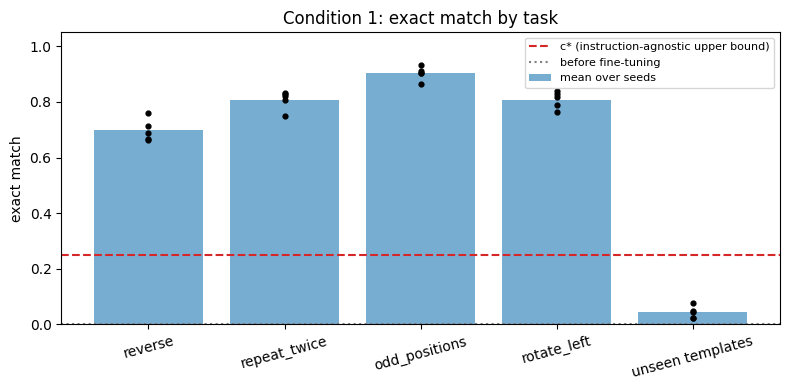

In [13]:
def experiment_a_statistics(counts_by_seed: list, counts_by_input: list) -> dict:
    # counts_by_seed: シードごとの正解数(M 事例のうち)、counts_by_input: 入力ごとの正解数(S シード x K 課題のうち)
    p = np.array(counts_by_seed, dtype=np.float64) / EVAL_SIZE
    a = np.array(counts_by_input, dtype=np.float64) / (NUM_SEEDS_AB * TASK_COUNT)
    p_bar = float(p.mean())
    s_p = float(p.std(ddof=1))
    variance_by_input = float(a.var(ddof=1))
    binomial = p_bar * (1 - p_bar) / EVAL_SIZE  # 旧基準の第 2 項(診断量)
    return {
        "p_bar": p_bar,
        "s_p": s_p,
        "variance_by_input": variance_by_input,
        "sigma": math.sqrt(s_p**2 / NUM_SEEDS_AB + variance_by_input / NUM_EVAL_INPUTS),
        "sigma_old": math.sqrt(s_p**2 / NUM_SEEDS_AB + binomial),
        "binomial": binomial,
        "mean_of_inputs": float(a.mean()),
    }


_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
_condition_1 = MAIN_RECORDS[1]
_exact = np.stack([r["evaluation"]["exact"] for r in _condition_1]).astype(np.int64)  # (S, M)
EXACT_COUNTS_A = [int(v) for v in _exact.sum(axis=1)]
EXACT_COUNTS_BY_INPUT_A = [int(v) for v in by_input(_exact).sum(axis=0)]  # sum_s sum_k c_{x,k,s}
STATISTICS_A = experiment_a_statistics(EXACT_COUNTS_A, EXACT_COUNTS_BY_INPUT_A)
P_BAR, SIGMA_A = STATISTICS_A["p_bar"], STATISTICS_A["sigma"]
assert math.isclose(STATISTICS_A["mean_of_inputs"], P_BAR, rel_tol=1e-12, abs_tol=1e-15)
CONTRAST_A = P_BAR - C_STAR
verdict_A = three_way_verdict(CONTRAST_A, SIGMA_A)

print(
    f"{_smoke_tag}c* = {C_STAR:.4f}、M = {EVAL_SIZE}、|X| = {NUM_EVAL_INPUTS}、S = {NUM_SEEDS_AB}"
)
print(
    f"{_smoke_tag}条件 1 の完全一致率(シード順): "
    + ", ".join(f"{c / EVAL_SIZE:.4f}" for c in EXACT_COUNTS_A)
)
print(
    f"{_smoke_tag}p_bar = {P_BAR:.4f}、s_p = {STATISTICS_A['s_p']:.4f}、Var_x(a_x) = "
    f"{STATISTICS_A['variance_by_input']:.4e}、sigma_A = {SIGMA_A:.4f}(第 1 項 "
    f"{STATISTICS_A['s_p'] ** 2 / NUM_SEEDS_AB:.2e}、第 2 項 {STATISTICS_A['variance_by_input'] / NUM_EVAL_INPUTS:.2e})"
)
print(f"{_smoke_tag}対比量 p_bar - c* = {CONTRAST_A:+.4f}、2 sigma_A = {2 * SIGMA_A:.4f}")
print(
    f"{_smoke_tag}前提条件: P0={precondition_status['P0']}、P-A={precondition_status['P-A']}、"
    f"P-L={precondition_status['P-L(A・B)']}"
)
print(f"{_smoke_tag}判定関数の結果: {verdict_A}")
print(
    f"{_smoke_tag}診断量: 旧基準の第 2 項 p_bar (1 - p_bar) / M = {STATISTICS_A['binomial']:.2e}"
    f"(旧基準の sigma_A = {STATISTICS_A['sigma_old']:.4f}、旧基準の判定関数の結果: "
    f"{three_way_verdict(CONTRAST_A, STATISTICS_A['sigma_old'])})"
)
print(
    f"{_smoke_tag}診断量: 条件 1 の応答部分の負の対数尤度(シード順): "
    + ", ".join(f"{v:.4f}" for v in response_loss_by_seed(_condition_1))
    + f"(微調整前 {BASE_RESPONSE_LOSS[False]:.4f})"
)
_unseen = [float(r["evaluation"]["unseen_exact"].mean()) for r in _condition_1]
print(
    f"{_smoke_tag}診断量: 未見テンプレートでの完全一致率(シード順): "
    + ", ".join(f"{v:.4f}" for v in _unseen)
)
_task_index = np.array([TASK_NAMES.index(e.task) for e in EVAL_EXAMPLES])
_per_task = {
    t: [float(r["evaluation"]["exact"][_task_index == k].mean()) for r in _condition_1]
    for k, t in enumerate(TASK_NAMES)
}
for _task, _values in _per_task.items():
    print(
        f"{_smoke_tag}診断量: 課題別の完全一致率 [{_task}](シード順): "
        + ", ".join(f"{v:.4f}" for v in _values)
    )
print(
    f"{_smoke_tag}診断量: 条件 1 の形式の遵守率(シード順): "
    + ", ".join(f"{r['evaluation']['format_ok'].mean():.4f}" for r in _condition_1)
)
print("\n--- 条件 1(シード 0)の生成例 ---")
for _e, _text in list(zip(EVAL_EXAMPLES, _condition_1[0]["evaluation"]["texts"], strict=True))[
    :TASK_COUNT
]:
    print(
        f"[{_e.task}] 入力 {' '.join(_e.words)!r}、正解 {' '.join(_e.answer)!r} -> 生成 {_text!r}"
    )

_fig, _ax = plt.subplots(figsize=(8, 4))
_x = np.arange(TASK_COUNT + 1)
_labels = [*TASK_NAMES, "unseen templates"]
_values = [_per_task[t] for t in TASK_NAMES] + [_unseen]
_ax.bar(_x, [np.mean(v) for v in _values], color="tab:blue", alpha=0.6, label="mean over seeds")
for _i, _v in enumerate(_values):
    _ax.scatter([_i] * len(_v), _v, color="black", s=12, zorder=3)
_ax.axhline(C_STAR, color="tab:red", linestyle="--", label="c* (instruction-agnostic upper bound)")
_ax.axhline(BASE_EXACT_MATCH, color="gray", linestyle=":", label="before fine-tuning")
_ax.set_xticks(_x, _labels, rotation=15)
_ax.set_ylim(0, 1.05)
_ax.set_ylabel("exact match")
_ax.set_title(("[smoke test] " if SMOKE_TEST else "") + "Condition 1: exact match by task")
_ax.legend(fontsize=8)
_fig.tight_layout()
plt.show()

### 6.7 実験 B: 損失マスクの効果と指示の長さの交互作用

評価集合の標本誤差の項は、入力を 4 条件・全シードで共通に復元抽出するブートストラップで求める(6.1 節)。
入力ごとに $K$ 事例の和をとった分子・分母を単位として復元抽出する。これは、事例を入力ごとのクラスタとして復元抽出する
ブートストラップ(015 の方式)と同じ再標本を与えることを、アサーションで確かめる。

L_1,s(応答部分、nats / トークン、シード順): 0.60045, 0.64732, 0.60105, 0.57972, 0.60952
L_2,s(応答部分、nats / トークン、シード順): 1.82754, 1.52110, 1.85497, 1.58622, 2.20648
L_3,s(応答部分、nats / トークン、シード順): 1.29383, 0.70892, 0.81696, 0.87589, 1.10478
L_4,s(応答部分、nats / トークン、シード順): 3.42677, 3.42573, 3.39077, 3.41170, 3.45042
D_s(シード順): +0.90585, +1.84303, +1.31989, +1.52931, +0.74868
D = +1.26935、s_D = 0.44790、Var_boot(D)(入力単位)= 2.192e-04、sigma_D = 0.20085、2 sigma_D = 0.40171
P-B [short]: 指示部分の負の対数尤度の差(マスクあり - なし)= +6.8455、sigma = 0.1346 -> > 2 sigma
P-B [long]: 指示部分の負の対数尤度の差(マスクあり - なし)= +8.4725、sigma = 0.0830 -> > 2 sigma
前提条件: P0=True、P-L=True、P-B=True
判定関数の結果: 反証
診断量: 事例を単位とするブートストラップ(旧基準)の Var_boot(D) = 1.059e-03(入力単位との比 0.21)、旧基準の sigma_D = 0.20294、旧基準の判定関数の結果: 反証
診断量 条件 1: 完全一致率 0.8180, 0.7600, 0.8070, 0.8380, 0.7970、指示部分の負の対数尤度 7.945, 8.389, 8.706, 8.050, 8.301
診断量 条件 2: 完全一致率 0.0570, 0.0760, 0.0780, 0.0590, 0.0200、指示部分の負の対数尤度 1.432, 1.436, 1.432, 1.434, 1.430
診断量 条件 3: 完全一致率 0.2730, 0.6670, 0.5690, 0.5340, 

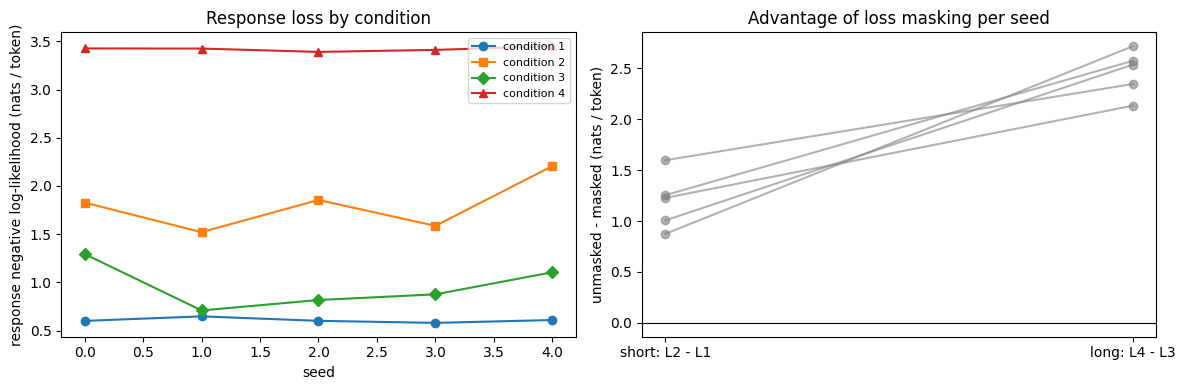

In [14]:
def paired_contrast(numerators_by_condition: dict, counts: np.ndarray, weights: dict) -> dict:
    # シードごとの対比量 sum_i weights[i] * (合計_{i,s} / 分母) と、その標準偏差
    # sqrt(s^2 / S + Var_boot)。Var_boot は入力を全条件・全シードで共通に復元抽出するブートストラップ(判定)。
    # 事例を単位とするブートストラップ(旧基準)は診断量として返す。
    totals = {c: [float(row.sum()) for row in rows] for c, rows in numerators_by_condition.items()}
    denominator = int(counts.sum())
    per_seed = np.array(
        [
            sum(w * totals[c][s] / denominator for c, w in weights.items())
            for s in range(NUM_SEEDS_AB)
        ]
    )
    per_example = sum(w * np.mean(numerators_by_condition[c], axis=0) for c, w in weights.items())
    per_input = by_input(per_example)
    counts_by_input = by_input(counts)
    boot = paired_bootstrap_ratio_of_sums(
        per_input, counts_by_input, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
    )
    cluster = paired_cluster_bootstrap_ratio_of_sums(
        per_example, counts, EVAL_INPUT_INDEX, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
    )
    assert np.allclose(boot, cluster, rtol=1e-9, atol=1e-12), (
        "入力単位とクラスタ単位の再標本が一致しない"
    )
    example = paired_bootstrap_ratio_of_sums(
        per_example, counts, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
    )
    seed_std = float(per_seed.std(ddof=1))
    return {
        "per_seed": per_seed,
        "mean": float(per_seed.mean()),
        "seed_std": seed_std,
        "var_boot": float(boot.var(ddof=1)),
        "var_boot_example": float(example.var(ddof=1)),
        "sigma": math.sqrt(seed_std**2 / NUM_SEEDS_AB + float(boot.var(ddof=1))),
        "sigma_example": math.sqrt(seed_std**2 / NUM_SEEDS_AB + float(example.var(ddof=1))),
        "per_input": per_input,
        "counts_by_input": counts_by_input,
        "totals": totals,
    }


_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
# 応答部分のトークン数が全条件・全シードで同一であること(トークンあたりの比較の前提)
for _records in MAIN_RECORDS.values():
    for _r in _records:
        assert np.array_equal(_r["evaluation"]["response_count"], RESPONSE_TOKEN_COUNTS)
_response_sums = {
    c: np.stack([r["evaluation"]["response_sum"] for r in rs]) for c, rs in MAIN_RECORDS.items()
}
CONTRAST_B = paired_contrast(_response_sums, RESPONSE_TOKEN_COUNTS, {4: 1, 3: -1, 2: -1, 1: 1})
D_B, SIGMA_D = CONTRAST_B["mean"], CONTRAST_B["sigma"]
verdict_B = three_way_verdict(-D_B, SIGMA_D)  # 期待する方向は D < 0

# 前提条件 P-B: 指示部分の負の対数尤度(マスクあり - マスクなし)> 2 sigma を両方の長さの水準で
PROMPT_CONTRASTS = {}
for _level, (_a, _u), _long in (("short", (1, 2), False), ("long", (3, 4), True)):
    for _r in MAIN_RECORDS[_a] + MAIN_RECORDS[_u]:
        assert np.array_equal(_r["evaluation"]["prompt_count"], PROMPT_TOKEN_COUNTS[_long])
    _prompt_sums = {
        c: np.stack([r["evaluation"]["prompt_sum"] for r in MAIN_RECORDS[c]]) for c in (_a, _u)
    }
    PROMPT_CONTRASTS[_level] = paired_contrast(
        _prompt_sums, PROMPT_TOKEN_COUNTS[_long], {_a: 1, _u: -1}
    )
precondition_status["P-B"] = bool(
    all(v["mean"] > 2 * v["sigma"] for v in PROMPT_CONTRASTS.values())
)

_losses = {c: [t / RESPONSE_TOKEN_TOTAL for t in CONTRAST_B["totals"][c]] for c in CONDITIONS}
for _c in CONDITIONS:
    print(
        f"{_smoke_tag}L_{_c},s(応答部分、nats / トークン、シード順): "
        + ", ".join(f"{v:.5f}" for v in _losses[_c])
    )
print(f"{_smoke_tag}D_s(シード順): " + ", ".join(f"{v:+.5f}" for v in CONTRAST_B["per_seed"]))
print(
    f"{_smoke_tag}D = {D_B:+.5f}、s_D = {CONTRAST_B['seed_std']:.5f}、Var_boot(D)(入力単位)= "
    f"{CONTRAST_B['var_boot']:.3e}、sigma_D = {SIGMA_D:.5f}、2 sigma_D = {2 * SIGMA_D:.5f}"
)
for _level, _v in PROMPT_CONTRASTS.items():
    print(
        f"{_smoke_tag}P-B [{_level}]: 指示部分の負の対数尤度の差(マスクあり - なし)= {_v['mean']:+.4f}、"
        f"sigma = {_v['sigma']:.4f} -> {'>' if _v['mean'] > 2 * _v['sigma'] else '<='} 2 sigma"
    )
print(
    f"{_smoke_tag}前提条件: P0={precondition_status['P0']}、P-L={precondition_status['P-L(A・B)']}、"
    f"P-B={precondition_status['P-B']}"
)
print(f"{_smoke_tag}判定関数の結果: {verdict_B}")
print(
    f"{_smoke_tag}診断量: 事例を単位とするブートストラップ(旧基準)の Var_boot(D) = "
    f"{CONTRAST_B['var_boot_example']:.3e}(入力単位との比 "
    f"{CONTRAST_B['var_boot'] / CONTRAST_B['var_boot_example']:.2f})、旧基準の sigma_D = "
    f"{CONTRAST_B['sigma_example']:.5f}、旧基準の判定関数の結果: "
    f"{three_way_verdict(-D_B, CONTRAST_B['sigma_example'])}"
)
for _c in CONDITIONS:
    _records = MAIN_RECORDS[_c]
    print(
        f"{_smoke_tag}診断量 条件 {_c}: 完全一致率 "
        + ", ".join(f"{r['evaluation']['exact'].mean():.4f}" for r in _records)
        + "、指示部分の負の対数尤度 "
        + ", ".join(f"{r['evaluation']['prompt_loss']:.3f}" for r in _records)
    )

_fig, _axes = plt.subplots(1, 2, figsize=(12, 4))
for _c, _marker in zip(CONDITIONS, "osD^", strict=True):
    _axes[0].plot(SEEDS_AB, _losses[_c], _marker + "-", label=f"condition {_c}")
_axes[0].set_xlabel("seed")
_axes[0].set_ylabel("response negative log-likelihood (nats / token)")
_axes[0].set_title(("[smoke test] " if SMOKE_TEST else "") + "Response loss by condition")
_axes[0].legend(fontsize=8)
_short = np.array(_losses[2]) - np.array(_losses[1])
_long = np.array(_losses[4]) - np.array(_losses[3])
for _s in SEEDS_AB:
    _axes[1].plot([0, 1], [_short[_s], _long[_s]], "o-", color="gray", alpha=0.6)
_axes[1].axhline(0, color="black", linewidth=0.8)
_axes[1].set_xticks([0, 1], ["short: L2 - L1", "long: L4 - L3"])
_axes[1].set_ylabel("unmasked - masked (nats / token)")
_axes[1].set_title("Advantage of loss masking per seed")
_fig.tight_layout()
plt.show()

### 6.8 コピー能力の診断(判定基準を設けない観察)

学習データに含まれない 8 語の単語列(テンプレートなし)を 2 回繰り返した系列で、1 回目と 2 回目の単語の負の対数尤度の
平均を測る(6.1 節)。対象は微調整前のモデルと条件 1 のシード 0(C-$N_{\max}$ のシード 0 と同一の学習)。
**定性的な観察であり、判定基準を設けない。**

In [15]:
COPY_RESULTS = {
    "base": print_copy_losses("微調整前のモデル", base_model),
    "condition_1_seed_0": print_copy_losses(
        "条件 1・シード 0(= C-N_max・シード 0)", KEPT_CONDITION_1_MODEL
    ),
}

微調整前のモデル: 1 回目の単語 11.426 nats、2 回目の単語 10.691 nats(差 +0.735、64 系列 x 8 語)
条件 1・シード 0(= C-N_max・シード 0): 1 回目の単語 9.911 nats、2 回目の単語 8.984 nats(差 +0.928、64 系列 x 8 語)


### 6.9 実験 C の学習(C-$N_{\max}$ は条件 1 と共有)

選ばれた段階の実験 C の水準・シード(6.4 節)で学習する(gradient clipping なし)。C-$N_{\max}$ は条件 1 と同一の設定
なので学習を重複して実行せず、条件 1 の同じシードの記録をそのまま使う(共有していることをアサーションで確かめる)。
前提条件 P-L は C-$N_{\max}$ の全シードについて記録し、$N < N_{\max}$ の水準の同じ量は診断量として印字する(6.1 節)。

In [16]:
C_RECORDS = {n: [] for n in C_LEVELS}
_t0_c = time.time()
for _n in C_LEVELS:
    for _seed in SEEDS_C:
        if _n == N_MAX:  # C-N_max は条件 1 と共有する(同じ学習を重複して実行しない)
            C_RECORDS[_n].append(MAIN_RECORDS[1][SEEDS_AB.index(_seed)])
            continue
        _record = run_condition(1, _seed, _n)
        C_RECORDS[_n].append(_record)
        print(
            f"C-{_n}(エポック {_record['max_epochs']:g})seed={_seed}: 学習 {_record['train_seconds']:.1f}s・"
            f"評価 {_record['eval_seconds']:.1f}s"
        )
print(f"実験 C の学習と評価の合計: {time.time() - _t0_c:.1f}s")

# --- C-N_max と条件 1 の共有の確認 ---
for _seed, _record in zip(SEEDS_C, C_RECORDS[N_MAX], strict=True):
    assert _record is MAIN_RECORDS[1][SEEDS_AB.index(_seed)], "C-N_max が条件 1 の記録と同一でない"
    assert (
        _record["condition"] == 1 and _record["num_examples"] == N_MAX and _record["seed"] == _seed
    )
print(
    f"C-N_max(シード {SEEDS_C})は条件 1 の同じシードの学習の記録と同一(共有、再学習していない): OK"
)

# --- 前提条件 P-L(C-N_max の全シードのみ、6.2 節の改訂 7) ---
_limit = PRECONDITION_L_RATIO * BASE_RESPONSE_LOSS[False]
_pl_rows = [r["evaluation"]["response_loss"] <= _limit for r in C_RECORDS[N_MAX]]
precondition_status["P-L(C-N_max)"] = bool(all(_pl_rows))
print(
    f"P-L(C-N_max の全 {len(_pl_rows)} シード): {'成立' if precondition_status['P-L(C-N_max)'] else '不成立'}"
    f"(満たしたシード {sum(_pl_rows)} / {len(_pl_rows)})"
)
# 診断量(判定には使わない): N < N_max の水準で、応答部分の負の対数尤度が微調整前の 1/2 以下か
for _n in C_LEVELS[:-1]:
    print(
        f"診断量 C-{_n}: 応答部分の負の対数尤度 <= {PRECONDITION_L_RATIO} x 微調整前(シード順): "
        + ", ".join(str(bool(r["evaluation"]["response_loss"] <= _limit)) for r in C_RECORDS[_n])
    )

C-16(エポック 4096)seed=0: 学習 60.8s・評価 10.5s
C-16(エポック 4096)seed=1: 学習 60.8s・評価 11.3s
C-16(エポック 4096)seed=2: 学習 61.6s・評価 11.8s
C-16(エポック 4096)seed=3: 学習 61.2s・評価 10.7s
C-16(エポック 4096)seed=4: 学習 61.0s・評価 11.3s
C-64(エポック 1024)seed=0: 学習 61.0s・評価 10.3s
C-64(エポック 1024)seed=1: 学習 60.9s・評価 8.9s
C-64(エポック 1024)seed=2: 学習 60.7s・評価 9.9s
C-64(エポック 1024)seed=3: 学習 60.7s・評価 10.3s
C-64(エポック 1024)seed=4: 学習 60.7s・評価 10.0s
C-256(エポック 256)seed=0: 学習 61.1s・評価 9.5s
C-256(エポック 256)seed=1: 学習 61.5s・評価 9.2s
C-256(エポック 256)seed=2: 学習 61.0s・評価 9.6s
C-256(エポック 256)seed=3: 学習 61.2s・評価 9.2s
C-256(エポック 256)seed=4: 学習 61.2s・評価 8.3s
C-1024(エポック 64)seed=0: 学習 61.6s・評価 6.2s
C-1024(エポック 64)seed=1: 学習 61.3s・評価 6.9s
C-1024(エポック 64)seed=2: 学習 62.0s・評価 6.0s
C-1024(エポック 64)seed=3: 学習 61.2s・評価 6.9s
C-1024(エポック 64)seed=4: 学習 61.0s・評価 6.2s
C-4096(エポック 16)seed=0: 学習 61.3s・評価 6.9s
C-4096(エポック 16)seed=1: 学習 61.5s・評価 6.0s
C-4096(エポック 16)seed=2: 学習 62.4s・評価 7.3s
C-4096(エポック 16)seed=3: 学習 62.4s・評価 6.2s
C-4096(エポック 16)seed=4: 学習 61.6s・

### 6.10 実験 C: 形式の習得と課題の習得の速さ

評価集合の標本誤差の項 $\mathrm{Var}_{\mathrm{boot}}(\Delta)$ は、入力を復元抽出するブートストラップで求める。各反復で、
入力ごとの正解数(形式の遵守・完全一致、水準 × シード × 入力)に同じ重みを掛けて全水準・両指標・全シードの率を
計算し直し、シードごとの $N_{90}$ と $\Delta$ を求める(6.1 節)。

水準 N: (16, 64, 256, 1024, 4096, 16384, 65536)
     N | 形式の遵守率(シード順)                             | 完全一致率(シード順)                              | 応答部分の負の対数尤度
    16 | 0.901, 0.842, 0.862, 0.945, 0.943        | 0.000, 0.000, 0.000, 0.000, 0.000        | 5.126, 5.169, 4.977, 4.969, 5.050
    64 | 0.984, 0.987, 0.975, 0.987, 0.963        | 0.000, 0.000, 0.000, 0.000, 0.000        | 4.995, 4.996, 5.061, 4.994, 4.929
   256 | 0.992, 0.983, 0.982, 0.974, 0.991        | 0.000, 0.000, 0.000, 0.000, 0.000        | 4.328, 4.341, 4.383, 4.298, 4.376
  1024 | 1.000, 1.000, 1.000, 1.000, 1.000        | 0.480, 0.418, 0.446, 0.334, 0.517        | 0.929, 0.997, 0.986, 1.194, 0.917
  4096 | 1.000, 1.000, 1.000, 1.000, 1.000        | 0.607, 0.740, 0.681, 0.564, 0.795        | 0.779, 0.664, 0.681, 0.783, 0.634
 16384 | 1.000, 1.000, 1.000, 1.000, 1.000        | 0.749, 0.824, 0.773, 0.791, 0.835        | 0.644, 0.602, 0.619, 0.623, 0.584
 65536 | 1.000, 1.000, 1.000, 1.000, 1.000        | 0.818, 0.760, 0.807, 

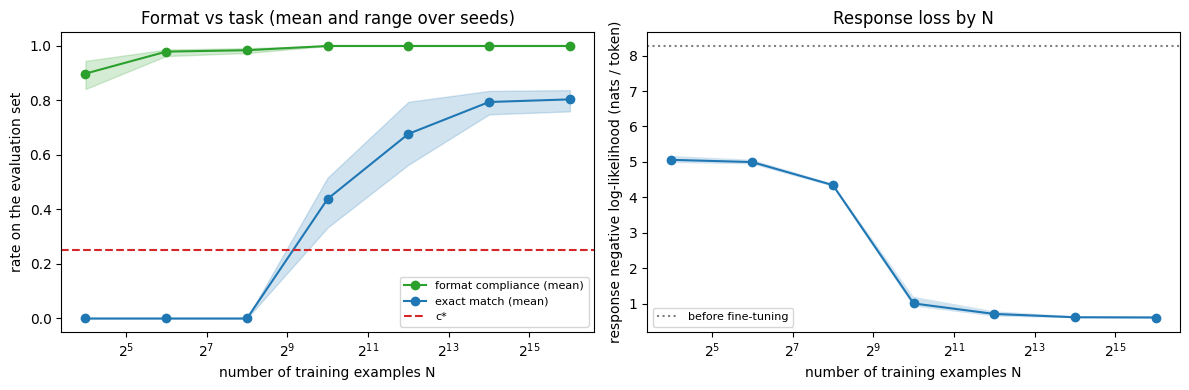

In [17]:
def n90(values, levels: tuple[int, ...]) -> tuple[float, bool]:
    # 飽和値(最大水準の値)の 90% に初めて達するデータ数の log2 と、打ち切りの有無(6.1 節)
    threshold = 0.9 * values[-1]
    logs = [math.log2(n) for n in levels]
    if values[0] >= threshold:
        return logs[0], True
    for j in range(1, len(levels)):
        if values[j] >= threshold:
            fraction = (threshold - values[j - 1]) / (values[j] - values[j - 1])
            return logs[j - 1] + fraction * (logs[j] - logs[j - 1]), False
    raise AssertionError("最大水準の値は必ず閾値以上になる")


def delta_from_rates(
    format_rates: np.ndarray, exact_rates: np.ndarray, levels
) -> tuple[float, list]:
    # format_rates・exact_rates: 形状 (水準, シード)。シードごとの N90 と、その差の平均 Delta を返す。
    rows = []
    for s in range(format_rates.shape[1]):
        log_format, censored_format = n90(list(format_rates[:, s]), levels)
        log_task, censored_task = n90(list(exact_rates[:, s]), levels)
        rows.append(
            {
                "log2_n90_format": log_format,
                "log2_n90_task": log_task,
                "censored_format": censored_format,
                "censored_task": censored_task,
                "difference": log_task - log_format,
            }
        )
    return float(np.mean([r["difference"] for r in rows])), rows


def experiment_c_statistics(
    format_by_input, exact_by_input, levels, num_tasks: int, resamples: int, seed: int
) -> dict:
    # format_by_input・exact_by_input: 形状 (水準, シード, 入力) の正解数(各 0..K)。
    format_by_input = np.asarray(format_by_input, dtype=np.float64)
    exact_by_input = np.asarray(exact_by_input, dtype=np.float64)
    num_inputs = format_by_input.shape[2]
    denominator = num_inputs * num_tasks
    format_rates = format_by_input.sum(axis=2) / denominator
    exact_rates = exact_by_input.sum(axis=2) / denominator
    delta, rows = delta_from_rates(format_rates, exact_rates, levels)
    num_seeds = format_rates.shape[1]
    seed_std = float(np.std([r["difference"] for r in rows], ddof=1))
    # 入力を復元抽出するブートストラップ: 各反復で全水準・両指標・全シードに同じ重みを使う
    rng = np.random.default_rng(seed)
    weights = rng.multinomial(
        num_inputs, np.full(num_inputs, 1.0 / num_inputs), size=resamples
    ).astype(np.float64)
    format_boot = (
        np.einsum("rx,lsx->rls", weights, format_by_input) / denominator
    )  # sum_x w_x = |X|
    exact_boot = np.einsum("rx,lsx->rls", weights, exact_by_input) / denominator
    deltas = np.array(
        [delta_from_rates(format_boot[r], exact_boot[r], levels)[0] for r in range(resamples)]
    )
    var_boot = float(deltas.var(ddof=1))
    return {
        "rows": rows,
        "delta": delta,
        "seed_std": seed_std,
        "var_boot": var_boot,
        "sigma": math.sqrt(seed_std**2 / num_seeds + var_boot),
        "sigma_old": seed_std / math.sqrt(num_seeds),
        "saturation_exact": float(exact_rates[-1].mean()),
        "saturation_format": float(format_rates[-1].mean()),
        "format_rates": format_rates,
        "exact_rates": exact_rates,
    }


_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
FORMAT_BY_INPUT_C = [
    [
        [int(v) for v in by_input(r["evaluation"]["format_ok"].astype(np.int64))]
        for r in C_RECORDS[n]
    ]
    for n in C_LEVELS
]
EXACT_BY_INPUT_C = [
    [[int(v) for v in by_input(r["evaluation"]["exact"].astype(np.int64))] for r in C_RECORDS[n]]
    for n in C_LEVELS
]
STATISTICS_C = experiment_c_statistics(
    FORMAT_BY_INPUT_C, EXACT_BY_INPUT_C, C_LEVELS, TASK_COUNT, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED
)
for _j, _n in enumerate(C_LEVELS):  # 入力ごとの和から求めた率が、事例ごとの平均と一致すること
    for _s, _r in enumerate(C_RECORDS[_n]):
        assert math.isclose(
            STATISTICS_C["format_rates"][_j, _s], float(_r["evaluation"]["format_ok"].mean())
        )
        assert math.isclose(
            STATISTICS_C["exact_rates"][_j, _s], float(_r["evaluation"]["exact"].mean())
        )
DELTA_C, SIGMA_C = STATISTICS_C["delta"], STATISTICS_C["sigma"]
verdict_C = three_way_verdict(DELTA_C, SIGMA_C)
precondition_status["P-C"] = bool(
    STATISTICS_C["saturation_exact"] >= 2 * C_STAR and STATISTICS_C["saturation_format"] >= 0.5
)

print(f"{_smoke_tag}水準 N: {C_LEVELS}")
print(
    f"{_smoke_tag}{'N':>6} | {'形式の遵守率(シード順)':<40} | {'完全一致率(シード順)':<40} | 応答部分の負の対数尤度"
)
for _j, _n in enumerate(C_LEVELS):
    print(
        f"{_smoke_tag}{_n:>6} | "
        + ", ".join(f"{v:.3f}" for v in STATISTICS_C["format_rates"][_j]).ljust(40)
        + " | "
        + ", ".join(f"{v:.3f}" for v in STATISTICS_C["exact_rates"][_j]).ljust(40)
        + " | "
        + ", ".join(f"{v:.3f}" for v in response_loss_by_seed(C_RECORDS[_n]))
    )
for _s, _row in enumerate(STATISTICS_C["rows"]):
    print(
        f"{_smoke_tag}seed={_s}: log2 N90(形式)= {_row['log2_n90_format']:.3f}"
        f"{'(打ち切り)' if _row['censored_format'] else ''}、log2 N90(課題)= {_row['log2_n90_task']:.3f}"
        f"{'(打ち切り)' if _row['censored_task'] else ''}、差 {_row['difference']:+.3f}"
    )
print(
    f"{_smoke_tag}Delta = {DELTA_C:+.4f}、s_Delta = {STATISTICS_C['seed_std']:.4f}、Var_boot(Delta)(入力単位)= "
    f"{STATISTICS_C['var_boot']:.4e}、sigma_Delta = {SIGMA_C:.4f}、2 sigma_Delta = {2 * SIGMA_C:.4f}"
)
print(
    f"{_smoke_tag}P-C: N_max での完全一致率 {STATISTICS_C['saturation_exact']:.4f} >= 2c* = {2 * C_STAR:.2f}、"
    f"形式の遵守率 {STATISTICS_C['saturation_format']:.4f} >= 0.5 -> {precondition_status['P-C']}"
)
print(
    f"{_smoke_tag}前提条件: P0={precondition_status['P0']}、P-L(C-N_max)={precondition_status['P-L(C-N_max)']}、"
    f"P-C={precondition_status['P-C']}"
)
print(f"{_smoke_tag}判定関数の結果: {verdict_C}")
print(
    f"{_smoke_tag}診断量: 旧基準の sigma_Delta = s_Delta / sqrt(S) = {STATISTICS_C['sigma_old']:.4f}"
    f"(旧基準の判定関数の結果: {three_way_verdict(DELTA_C, STATISTICS_C['sigma_old'])})"
)

_fig, _axes = plt.subplots(1, 2, figsize=(12, 4))
for _label, _rates, _color in (
    ("format compliance", STATISTICS_C["format_rates"], "tab:green"),
    ("exact match", STATISTICS_C["exact_rates"], "tab:blue"),
):
    _axes[0].plot(C_LEVELS, _rates.mean(axis=1), "o-", color=_color, label=f"{_label} (mean)")
    _axes[0].fill_between(C_LEVELS, _rates.min(axis=1), _rates.max(axis=1), color=_color, alpha=0.2)
_axes[0].axhline(C_STAR, color="tab:red", linestyle="--", label="c*")
_axes[0].set_xscale("log", base=2)
_axes[0].set_xlabel("number of training examples N")
_axes[0].set_ylabel("rate on the evaluation set")
_axes[0].set_title(
    ("[smoke test] " if SMOKE_TEST else "") + "Format vs task (mean and range over seeds)"
)
_axes[0].legend(fontsize=8)
_losses_c = np.array([response_loss_by_seed(C_RECORDS[n]) for n in C_LEVELS])
_axes[1].plot(C_LEVELS, _losses_c.mean(axis=1), "o-")
_axes[1].fill_between(C_LEVELS, _losses_c.min(axis=1), _losses_c.max(axis=1), alpha=0.2)
_axes[1].axhline(BASE_RESPONSE_LOSS[False], color="gray", linestyle=":", label="before fine-tuning")
_axes[1].set_xscale("log", base=2)
_axes[1].set_xlabel("number of training examples N")
_axes[1].set_ylabel("response negative log-likelihood (nats / token)")
_axes[1].set_title("Response loss by N")
_axes[1].legend(fontsize=8)
_fig.tight_layout()
plt.show()

### 6.11 不変条件のアサーションと`SMOKE_TEST`の配線

- 全ての実行で、ステップ数・学習履歴の長さが $T$、学習可能パラメータ数が閉形式 $4 L r d_{\mathrm{model}}$ と一致し、
  gradient clipping が一度も発動していない(無効)。
- 条件 1〜4: データ数が $N_{\max}$(1 エポックちょうど)。同じシードでは条件 1〜4 のミニバッチの添字が同一、
  異なるシードでは異なる。評価の配列の長さが $M$。
- 実験 C: データの部分集合が入れ子であり(各水準は学習データの先頭 $N$ 個)、エポック数が $Tb/N$、ミニバッチの添字の
  ハッシュが同じ引数で作り直した値と一致する。C-$N_{\max}$ は条件 1 の記録と同一(6.9 節)。
- 評価集合の事例ごとの応答部分のトークン数が全実行で同一。
- ベースモデルの重みが、全ての学習の後も Hub から読み込んだ重みと完全に一致する。
- `SMOKE_TEST`の配線と削る段階: 実際に使ったシード・水準・ステップ数・データ数・評価集合の大きさ・ブートストラップの
  反復回数が、5.2 節の水準と 6.4 節で選ばれた段階と一致する。

In [18]:
_all = [r for rs in MAIN_RECORDS.values() for r in rs]
for _r in _all:
    assert _r["num_steps"] == _r["history_length"] == NUM_STEPS, "ステップ数が T と一致しない"
    assert _r["num_examples"] == N_MAX and _r["max_epochs"] == 1.0
    assert _r["num_trainable_parameters"] == LORA_PARAMETERS
    assert not _r["any_clip_triggered"], "gradient clipping が発動した"
    assert len(_r["evaluation"]["exact"]) == EVAL_SIZE
for _s in SEEDS_AB:
    assert len({MAIN_RECORDS[c][_s]["batches_hash"] for c in CONDITIONS}) == 1, (
        "条件間でデータ順序が異なる"
    )
assert len({MAIN_RECORDS[1][s]["batches_hash"] for s in SEEDS_AB}) == NUM_SEEDS_AB
for _n, _records in C_RECORDS.items():
    for _s, _r in zip(SEEDS_C, _records, strict=True):
        assert _r["num_steps"] == _r["history_length"] == NUM_STEPS, "ステップ数が T と一致しない"
        assert _r["num_examples"] == _n and _r["seed"] == _s and not _r["any_clip_triggered"]
        assert _r["num_trainable_parameters"] == LORA_PARAMETERS
        assert _r["max_epochs"] == NUM_STEPS * BATCH_SIZE / _n
        assert _r["batches_hash"] == hash_json(make_epoch_batches(_n, NUM_STEPS, BATCH_SIZE, _s))
        assert np.array_equal(_r["evaluation"]["response_count"], RESPONSE_TOKEN_COUNTS)
assert all(
    max(i for b in make_epoch_batches(n, NUM_STEPS, BATCH_SIZE, 0) for i in b) == n - 1
    for n in C_LEVELS
)
assert all(C_RECORDS[N_MAX][i] is MAIN_RECORDS[1][i] for i in range(NUM_SEEDS_C))
_hub_state = torch.load(MODEL_STATE_PATH, map_location="cpu")
assert all(torch.equal(v.cpu(), _hub_state[k]) for k, v in base_model.state_dict().items())
# SMOKE_TEST の配線と削る段階
assert all([r["seed"] for r in rs] == list(SEEDS_AB) for rs in MAIN_RECORDS.values())
assert (
    tuple(range(STAGE["NUM_SEEDS_AB"])) == SEEDS_AB
    and tuple(range(STAGE["NUM_SEEDS_C"])) == SEEDS_C
)
assert (
    tuple(C_RECORDS) == C_LEVELS == c_levels(STAGE["C_MIN_LEVEL"], N_MAX) and C_LEVELS[-1] == N_MAX
)
assert STAGES[CURRENT_LEVEL_NAME][SELECTED_STAGE] == STAGE and CFG["NUM_STEPS"] == NUM_STEPS
assert CFG["NUM_EVAL_INPUTS"] * TASK_COUNT == EVAL_SIZE and CFG["NUM_STEPS"] * BATCH_SIZE == N_MAX
assert paired_bootstrap_ratio_of_sums(
    np.ones(NUM_EVAL_INPUTS), np.ones(NUM_EVAL_INPUTS), BOOTSTRAP_RESAMPLES, 0
).shape == (CFG["BOOTSTRAP_RESAMPLES"],)
_num_c_runs = sum(len(rs) for rs in C_RECORDS.values())
print(
    f"条件 1〜4 の全 {len(_all)} 実行と実験 C の全 {_num_c_runs} 実行(うち C-N_max の {NUM_SEEDS_C} 実行は条件 1 と共有): "
    "ステップ数・データ数・学習可能パラメータ数・gradient clipping の不発動・データ順序・入れ子・応答部分のトークン数: OK"
)
print("ベースモデルの重みが Hub から読み込んだ重みと完全一致: OK")
print(
    f"SMOKE_TEST の配線と削る段階: 水準 {CURRENT_LEVEL_NAME!r}・段階 {SELECTED_STAGE}(実験 A・B のシード {SEEDS_AB}、"
    f"実験 C のシード {SEEDS_C}、水準 {C_LEVELS}、T {NUM_STEPS}、M {EVAL_SIZE}、反復 {BOOTSTRAP_RESAMPLES})が一致: OK"
)

条件 1〜4 の全 20 実行と実験 C の全 35 実行(うち C-N_max の 5 実行は条件 1 と共有): ステップ数・データ数・学習可能パラメータ数・gradient clipping の不発動・データ順序・入れ子・応答部分のトークン数: OK
ベースモデルの重みが Hub から読み込んだ重みと完全一致: OK
SMOKE_TEST の配線と削る段階: 水準 'prod'・段階 0(実験 A・B のシード (0, 1, 2, 3, 4)、実験 C のシード (0, 1, 2, 3, 4)、水準 (16, 64, 256, 1024, 4096, 16384, 65536)、T 2048、M 1000、反復 10000)が一致: OK


### 6.12 判定結果の一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは区別する)。
判定関数の結果は参考として別欄に残す。標準偏差は入力を単位とする新基準による。旧基準(事例を単位とする)の
標準偏差も、判定に使わない参考値として並べる。選ばれた段階と、判定に実際に使ったシード数・水準を印字する。

In [19]:
def verdict_label(computed: str, preconditions: list[str]) -> str:
    return computed if all(precondition_status.get(p) for p in preconditions) else "前提不成立"


_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""
print(f"{_smoke_tag}段階の選択: {STAGE_SELECTION_MESSAGE}")
print(
    f"{_smoke_tag}判定に使った値: 実験 A・B は S = {NUM_SEEDS_AB}(シード {SEEDS_AB})、実験 C は S = {NUM_SEEDS_C}"
    f"(シード {SEEDS_C})・水準 {C_LEVELS}(N_min = {C_LEVELS[0]})"
)
PRECONDITIONS = {
    "A": ["P0", "P-L(A・B)", "P-A"],
    "B": ["P0", "P-L(A・B)", "P-B"],
    "C": ["P0", "P-L(C-N_max)", "P-C"],
}
print(
    f"{_smoke_tag}実験 | 対比量(sigma は入力単位、括弧内は旧基準) | 前提条件の成否 | 判定関数の結果(参考) | 最終判定"
)
for _name, _stat, _computed in (
    (
        "A",
        f"p_bar - c* = {CONTRAST_A:+.4f}、sigma_A = {SIGMA_A:.4f}({STATISTICS_A['sigma_old']:.4f})",
        verdict_A,
    ),
    ("B", f"D = {D_B:+.5f}、sigma_D = {SIGMA_D:.5f}({CONTRAST_B['sigma_example']:.5f})", verdict_B),
    (
        "C",
        f"Delta = {DELTA_C:+.4f}、sigma_Delta = {SIGMA_C:.4f}({STATISTICS_C['sigma_old']:.4f})",
        verdict_C,
    ),
):
    _pre = ", ".join(f"{p}={precondition_status.get(p)}" for p in PRECONDITIONS[_name])
    print(
        f"{_smoke_tag}{_name} | {_stat} | {_pre} | {_computed} | {verdict_label(_computed, PRECONDITIONS[_name])}"
    )
if SMOKE_TEST:
    print(
        "上記はスモークテストによるコードの動作確認であり、本番実行の後に数値が変わるため、結論としては扱わない。"
    )

段階の選択: 予算 120 分に収まる最小の段階として、段階 0 を選んだ(見積もり 79.1 分、cuda 基準)
判定に使った値: 実験 A・B は S = 5(シード (0, 1, 2, 3, 4))、実験 C は S = 5(シード (0, 1, 2, 3, 4))・水準 (16, 64, 256, 1024, 4096, 16384, 65536)(N_min = 16)
実験 | 対比量(sigma は入力単位、括弧内は旧基準) | 前提条件の成否 | 判定関数の結果(参考) | 最終判定
A | p_bar - c* = +0.5540、sigma_A = 0.0186(0.0180) | P0=True, P-L(A・B)=True, P-A=True | 支持 | 支持
B | D = +1.26935、sigma_D = 0.20085(0.20294) | P0=True, P-L(A・B)=True, P-B=True | 反証 | 反証
C | Delta = +8.4202、sigma_Delta = 0.6042(0.5901) | P0=True, P-L(C-N_max)=True, P-C=True | 支持 | 支持


## 7. 結果・考察 / Results and Discussion

本番実行のセル出力に基づいて記す。判定は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は
「事後的な解釈」として節を分けて記し、検証済みの結論としては扱わない。

### 7.1 実行の概要

- **実行環境**(5.1 節の印字): Google Colab の Tesla T4(compute capability 7.5、総メモリ 14.56 GiB)、Python 3.13.15、
  torch 2.13.0+cu130、コミット`4c13e5d`(未コミットの変更なし)。決定的な実行の確認(5.6 節)は CUDA でも通った。
- **削る段階**(6.4 節): T4 での見積もりは段階 0 で 79.1 分(予算 120 分の 65.9%)、段階 1〜3 で 73.8・63.2・45.8 分
  だった。予算に収まる最小の段階として **段階 0** が選ばれた。したがって、実験 A・B・C はいずれも 5 シード(0〜4)、
  実験 C は $N \in \{16, 64, \dots, 65536\}$ の 7 水準で実行した(6.12 節の印字)。実際の実行時間は、実験 A・B の学習と
  評価が 2,463.6 秒(見積もり 2,613.6 秒)、実験 C の追加の学習と評価が 2,088.0 秒(見積もり 1,904.6 秒)だった。
- **前提条件はすべて成立した。**

| 前提条件 | 値 | 基準 | 成否 |
|---|---|---|---|
| P0 | 検証 bits-per-byte 1.668067(相対誤差 $1.57 \times 10^{-7}$) | 相対誤差 0.01 以内 | 成立 |
| P-A | 微調整前の完全一致率 0.0000 | $c^* = 0.25$ 未満 | 成立 |
| P-L(実験 A・B) | 条件 1〜4 の全 20 実行で満たした(応答部分の負の対数尤度の最大は、短い水準で 2.206、長い水準で 3.450) | 微調整前の 1/2 以下($L_0^{\mathrm{short}} = 8.2724$、$L_0^{\mathrm{long}} = 8.5841$) | 成立 |
| P-B | 指示部分の負の対数尤度の差: 短い水準 +6.8455($\sigma$ 0.1346)、長い水準 +8.4725($\sigma$ 0.0830) | 両水準で $2\sigma$ を超える | 成立 |
| P-L(実験 C) | C-$N_{\max}$ の全 5 シードで満たした(条件 1 と共有、0.580〜0.647) | 微調整前の 1/2 以下 | 成立 |
| P-C | $N_{\max}$ での完全一致率 0.8040、形式の遵守率 1.0000 | それぞれ $2c^* = 0.50$ 以上、0.5 以上 | 成立 |

### 7.2 実験 A(指示への依存)の判定結果

**判定: 支持。**

条件 1 の完全一致率はシード順に 0.8180・0.7600・0.8070・0.8380・0.7970 で、$\bar{p} = 0.8040$ だった。

$$
\bar{p} - c^* = 0.8040 - 0.25 = +0.5540, \qquad \sigma_A = 0.0186, \qquad 2\sigma_A = 0.0371
$$

$\sigma_A^2$ の 2 つの項は、シード間の項が $1.67 \times 10^{-4}$、入力単位の評価集合の項が $1.77 \times 10^{-4}$ で同程度だった。
$\bar{p} - c^* > 2\sigma_A$ なので、事前に宣言した基準により **支持** となる。SFT 後のモデルは、指示を無視して入力だけから
出力を決める任意の戦略の上界 $c^* = 0.25$ を大きく超えており、指示を読んで出力を切り替えている。6.1 節で注記したとおり、
$T$ はパイロットで学習がほぼ完了した点(完全一致率 0.927〜0.960)として選んだため、本実験は支持に偏りやすい設計であり、
本実験の役割は SFT の効果の提示と、$c^*$ に基づく厳密な判定にある。ただし本番では、条件 1 の完全一致率は 0.804 に留まり、
パイロットほど学習は完了していなかった(7.2.1 節)。

**課題別の完全一致率**(シード平均): 逆順 0.698、各単語を 2 回ずつ 0.807、奇数番目のみ 0.903、先頭を末尾へ移す回転 0.807
(図「Condition 1: exact match by task」)。逆順が最も低かった。形式の遵守率は全シードで 1.0000、
応答部分の負の対数尤度は 0.580〜0.647(微調整前は 8.2724)だった。

**宣言済みの診断量: 未見テンプレートでの完全一致率。** 学習に使わなかった指示文での完全一致率は、シード順に
0.0230・0.0220・0.0490・0.0780・0.0440 で、すべて $c^* = 0.25$ を下回った(図の右端の棒)。したがって、本実験で
「指示を読んで出力を切り替える」ことが示されたのは、**学習で見た指示文の言い回しの範囲に限られる**。学習で見ていない
言い回しで同じ課題を指示されたときに課題を識別できることは示されていない。

**生成例の観察(定性的)**: 条件 1・シード 0 の逆順の生成例では、正解`community novel member genus software billion green agreement`に
対して`community novel member genus global green green agreement`を出力した。前半の 4 語は正しいが、入力にない単語
(`global`)を出し、`green`を重複させている。形式(終端記号まで)は守られていた。1 例の観察であり、誤りの傾向を
測ったものではない。

#### 7.2.1 事後的な観察: パイロットと本番の完全一致率の差(検証済みの結論ではない)

**この小節は、結果を見た後の事後的な観察であり、検証済みの結論ではない。** 6.2 節に記録したパイロット(ローカルの MPS、
学習率 $10^{-2}$、$T = 2048$、評価入力 100 個、3 シード)では、条件 1 と同じ設定の完全一致率は 0.927〜0.960 だった。
本番の条件 1(CUDA の T4、同じ設定、評価入力 250 個、5 シード)では 0.760〜0.838 で、パイロットの範囲から外れている。

原因の候補として、(1)デバイスの違い(MPS と CUDA で浮動小数点の演算の順序・実装が異なり、同じシードでも学習の経過が
変わりうる)、(2)データ生成と評価集合の乱数の違い(パイロットと本番で学習データ・評価入力を別の乱数シードで生成した)、
(3)評価集合の大きさの違い(100 入力と 250 入力)、(4)指示文の多様さの違い(パイロットのスクリプトでは課題ごとに
1 つの指示文を学習・評価の両方に使ったのに対し、本番では課題ごとに 4 つの指示文を学習に使い、評価集合の事例ごとに
そのうち 1 つを割り当てた)が考えられる。いずれも検証していない。gradient clipping は両者とも使っていない。

この差は、実験 A の判定(支持)には影響しない。判定は本番のセル出力のみから導いており、$\bar{p} - c^* = +0.5540$ は
$2\sigma_A = 0.0371$ を大きく上回っている。

### 7.3 実験 B(損失マスクの効果と指示の長さの交互作用)の判定結果

**判定: 反証。**

| 条件 | 応答部分の負の対数尤度(シード 0〜4) | シード平均 | 完全一致率(シード 0〜4) |
|---|---|---|---|
| 1(マスクあり・短い) | 0.60045・0.64732・0.60105・0.57972・0.60952 | 0.6076 | 0.818・0.760・0.807・0.838・0.797 |
| 2(マスクなし・短い) | 1.82754・1.52110・1.85497・1.58622・2.20648 | 1.7993 | 0.057・0.076・0.078・0.059・0.020 |
| 3(マスクあり・長い) | 1.29383・0.70892・0.81696・0.87589・1.10478 | 0.9601 | 0.273・0.667・0.569・0.534・0.346 |
| 4(マスクなし・長い) | 3.42677・3.42573・3.39077・3.41170・3.45042 | 3.4211 | 0.000(全シード) |

$$
D = \frac{1}{S} \sum_s \left[ (L_{4,s} - L_{3,s}) - (L_{2,s} - L_{1,s}) \right] = +1.26935, \qquad
\sigma_D = 0.20085, \qquad 2\sigma_D = 0.40171
$$

シードごとの $D_s$ は +0.90585・+1.84303・+1.31989・+1.52931・+0.74868 で、全シードで正だった。期待した方向は $D < 0$
(指示が長いほど損失マスクの優位が縮む)であり、$D > 2\sigma_D$ なので、事前に宣言した基準により **反証** となる。
損失マスクの優位(マスクなし − マスクあり)は、短い水準で $1.7993 - 0.6076 = 1.19$、長い水準で $3.4211 - 0.9601 = 2.46$
(nats / トークン、シード平均)であり、**指示が長いほど縮むのではなく、広がった**(図「Advantage of loss masking per seed」
で、全シードの線が右上がり)。

**診断量の読み取り**:

- **完全一致率**: 損失マスクなしの条件は、短い水準(条件 2)で 0.020〜0.078、長い水準(条件 4)で全シード 0 だった。
  マスクありの条件は、短い水準(条件 1)で 0.76〜0.84、長い水準(条件 3)で 0.27〜0.67 だった。
- **指示部分の負の対数尤度**: 条件 4 は 0.395〜0.398 で、長い指示部分はほぼ完全に予測されている(学習されている)。
  条件 2 は約 1.43、マスクありの条件 1・3 は約 7.9〜9.2 だった(P-B の値は 7.1 節)。
- **標準偏差の内訳**: $s_D = 0.44790$ から、シード間の項は $s_D^2 / S \approx 0.0401$ であり、入力単位のブートストラップの項
  $\mathrm{Var}_{\mathrm{boot}}(D) = 2.19 \times 10^{-4}$ の約 180 倍だった。$\sigma_D$ はシード間の分散に支配されている。
  旧基準(事例単位のブートストラップ)の $\sigma_D = 0.20294$ でも、判定は同じく反証である。

#### 7.3.1 事後的な解釈(検証済みの結論ではない)

**この小節は、結果を見た後に立てた事後的な解釈であり、検証済みの結論ではない。** 7.3 節の判定(反証)は、この小節の
内容によって変わらない。以下の 3 つの候補は、いずれも本トピックでは検証していない。

1. **指示の損失による容量の取り合い**: 損失マスクなしの損失(3.3 節)では、応答部分に対する指示部分の損失の相対的な重みは
   $|P| / |R|$ になる。1 事例あたりの平均は、短い水準で約 $33.06 / 12.26 \approx 2.7$、長い水準で約 $132.37 / 12.26 \approx 10.8$
   であり、長い水準では約 4 倍になる(5.4 節の印字)。Query・Value のみの LoRA($r = 8$)という限られた容量が、長い指示の
   モデル化(条件 4 の指示部分の負の対数尤度は約 0.40 まで下がった)に割かれ、事前学習にないコピーの能力の学習が、固定の
   $T$ の中で遅れた可能性がある。
2. **固定の学習予算**: $T = 2048$ は、条件 1 で学習がほぼ完了する点として選んだ(6.2 節)。損失マスクなしの条件は、この
   予算の中でコピーの能力の学習の立ち上がりに達していないだけである可能性がある(パイロットでは、条件 1 と同じ設定で
   完全一致率が $T = 256$ の 0 から $T = 1024$ で約 0.5〜0.7、$T = 2048$ で約 0.95 に立ち上がった。6.2 節)。その場合、$D$ は収束した状態での交互作用ではなく、学習の速さの違いを反映している。
   なお、本番の条件 1 自体もパイロットほど学習が進んでいなかった(完全一致率 0.804、7.2.1 節)。$T = 2048$ が本番の
   どの条件にとっても学習の完了点とは限らないことに注意して読む必要がある(候補の検証ではなく、読み方の注意である)。
3. **設定の違い**: Shi et al.(2024 [5])の主張は、大規模な事前学習済みモデルと自然言語のデータでの観察である。そこでは
   課題に必要な能力は事前学習で獲得済みであり、指示部分の損失は形式や言語の知識の補強として働きうる。本トピックでは、
   課題に必要なコピーの能力が事前学習にない(7.5 節・3.7 節)ため、指示部分の損失が応答の学習に寄与する経路がそもそも
   異なる可能性がある。

次に検証するなら、損失マスクなしの条件で学習ステップ数 $T$ を掃引して立ち上がりの有無を確かめること(候補 2)と、
指示部分の損失の重みを指示の長さと独立に振って、重みと長さの効果を分けること(候補 1)が考えられる。

### 7.4 実験 C(形式の習得と課題の習得の速さ)の判定結果

**判定: 支持。**

| $N$ | 形式の遵守率(シード 0〜4) | 完全一致率(シード 0〜4) |
|---|---|---|
| 16 | 0.901・0.842・0.862・0.945・0.943 | 0.000(全シード) |
| 64 | 0.984・0.987・0.975・0.987・0.963 | 0.000(全シード) |
| 256 | 0.992・0.983・0.982・0.974・0.991 | 0.000(全シード) |
| 1024 | 1.000(全シード) | 0.480・0.418・0.446・0.334・0.517 |
| 4096 | 1.000(全シード) | 0.607・0.740・0.681・0.564・0.795 |
| 16384 | 1.000(全シード) | 0.749・0.824・0.773・0.791・0.835 |
| 65536 | 1.000(全シード) | 0.818・0.760・0.807・0.838・0.797 |

形式の遵守率は最小の水準 $N = 16$ で既に 0.84〜0.95 に達し、$N = 1024$ 以上で全シード 1.000 になった。完全一致率は
$N = 256$ まで全シードで 0 で、$N = 1024$ で 0.33〜0.52 に立ち上がり、その後はゆるやかに上がった(図「Format vs task」)。
応答部分の負の対数尤度も $N = 256$ までは 4.3〜5.2 と高く、$N = 1024$ で 0.92〜1.19 に下がった(図「Response loss by N」)。

シードごとの $\log_2 N_{90}$ は、形式が 4.000(打ち切り)・4.800・4.673・4.000(打ち切り)・4.000(打ち切り)、課題が
13.820・11.652・12.985・13.676・11.441 だった。

$$
\Delta = +8.4202, \qquad s_\Delta = 1.3195, \qquad \mathrm{Var}_{\mathrm{boot}}(\Delta) = 0.016789, \qquad
\sigma_\Delta = 0.6042, \qquad 2\sigma_\Delta = 1.2083
$$

$\Delta > 2\sigma_\Delta$ なので、事前に宣言した基準により **支持** となる(旧基準の $\sigma_\Delta = 0.5901$ でも支持)。

**打ち切りと分解能の読み方**(6.1 節の宣言に沿って): 形式の側は 5 シード中 3 シードが最小の水準 $N = 16$ で既に閾値に達して
おり、打ち切りとして $\log_2 N_{90}^{\mathrm{format}} = 4$ を記録した。真の値は 4 以下なので、記録した値は
$N_{90}^{\mathrm{format}}$ を過大に見積もる向きに働き、$\Delta$ は真の値より小さく見積もられている(保守的)。課題の側に
打ち切りはない。一方、打ち切られた 3 シードが同じ値 4 を持つため、$s_\Delta$ はばらつきを過小に見積もりうる(6.1 節)。
公比 4 の水準による補間の誤差は $\log_2 N$ で最大 2 程度であり、$\Delta \approx 8.4$ はそれを大きく上回る。

**結論の範囲**: 宣言どおり、結論は「**形式は、事前学習にない能力より少ないデータで習得される**」に限る。008 のモデルは
コピーの能力を事前学習で獲得していないので、本実験は LIMA の表層的アライメント仮説(能力は事前学習で獲得済みで、SFT は
形式を教えるという仮説)の追試ではない。

### 7.5 コピー能力の診断(判定基準を設けない観察)

学習データに含まれない 8 語の単語列を 2 回繰り返した系列(64 系列)で、2 回目の単語の負の対数尤度は 1 回目より、微調整前の
モデルで 0.735 nats(11.426 → 10.691)、条件 1・シード 0 で 0.928 nats(9.911 → 8.984)低かった。微調整で 2 回目の低下幅は
0.19 nats 広がったが、2 回目の単語の負の対数尤度は約 9.0 nats と高いままであり、テンプレートの外での(書式に依存しない)
コピーの能力の変化は小さい。1 回目・2 回目とも微調整で約 1.5〜1.7 nats 下がっている。学習で使った単語の語彙(454 語)を覚えたことによる可能性が
あるが、検証していない。

これは、指示の言い回しが学習と異なるだけで完全一致率が $c^*$ を下回った 7.2 節の結果(学習した能力が学習したテンプレートの
中に限られている)と整合的である。ただし、この対応づけは結果を見た後の観察であり、検証したものではない。

### 7.6 まとめ

事前に宣言した基準による判定は、実験 A が支持、実験 B が反証、実験 C が支持だった(前提条件はすべて成立、段階 0・5 シード)。
合成の指示データで Query・Value に LoRA を掛けた SFT の後、008 の小型 GPT は指示を読んで 4 課題の出力を切り替え、完全一致率
0.804 で、指示を無視する戦略の上界 0.25 を大きく上回った。ただし、この切り替えは学習で見た指示文の言い回しに限られ、未見の
言い回しでは上界を下回った。指示が長いほど損失マスクの優位が縮むという先行研究の主張は本設定では反証され、優位は逆に
広がった。形式の遵守率は $N = 16$ の事例で既に 0.84〜0.95 に達した一方、事前学習にないコピーの能力を要する課題の完全一致率が
0 を超えたのは $N = 1024$ 以上であり、形式は事前学習にない能力より少ないデータで習得された。